# **Exploratory Data Analysis - Bank Marketing Dataset**
---

Exploratory Data Analysis (EDA) aims to understand the structure, quality, and main characteristics of the Bank Marketing dataset before model building. This analysis explores the distributions of key variables, relationships between customer attributes and campaign outcomes, and potential patterns influencing subscription to term deposits. Through statistical summaries and visualizations, we identify trends, anomalies, and important features that will guide data preprocessing, feature selection, and predictive modeling.

## **DATA LOADING & CLEANING**

### **Import necessary libraries**




In [ ]:
# -----------------------------
# Data handling
# -----------------------------
import warnings
import numpy as np
import pandas as pd

# -----------------------------
# Visualization
# -----------------------------
import matplotlib.pyplot as plt
import seaborn as sns

# -----------------------------
# Preprocessing
# -----------------------------
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

# -----------------------------
# Dimensionality reduction
# -----------------------------
from sklearn.decomposition import PCA

# -----------------------------
# Clustering
# -----------------------------
from sklearn.cluster import KMeans

# -----------------------------
# Evaluation
# -----------------------------
from sklearn.metrics import silhouette_score

# -----------------------------
# Settings & Styles
# -----------------------------
warnings.filterwarnings("ignore")  # Suppress warnings
sns.set(style="whitegrid")          # Seaborn style for plots
plt.rcParams["figure.figsize"] = (10, 6)  # Default figure size

### **Load the dataset**

In [ ]:
df = pd.read_csv('/content/bank.csv', sep=";") # specify separator (;)

We loaded the dataset using pandas, specifying `sep=";"` because the file uses semicolons as separators.

### **Display the first few rows**

In [ ]:
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261.0,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151.0,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76.0,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92.0,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198.0,1,-1,0,unknown,no


### **Check  variable names and their data types**

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45214 entries, 0 to 45213
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   age        45214 non-null  int64  
 1   job        45214 non-null  object 
 2   marital    45214 non-null  object 
 3   education  45214 non-null  object 
 4   default    45214 non-null  object 
 5   balance    45214 non-null  int64  
 6   housing    45214 non-null  object 
 7   loan       45214 non-null  object 
 8   contact    45214 non-null  object 
 9   day        45214 non-null  int64  
 10  month      45214 non-null  object 
 11  duration   45210 non-null  float64
 12  campaign   45214 non-null  int64  
 13  pdays      45214 non-null  int64  
 14  previous   45214 non-null  int64  
 15  poutcome   45214 non-null  object 
 16  y          45214 non-null  object 
dtypes: float64(1), int64(6), object(10)
memory usage: 5.9+ MB


**Initial Data Exploration – Key Insights**
* The dataset contains 45214 rows and 17 columns, with features of data types float, integer, and object (categorical).

* Numeric variables: age, balance, day, campaign, pdays, previous
(integers) and duration (float).

* Categorical variables: job, marital, education, default, housing, loan, contact, month, poutcome, and y.

### **Find number of observations and variables**

In [ ]:
df.shape # Tuple(number of rows, number of cols)

(45214, 17)

The dataset contains 45,214 observations (rows) and 17 variables (columns).

### **Check missing values and propation**

In [ ]:
missing_counts = df.isna().sum().sort_values(ascending=False)
missing_counts

,0
duration,4
age,0
job,0
education,0
marital,0
balance,0
housing,0
loan,0
default,0
contact,0


In [ ]:
missing_percent = (missing_counts / len(df)) * 100
missing_percent

,0
duration,0.008847
age,0.000000
job,0.000000
education,0.000000
marital,0.000000
balance,0.000000
housing,0.000000
loan,0.000000
default,0.000000
contact,0.000000


In [ ]:
missing_summary = pd.DataFrame({
    'Missing Values': missing_counts,
    'Percentage (%)': missing_percent
}).sort_values(by='Missing Values', ascending=False)

In [ ]:
# Show only columns with missing values
missing_summary[missing_summary['Missing Values'] > 0]

,Missing Values,Percentage (%)
duration,4,0.008847


**Key Insights**

Only one column, **duration**, has missing entries. Specifically, it has 4 missing values, which represents approximately 0.0088% of the entire dataset.

### **Handle missing data**
To ensure data quality and model reliability, missing values are handled using two different strategies. First, rows containing null values are removed to assess the impact of complete-case analysis. Second, missing values are imputed using the mean value of each feature to preserve dataset size and maintain statistical consistency. This comparison helps evaluate the effect of different missing data handling methods on the analysis and results.

#### **Method 1 : Remove rows with null values**

In [ ]:
df_copy = df.copy()

In [ ]:
df_copy.dropna(inplace=True)

In [ ]:
df_copy.info()

<class 'pandas.core.frame.DataFrame'>
Index: 45210 entries, 0 to 45213
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   age        45210 non-null  int64  
 1   job        45210 non-null  object 
 2   marital    45210 non-null  object 
 3   education  45210 non-null  object 
 4   default    45210 non-null  object 
 5   balance    45210 non-null  int64  
 6   housing    45210 non-null  object 
 7   loan       45210 non-null  object 
 8   contact    45210 non-null  object 
 9   day        45210 non-null  int64  
 10  month      45210 non-null  object 
 11  duration   45210 non-null  float64
 12  campaign   45210 non-null  int64  
 13  pdays      45210 non-null  int64  
 14  previous   45210 non-null  int64  
 15  poutcome   45210 non-null  object 
 16  y          45210 non-null  object 
dtypes: float64(1), int64(6), object(10)
memory usage: 6.2+ MB


#### **Method 2 : Imputation by mean value**

In [ ]:
df_copy2 = df.copy()

In [ ]:
df_copy2.fillna(df_copy2.mean(numeric_only=True), inplace=True)

In [ ]:
df_copy2.isna().sum()

,0
age,0
job,0
marital,0
education,0
default,0
balance,0
housing,0
loan,0
contact,0
day,0


## **UNIVARIATE DATA DESCRIPTION**

### **Compute descriptive statistics (mean, median, min, max, standard deviation, etc…) for all numeric variables.**


In [ ]:
df_copy.describe()

,age,balance,day,duration,campaign,pdays,previous
count,45210.000000,45210.000000,45210.000000,45210.000000,45210.000000,45210.000000,45210.000000
mean,40.936518,1362.360562,15.806702,258.152511,2.763902,40.198739,0.580336
std,10.618681,3044.782521,8.322358,257.520272,3.098042,100.129666,2.303465
min,18.000000,-8019.000000,1.000000,0.000000,1.000000,-1.000000,0.000000
25%,33.000000,72.000000,8.000000,103.000000,1.000000,-1.000000,0.000000
50%,39.000000,448.500000,16.000000,180.000000,2.000000,-1.000000,0.000000
75%,48.000000,1428.000000,21.000000,319.000000,3.000000,-1.000000,0.000000
max,95.000000,102127.000000,31.000000,4918.000000,63.000000,871.000000,275.000000


**Descriptive statistics for numerical variables – Key Insights**

* **age**: The average age is around 40.9 years, with a standard deviation of 10.6. Ages range from 18 to 95. The median (39) is close to the mean, suggesting a relatively symmetrical distribution with a slight right skew, as 75% of the data is below 48.

* **balance**: This variable shows a wide range from -8019 to 102127, indicating that some clients have negative balances (overdrafts) and a few have extremely high balances. The mean balance is 1362, but the median is much lower at 448.5, and the standard deviation is very high (3044.78). This confirms a strong right-skewed distribution, with most clients having lower balances and a few outliers with very large balances.

* **day**: The average day of contact is around the 15th or 16th of the month. The distribution seems fairly uniform across the month, with a range from day 1 to 31.

* **duration**: The average contact duration is about 258 seconds (around 4.3 minutes), but the standard deviation is almost as large as the mean (257.5), and the median is 180 seconds. The maximum duration is 4918 seconds (over 81 minutes). This suggests a heavily right-skewed distribution, with most contacts being short and a few being very long.

* **campaign**: On average, clients are contacted 2.76 times. The minimum is 1 contact and the maximum is 63. The median is 2. The distribution is highly right-skewed, indicating that most clients are contacted only a few times, while a small number are contacted many times.

* **pdays**: The mean pdays is about 40.2, but the median is -1. The value -1 typically signifies that the client was not previously contacted. A large portion of the data is concentrated at -1, with the remaining positive values ranging up to 871. This variable is heavily skewed towards -1, with a long tail for clients who were contacted in previous campaigns.

* **previous**: The average number of previous contacts is very low (0.58), with a median of 0. The maximum is 275. This variable is also highly right-skewed, showing that most clients have had no previous contacts, and a few have had many.

In summary, balance, duration, campaign, pdays, and previous all exhibit strong positive skewness, indicating the presence of outliers or a distribution where a large number of observations are concentrated at the lower end, with a few extreme values at the higher end. Age is relatively more symmetrical but still slightly right-skewed, while day appears to be more uniformly distributed.

### **Create frequency tables for categorical variables**

Frequency tables are used to summarize categorical variables by showing the count and proportion of each category. This provides a clear overview of category distributions, highlights dominant groups, and helps identify imbalances or rare classes that may influence analysis and modeling.

In [ ]:
cat_vars = df_copy.select_dtypes(include=['object']).columns

In [ ]:
cat_vars

Index(['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact',
       'month', 'poutcome', 'y'],
      dtype='object')

In [ ]:
for col in cat_vars:
    print(f"\nFrequency table for {col}:")
    print(df_copy[col].value_counts())


Frequency table for job:
job
blue-collar      9730
management       9460
technician       7597
admin.           5171
services         4154
retired          2264
self-employed    1579
entrepreneur     1486
unemployed       1303
housemaid        1240
student           938
unknown           288
Name: count, dtype: int64

Frequency table for marital:
marital
married     27214
single      12789
divorced     5207
Name: count, dtype: int64

Frequency table for education:
education
secondary    23199
tertiary     13303
primary       6851
unknown       1857
Name: count, dtype: int64

Frequency table for default:
default
no     44395
yes      815
Name: count, dtype: int64

Frequency table for housing:
housing
yes    25129
no     20081
Name: count, dtype: int64

Frequency table for loan:
loan
no     37966
yes     7244
Name: count, dtype: int64

Frequency table for contact:
contact
cellular     29285
unknown      13019
telephone     2906
Name: count, dtype: int64

Frequency table for month:
month

### **Plot histograms and boxplots for numeric variables. What can you say about the distribution shape?**


Histograms and boxplots are used to examine the distribution of numeric variables, allowing us to assess their shape, spread, skewness, and the presence of outliers. These visualizations help identify whether variables follow symmetric, skewed, or heavy-tailed distributions, providing insight into data behavior and guiding appropriate preprocessing and modeling decisions.

In [ ]:
numeric_vars = df_copy.select_dtypes(include=['int64', 'float64']).columns

In [ ]:
numeric_vars

Index(['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous'], dtype='object')

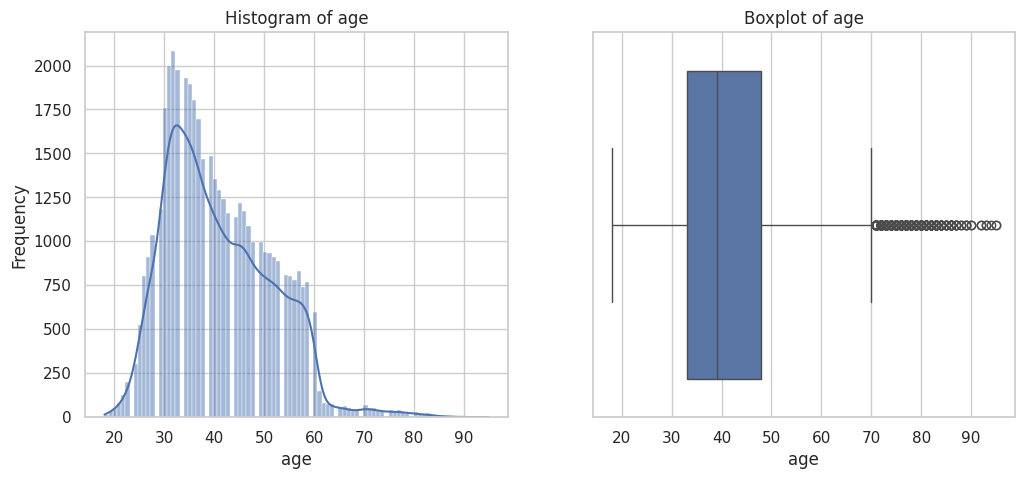

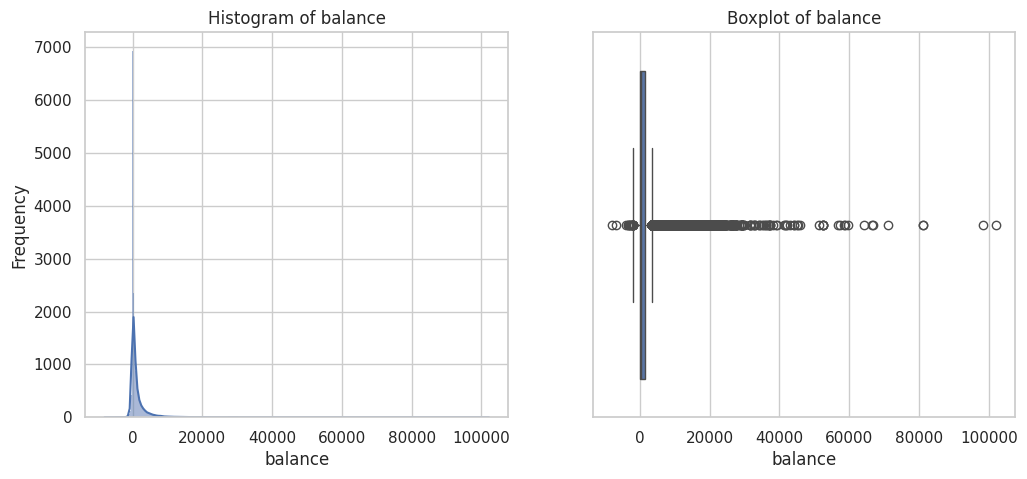

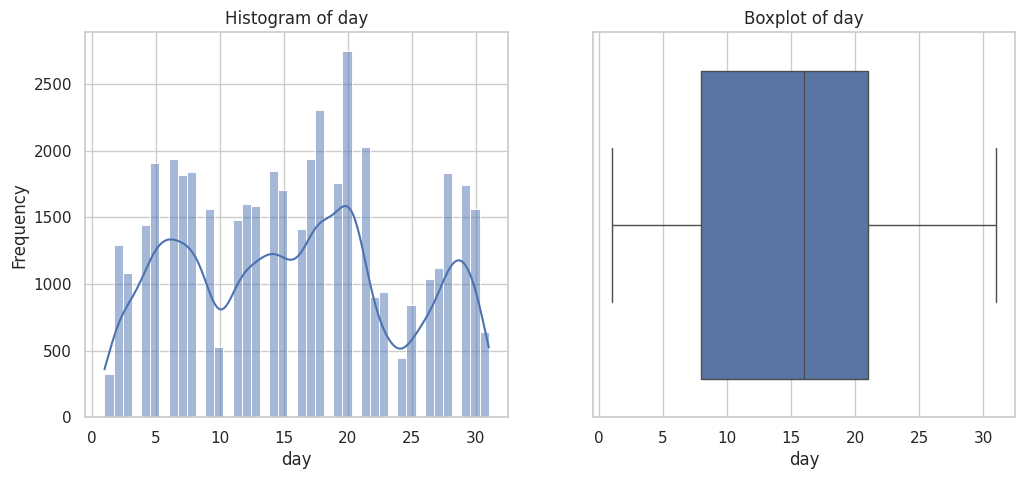

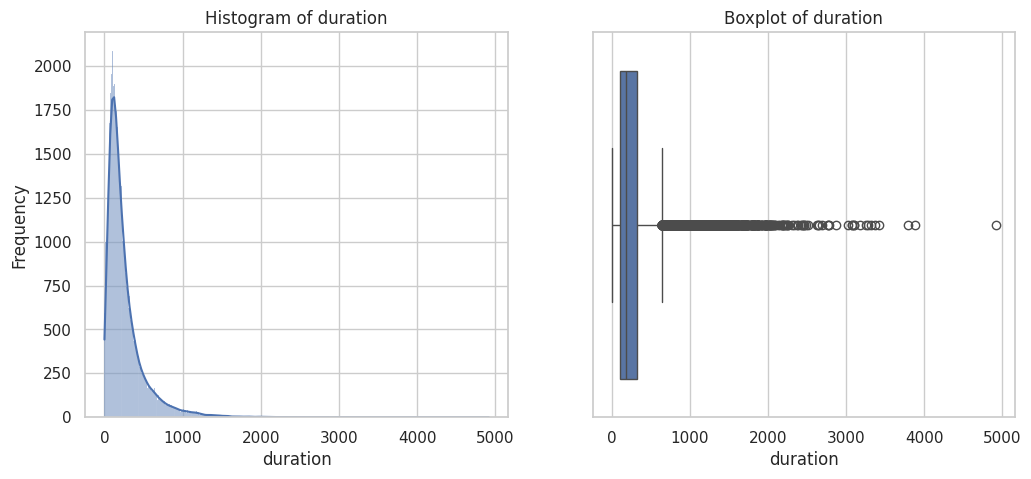

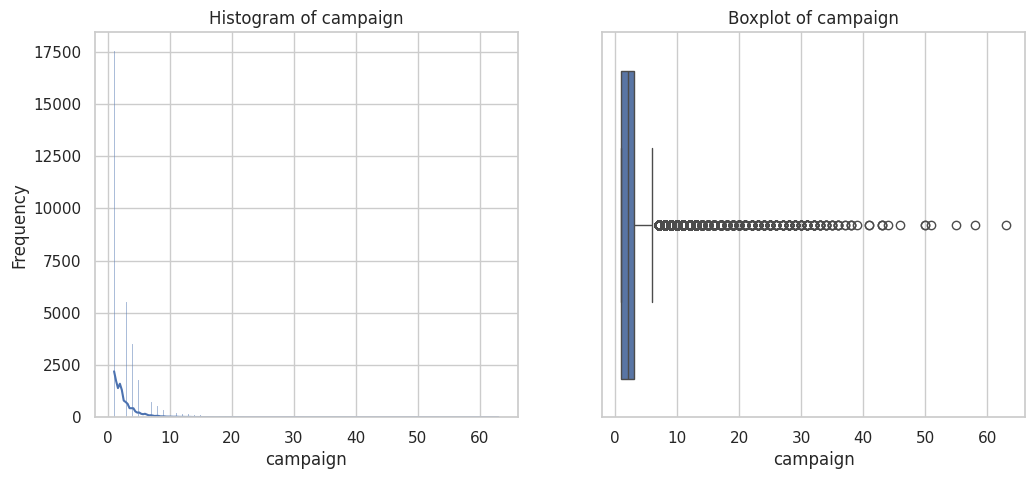

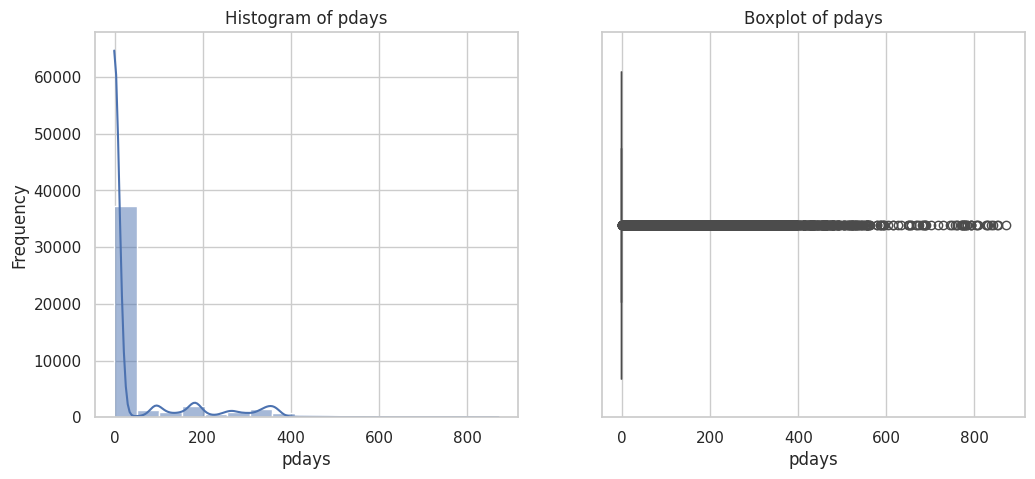

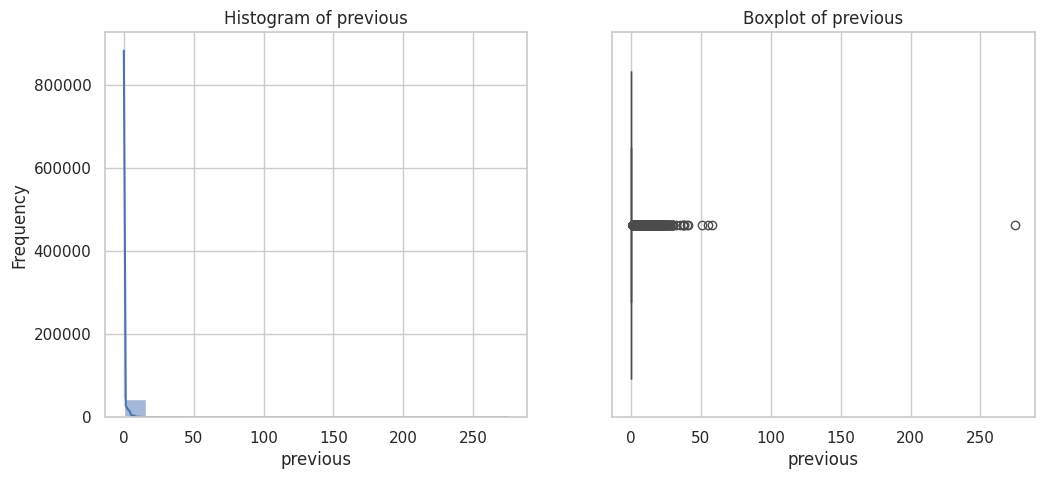

In [ ]:
for col in numeric_vars:
    plt.figure(figsize=(12, 5))
    # Histogram
    plt.subplot(1, 2, 1)
    sns.histplot(df_copy2[col], kde=True)
    plt.title(f'Histogram of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')

    # Boxplot
    plt.subplot(1, 2, 2)
    sns.boxplot(x=df_copy2[col])
    plt.title(f'Boxplot of {col}')

    plt.show()

**Analysis of Numeric Variable Distributions**

Here's an overview of the distribution shapes for each numeric variable:

*   **`age`**:
    *   **Histogram**: The distribution of `age` appears to be slightly right-skewed, with a peak around the late 30s and early 40s, and a gradual decline towards higher ages. There are also smaller peaks or bumps, suggesting a varied age demographic.
    *   **Boxplot**: The boxplot confirms the slight positive skewness, with the median close to the first quartile and a longer whisker extending to higher ages. There are also several outliers indicating individuals much older than the average.

*   **`balance`**:
    *   **Histogram**: This variable is highly right-skewed. A significant majority of clients have a low `balance` (close to zero or even negative), with a very long tail extending to very high positive balances. This suggests a few clients have exceptionally large balances.
    *   **Boxplot**: The boxplot clearly shows extreme positive skewness, with the bulk of the data compressed near the lower end and numerous extreme outliers on the higher side, representing clients with very large account balances.

*   **`day`**:
    *   **Histogram**: The `day` of the month shows a fairly uniform distribution, meaning that calls are made relatively evenly across the days of the month, though there might be slight variations. It doesn't show strong skewness.
    *   **Boxplot**: The boxplot reflects this uniformity, with the median roughly in the middle of the box and whiskers of similar length, indicating a symmetric spread with some potential outliers.

*   **`duration`**:
    *   **Histogram**: The `duration` of the last contact is highly right-skewed. Most contacts are short, with a large concentration at lower durations, and a long tail indicating a small number of very long contacts.
    *   **Boxplot**: This is characterized by a median closer to the lower quartile and a very long upper whisker with numerous extreme outliers, demonstrating a strong positive skewness.

*   **`campaign`**:
    *   **Histogram**: `campaign` is also highly right-skewed, indicating that most clients are contacted only a few times during a campaign. There's a sharp drop-off in frequency as the number of contacts increases, with a long tail for clients contacted many times.
    *   **Boxplot**: The boxplot shows the median at 2 or 3, with a heavily extended upper whisker and many outliers, confirming the strong positive skewness.

*   **`pdays`**:
    *   **Histogram**: This distribution is unique and dominated by a large spike at -1, which typically signifies that the client was not previously contacted. For positive values, the distribution is right-skewed, showing that for those with prior contact, the number of days since the last contact can vary widely, but most are relatively recent.
    *   **Boxplot**: The boxplot visually represents the concentration at -1, followed by a wide spread of positive values, and many outliers on the positive side.

*   **`previous`**:
    *   **Histogram**: Similar to `campaign`, `previous` contacts is highly right-skewed. A vast majority of clients have had no previous contacts in this campaign (value of 0), and a very long tail shows that a few clients have had many previous contacts.
    *   **Boxplot**: The boxplot shows the median at 0, with a very long upper whisker and numerous extreme outliers, highlighting the strong positive skewness.

### **Bar Charts for Categorical Variables**


Bar charts are used to visualize the distribution of categorical variables by comparing the frequency of each category. They provide an intuitive overview of class proportions, highlight dominant and rare categories, and help identify imbalances that may affect analysis and predictive modeling.

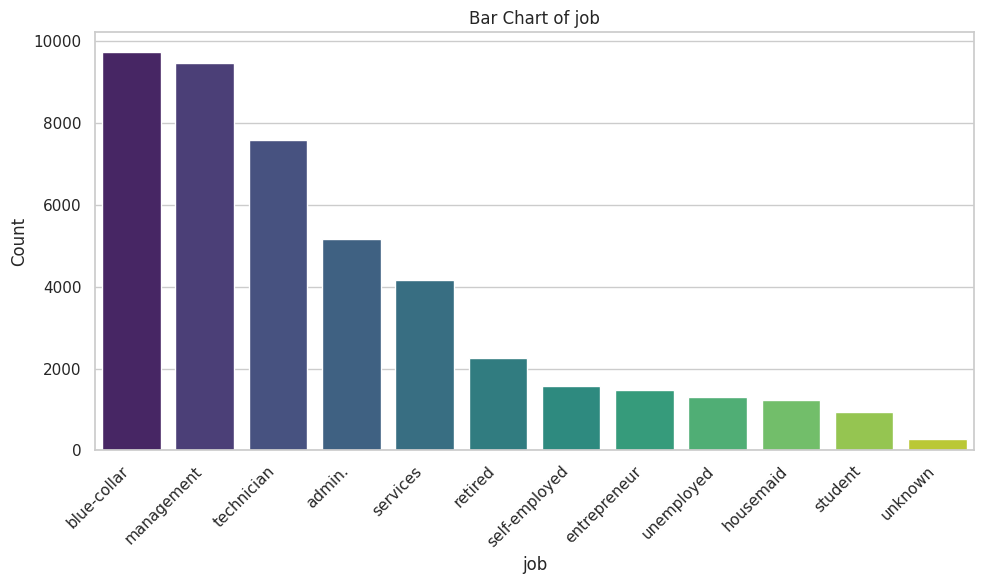

The most frequent category for 'job' is: 'blue-collar' (Count: 9730)



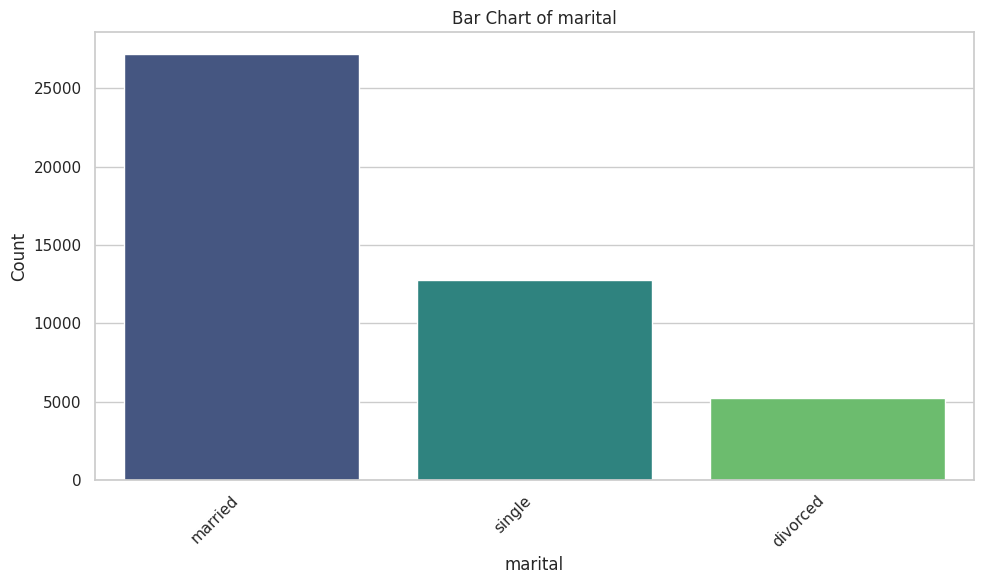

The most frequent category for 'marital' is: 'married' (Count: 27214)



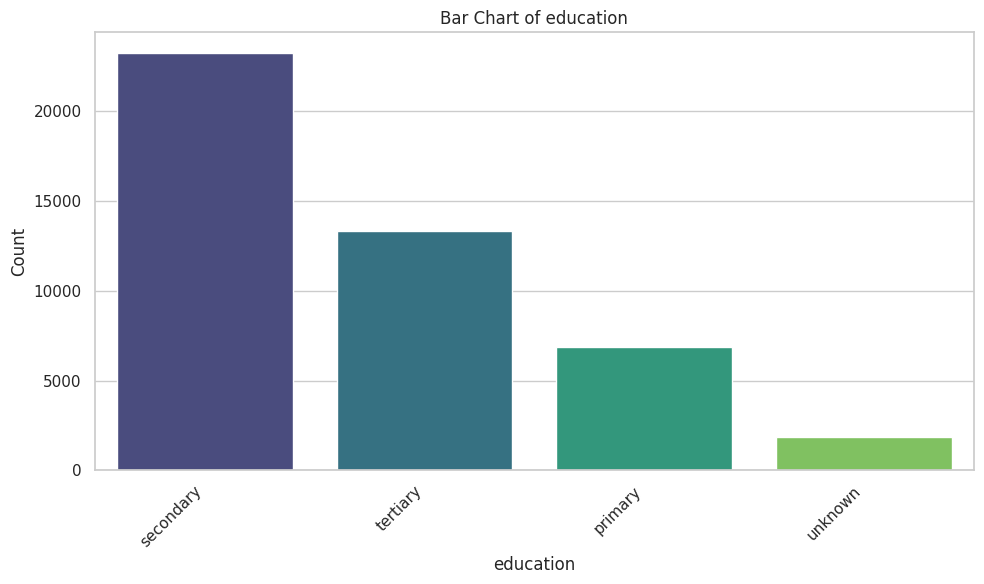

The most frequent category for 'education' is: 'secondary' (Count: 23199)



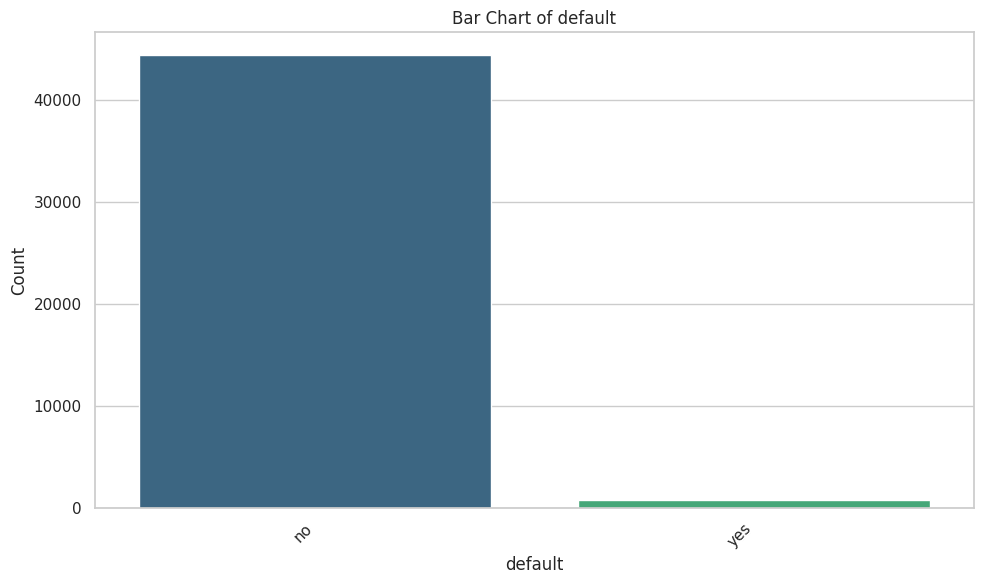

The most frequent category for 'default' is: 'no' (Count: 44395)



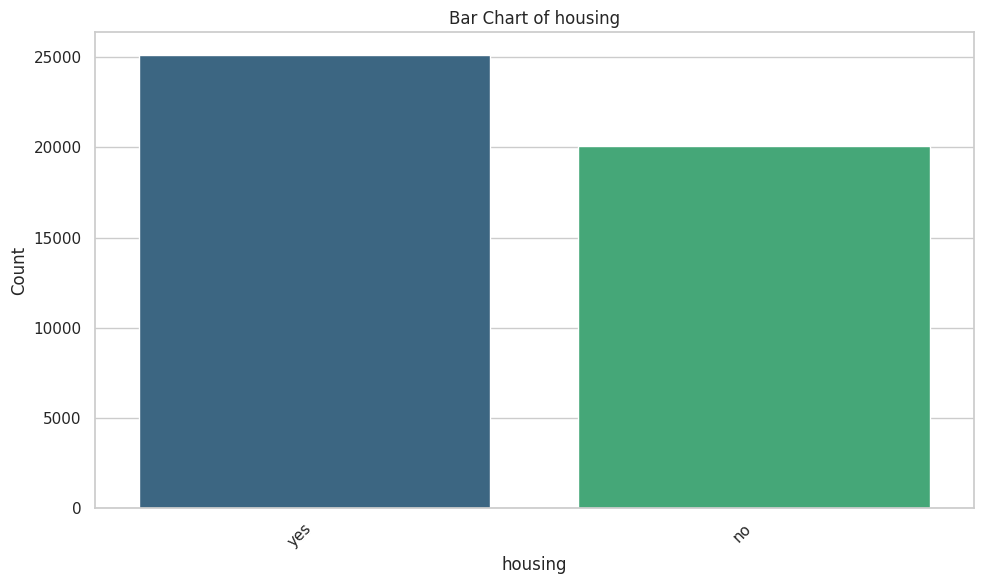

The most frequent category for 'housing' is: 'yes' (Count: 25129)



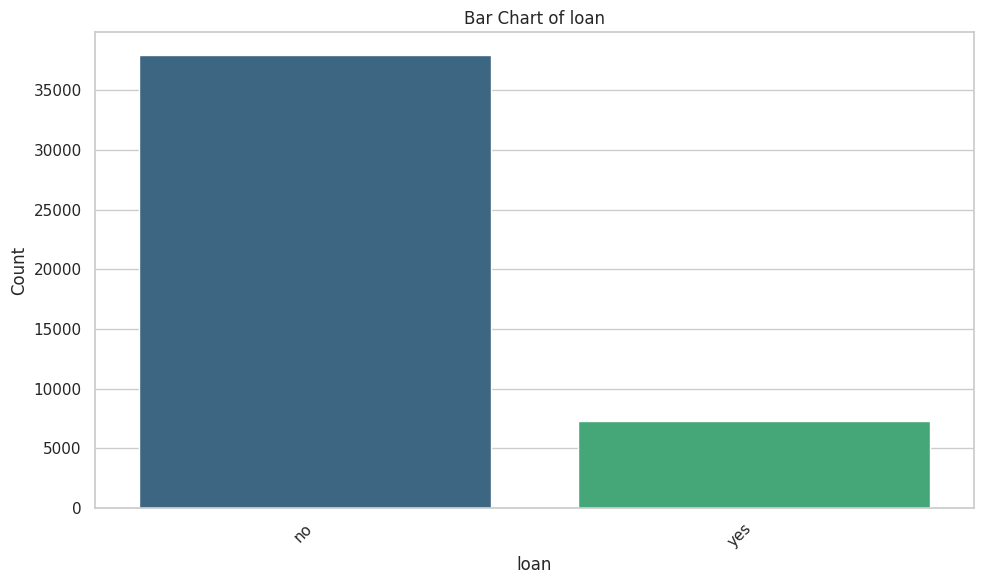

The most frequent category for 'loan' is: 'no' (Count: 37966)



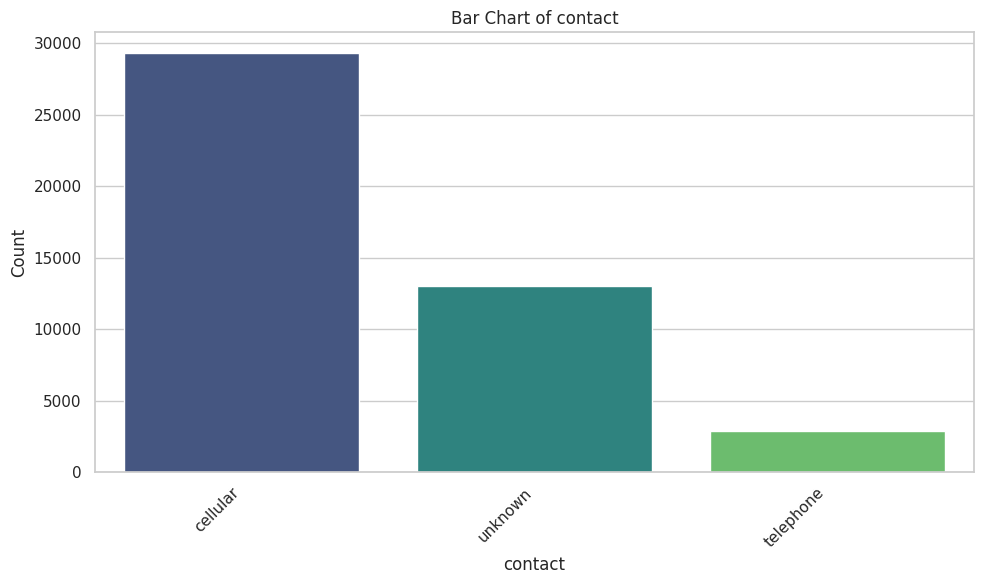

The most frequent category for 'contact' is: 'cellular' (Count: 29285)



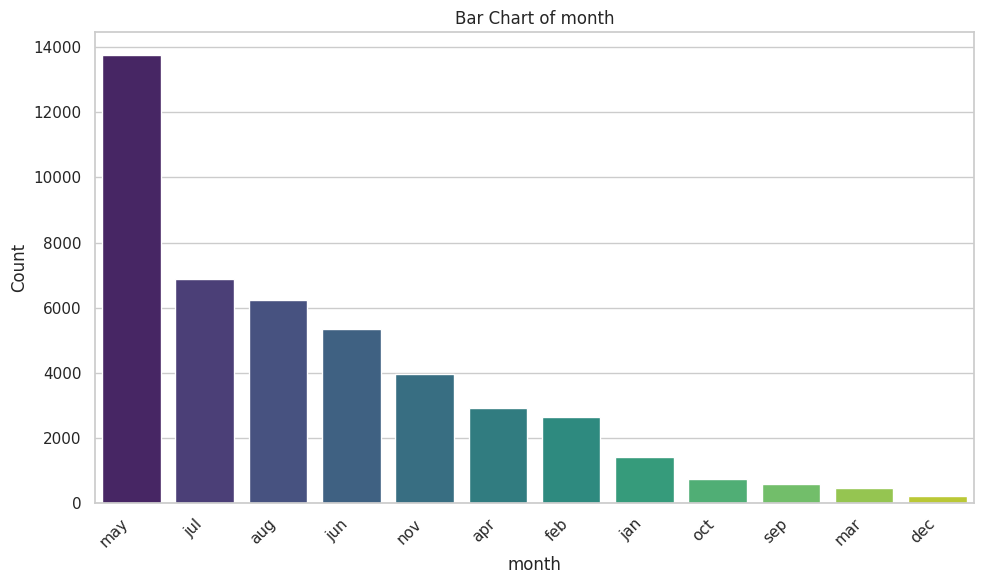

The most frequent category for 'month' is: 'may' (Count: 13765)



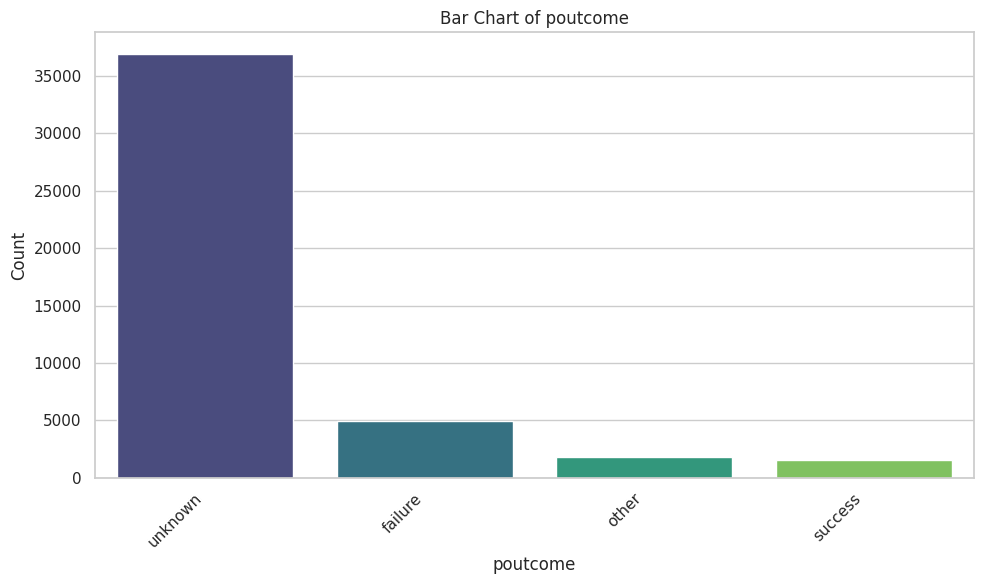

The most frequent category for 'poutcome' is: 'unknown' (Count: 36958)



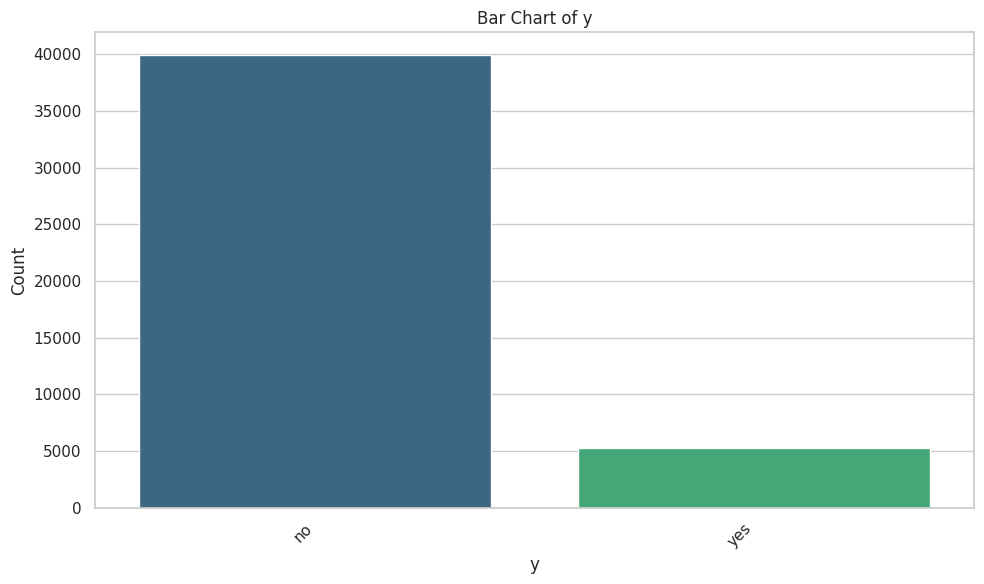

The most frequent category for 'y' is: 'no' (Count: 39921)



In [ ]:
for col in cat_vars:
    plt.figure(figsize=(10, 6))
    sns.countplot(data=df_copy, x=col, order=df_copy[col].value_counts().index, palette='viridis')
    plt.title(f'Bar Chart of {col}')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

    most_frequent = df_copy[col].value_counts().idxmax()
    print(f"The most frequent category for '{col}' is: '{most_frequent}' (Count: {df_copy[col].value_counts().max()})\n")

**Analysis distribution of categorical variables**

**`job`**: The bar chart for 'job' highlights the dominance of 'blue-collar' and 'management' roles, with significantly taller bars for these categories, and a very short bar for 'unknown'.

**`marital`**: You can easily see that 'married' is the largest group, followed by 'single', and then 'divorced', visually reinforcing the frequency table data.
education: The bar chart for 'education' shows 'secondary' as the most common level, with 'tertiary' and 'primary' having progressively shorter bars. 'Unknown' is the least frequent.

**`default`**: The 'default' bar chart vividly displays the extreme imbalance, with an overwhelmingly tall bar for 'no' and a tiny bar for 'yes'.

**`housing`**: The bars for 'yes' and 'no' are relatively close, but 'yes' is visibly taller, indicating more clients have housing loans.

**`loan`**: Similar to 'default', the 'loan' bar chart shows a much taller bar for 'no', signifying that most clients do not have personal loans.

**`contact`**: The 'contact' chart clearly shows 'cellular' as the primary contact method, with 'unknown' and 'telephone' having much smaller bars.

**`month`**: The bar for 'may' is conspicuously the tallest, emphasizing the peak in campaign activity during that month, while other months like 'dec' or 'mar' have very short bars.

**`poutcome`**: The bar chart for 'poutcome' visually confirms that 'unknown' is the predominant category, with much smaller bars for 'failure', 'other', and 'success'.

**`y`**: The bar chart for 'y' (target variable) visually demonstrates the class imbalance, with a significantly taller bar for 'no' compared to 'yes'.
These bar charts provide a quick and intuitive understanding of the distribution and prevalence of each category within your categorical variables.

## **BIVARIATE AND MULTIVARIATE DESCRIPTION**
Bivariate and Multivariate Analysis explores relationships between two or more variables to understand dependencies, interactions, and joint patterns within the data. This analysis reveals how features influence each other and the target variable, helping identify meaningful associations, potential predictors, and complex structures that support deeper insights and model development.

### **Compute correlations among numeric variables and visualize them with a correlation heatmap**

Correlation analysis is used to measure the strength and direction of relationships between numeric variables. A correlation heatmap provides a visual summary of these relationships, making it easy to identify strong associations, multicollinearity, and potential feature dependencies that may impact modeling and interpretation.

In [ ]:
numeric_df = df_copy.select_dtypes(include=['number'])
correlation_matrix = numeric_df.corr()

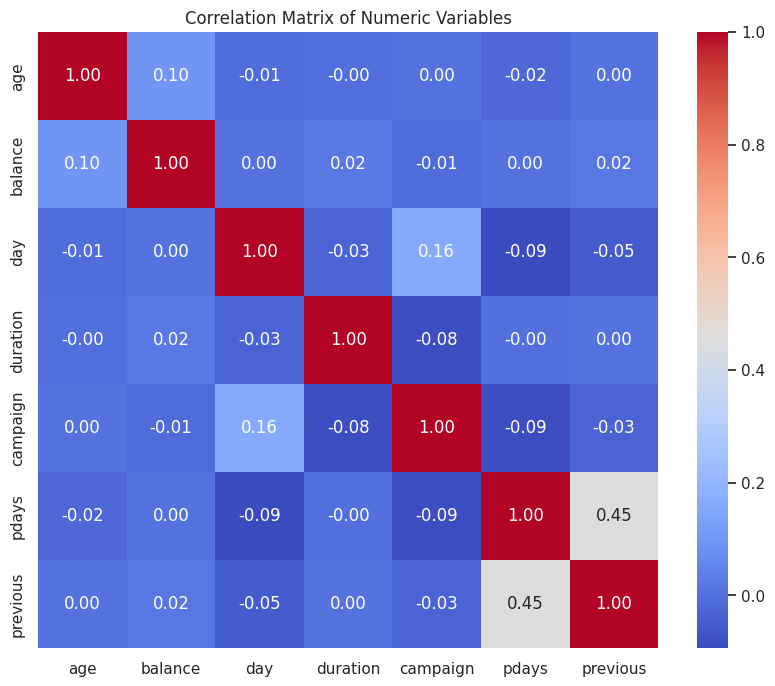

In [ ]:
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Numeric Variables')
plt.show()

**Correlations among numeric variables - Key Insights**
* **correlation between pdays (days since last contact) and previous (number of previous contacts)**. This is intuitive, as clients who have been contacted more often in the past are more likely to have a recorded number of days since their last contact.

* **day and campaign (0.16)**: A weak positive correlation exists between the day of the month and the campaign number. This suggests that as the campaign progresses (higher campaign number), there might be a slight tendency for contacts to occur later in the month.

* **Other Correlations**: Most other numeric variables show very weak correlations (close to zero), indicating that they are largely independent of each other. For example, age has very weak correlations with all other variables, as do balance and duration with most others. This suggests that there isn't a strong linear relationship between these pairs of variables in this dataset.

* In summary, the numeric variables generally exhibit weak linear correlations, with pdays and previous having the most notable relationship. The heatmap visually reinforces these findings, with most cells showing colors close to zero correlation.

### **Create scatterplots for pairs of numeric variables. Do you observe linear or nonlinear relationships?**

Scatterplots are used to visualize relationships between pairs of numeric variables, helping to identify linear trends, nonlinear patterns, clusters, and outliers. These plots reveal the nature and strength of associations, supporting decisions on feature selection, transformations, and appropriate modeling approaches.


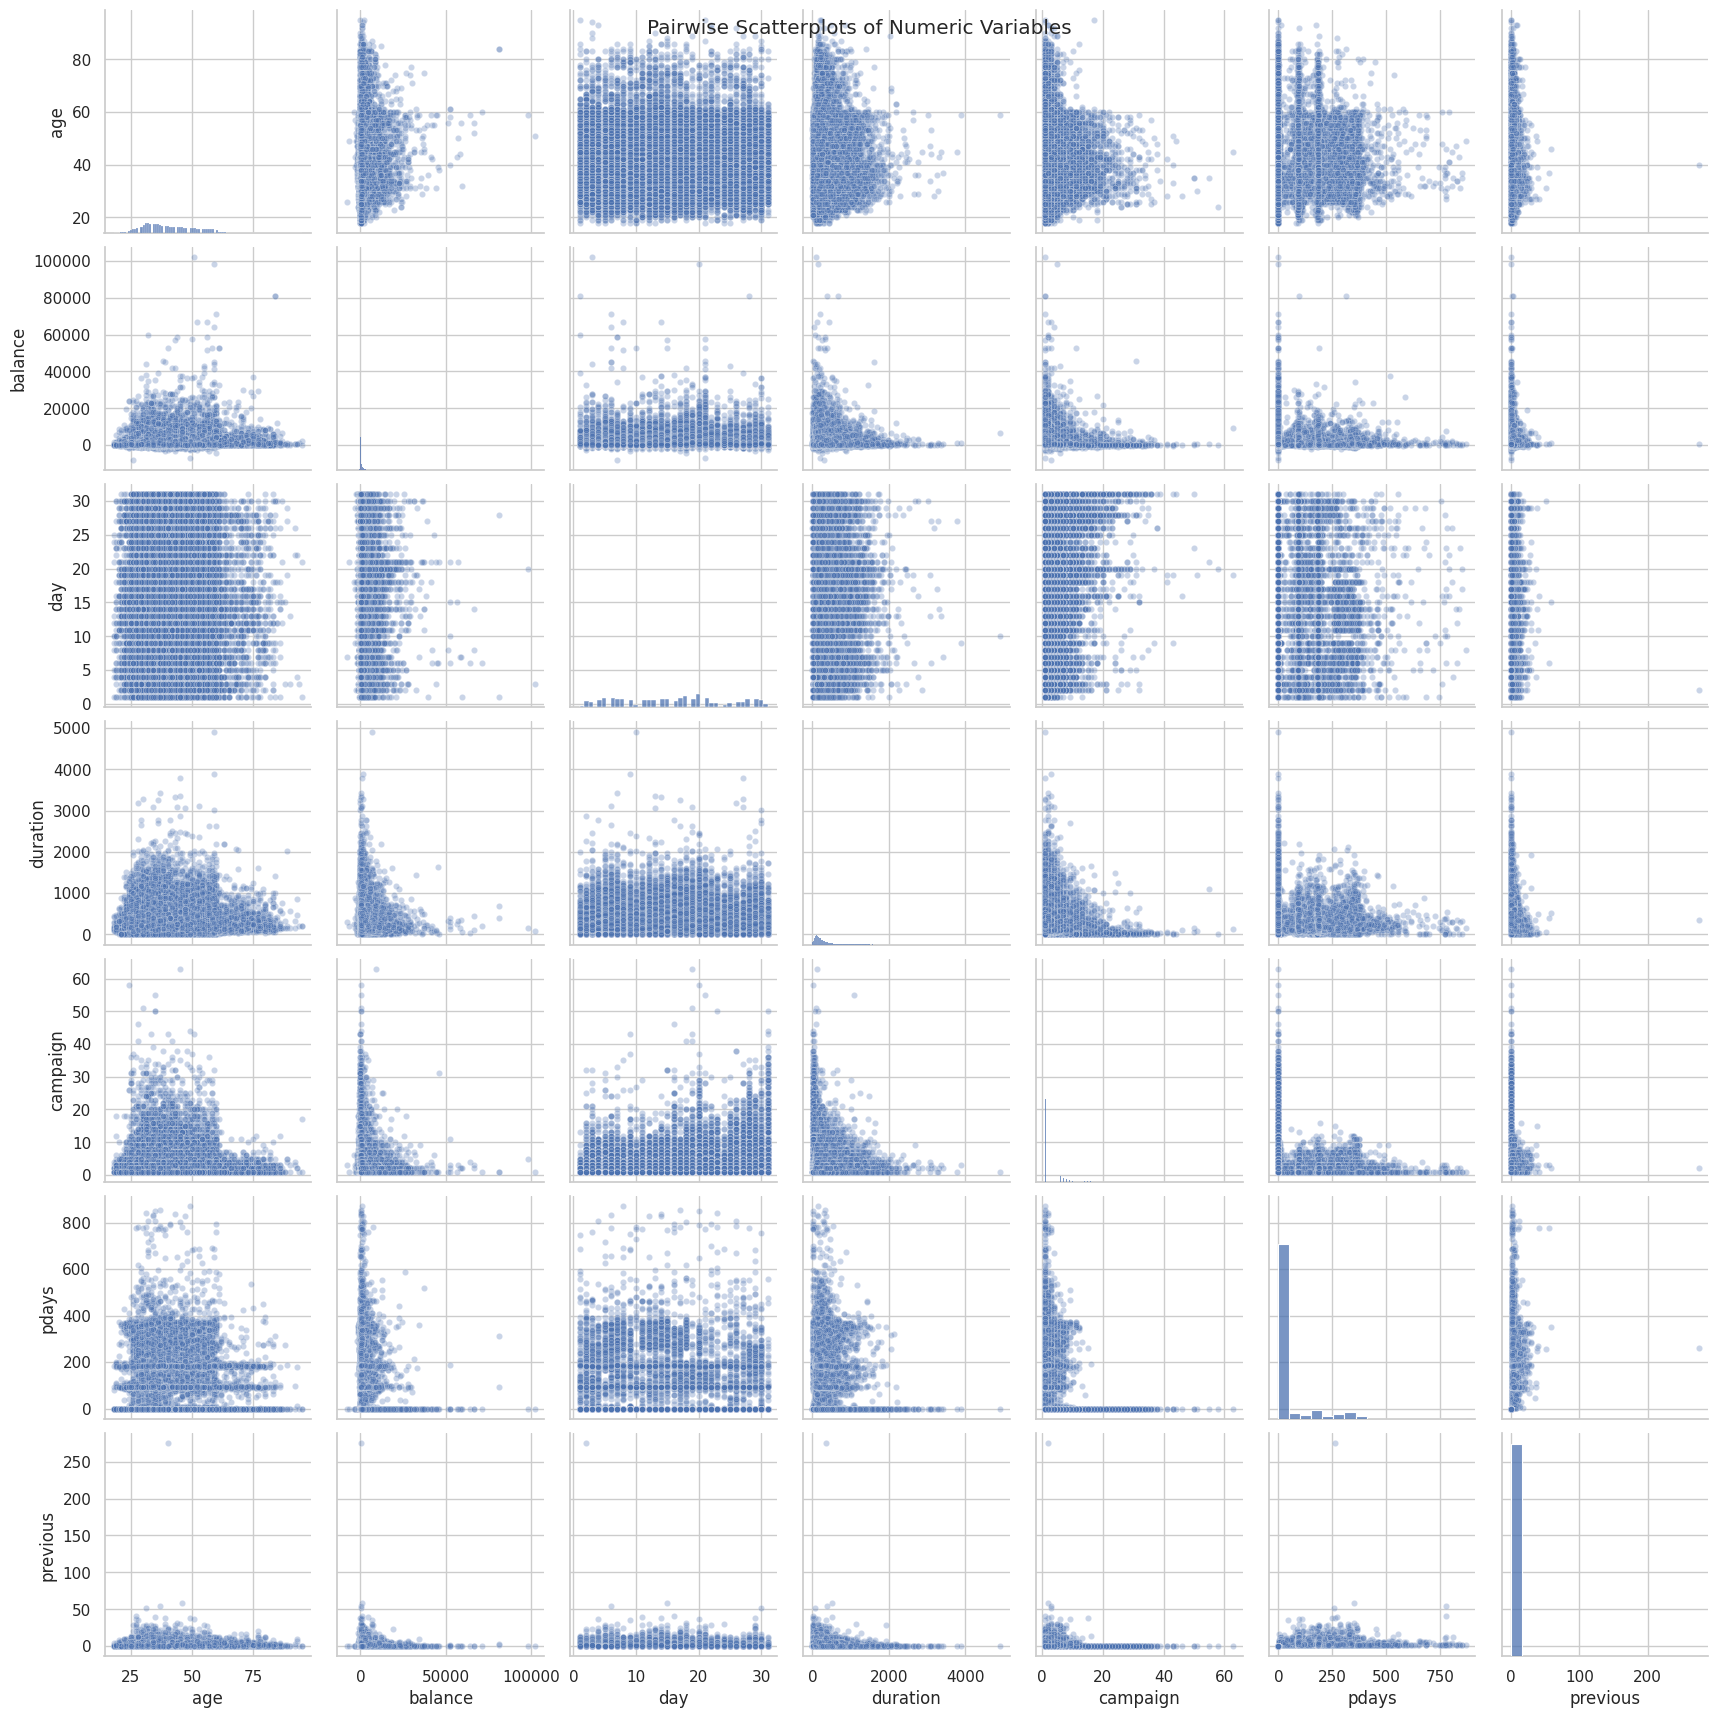

In [ ]:
# Pairwise scatterplot matrix
sns.pairplot(numeric_df, diag_kind='hist', plot_kws={'alpha':0.3, 's':20})
plt.suptitle("Pairwise Scatterplots of Numeric Variables")
plt.show()

**Insights from Pairwise Scatterplots of Numeric Variables:**

* **Age vs. Other Variables**

  * Most clients are concentrated between ages 25–60.

  * No clear linear relationship between age and variables like balance, duration, or campaign.

* **Balance**

  * Highly skewed distribution: most clients have low balances, with a few extreme high values (outliers).

  * No strong linear correlation with age, day, or previous contacts.

* **Day**

  * Values are discrete (1–31), with no visible linear relationships with other variables.

  * Distribution is fairly uniform across days.

* **Duration**

  * Strongly right-skewed, with most calls being short and few lasting very long.

  * Slight positive trend with campaign and previous contacts in some cases.

* **Campaign**

  * Most clients are contacted fewer than 10 times; long campaigns are rare.

  * No clear linear relationship with age or day, but a weak trend with duration.

* **Pdays & Previous**

  * Many clients were not contacted before (Pdays = -1 / previous = 0).

  * Both variables are heavily skewed, with a few clients contacted very often.

* **Overall Patterns**

  * Most relationships appear nonlinear or weak.

  * Presence of outliers is noticeable in balance, duration, pdays, and previous contacts.

  * Distributions are often right-skewed, suggesting possible transformations (e.g., log) for modeling.

###  **Compare the distributions of a numeric variable across categories.**

Comparing the distributions of a numeric variable across categories helps reveal how different groups behave with respect to that variable. Visualizations like boxplots or violin plots highlight differences in central tendency, spread, and outliers, making it easier to identify patterns, group-specific trends, and potential relationships with the target variable.

In [ ]:
numeric_cols = df_copy.select_dtypes(include='number').columns


=== Numeric Variable: age | Categorical Variable: job ===

                count       mean        std   min   25%   50%   75%   max
job                                                                      
admin.         5172.0  39.289637   9.364595  20.0  32.0  38.0  46.0  75.0
blue-collar    9732.0  40.044081   9.025888  20.0  33.0  39.0  47.0  75.0
entrepreneur   1487.0  42.190989   9.114486  21.0  35.0  41.0  49.0  84.0
housemaid      1240.0  46.415323  10.477275  22.0  38.0  47.0  55.0  83.0
management     9460.0  40.451480   9.383979  21.0  33.0  38.0  48.0  81.0
retired        2264.0  61.626767   9.535329  24.0  56.0  59.0  67.0  95.0
self-employed  1579.0  40.484484   9.656075  22.0  33.0  39.0  48.0  76.0
services       4154.0  38.740250   9.041371  20.0  32.0  37.0  46.0  69.0
student         938.0  26.542644   4.842536  18.0  23.0  26.0  29.0  48.0
technician     7597.0  39.314598   8.939944  21.0  32.0  37.0  46.0  71.0
unemployed     1303.0  40.961627   9.777010  21.0  3

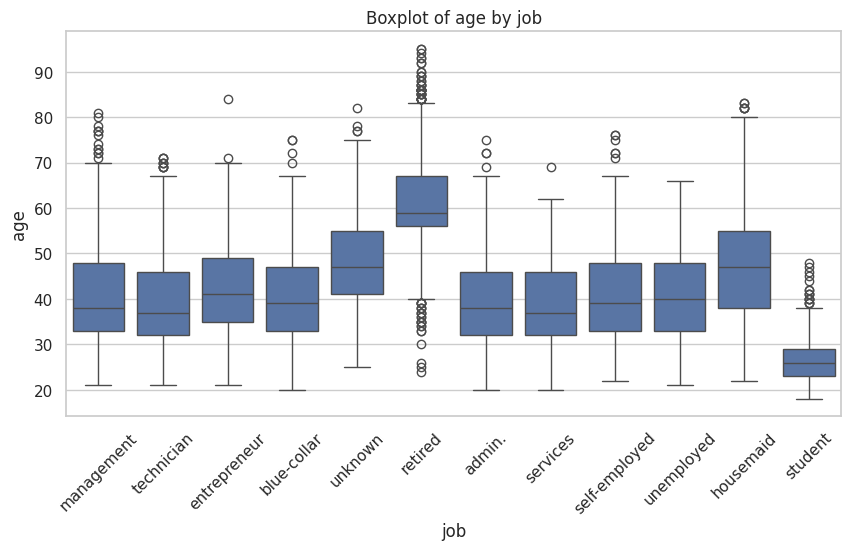

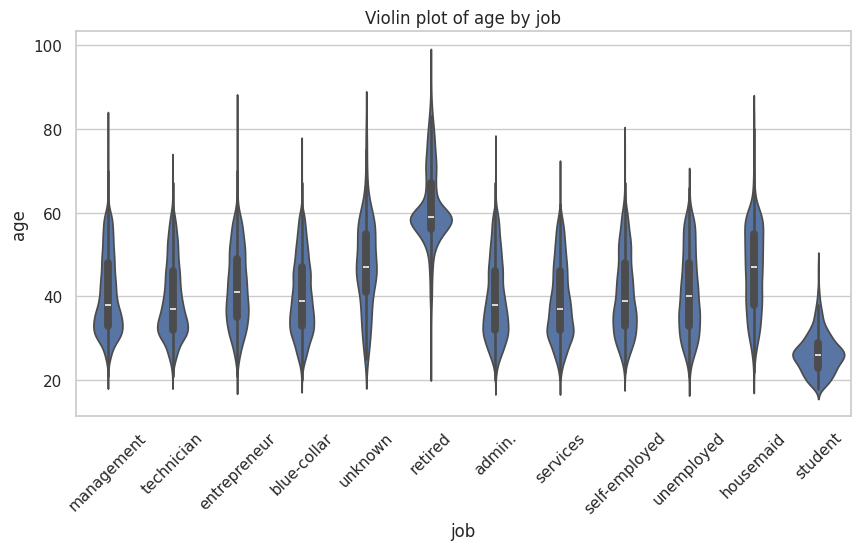


=== Numeric Variable: balance | Categorical Variable: job ===

                count         mean          std     min     25%    50%  \
job                                                                      
admin.         5172.0  1135.628190  2641.750680 -1601.0   63.00  395.5   
blue-collar    9732.0  1078.826654  2240.523208 -8019.0   55.00  388.0   
entrepreneur   1487.0  1521.470074  4153.442626 -2082.0   44.50  352.0   
housemaid      1240.0  1392.395161  2984.692098 -1941.0   57.75  406.0   
management     9460.0  1763.549049  3822.577778 -6847.0   98.00  572.0   
retired        2264.0  1984.215106  4397.044177 -1598.0  164.50  787.0   
self-employed  1579.0  1647.970868  3684.259573 -3313.0  120.00  526.0   
services       4154.0   997.088108  2164.493505 -2122.0   35.00  339.5   
student         938.0  1388.060768  2441.703526  -679.0  148.25  502.0   
technician     7597.0  1252.632092  2548.544019 -2827.0   61.00  421.0   
unemployed     1303.0  1521.745971  3144.666754 

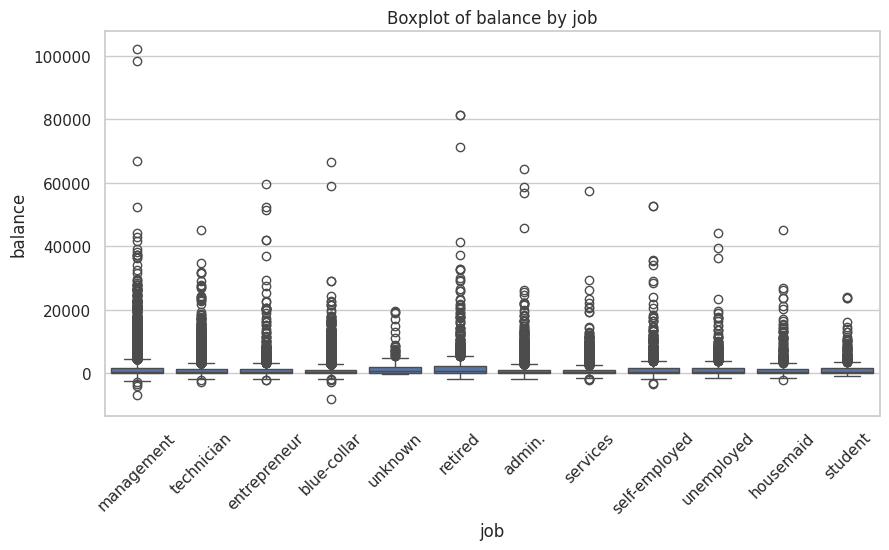

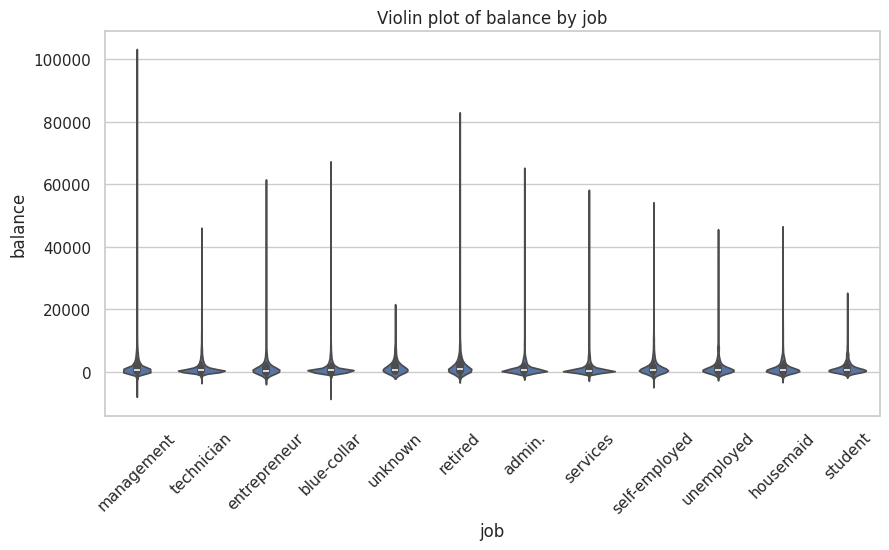


=== Numeric Variable: day | Categorical Variable: job ===

                count       mean       std  min  25%   50%    75%   max
job                                                                    
admin.         5172.0  15.562452  8.464640  1.0  8.0  15.0  21.00  31.0
blue-collar    9732.0  15.442561  7.886832  1.0  9.0  15.0  20.00  31.0
entrepreneur   1487.0  15.702085  7.883788  1.0  9.0  17.0  21.00  31.0
housemaid      1240.0  16.002419  8.091037  1.0  9.0  16.0  22.00  31.0
management     9460.0  16.112051  8.382350  1.0  8.0  17.0  22.00  31.0
retired        2264.0  15.439488  8.320994  1.0  8.0  15.0  22.00  31.0
self-employed  1579.0  16.027866  8.214904  1.0  9.0  17.0  21.00  31.0
services       4154.0  15.635532  8.295096  1.0  8.0  16.0  21.00  31.0
student         938.0  14.897655  8.801146  1.0  7.0  14.0  22.00  31.0
technician     7597.0  16.408582  8.527777  1.0  8.0  17.0  23.00  31.0
unemployed     1303.0  15.498081  9.415146  1.0  6.0  15.0  23.00  31.0
unkn

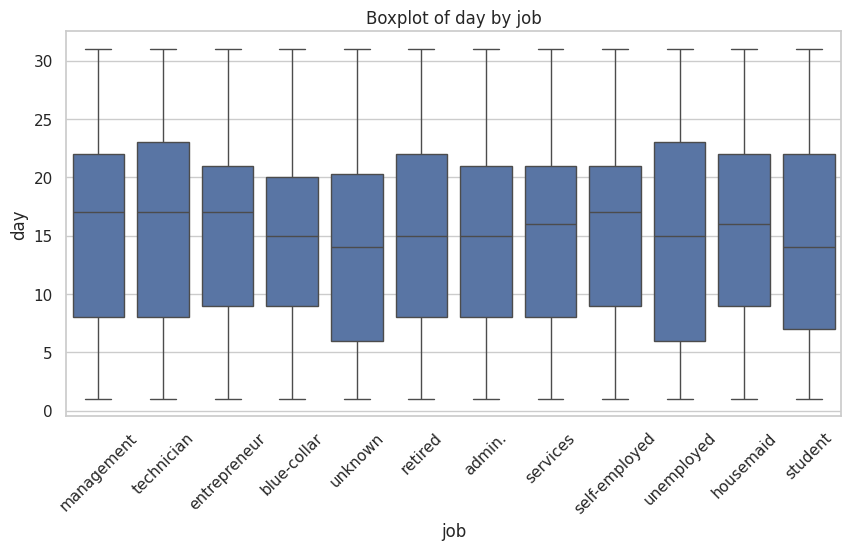

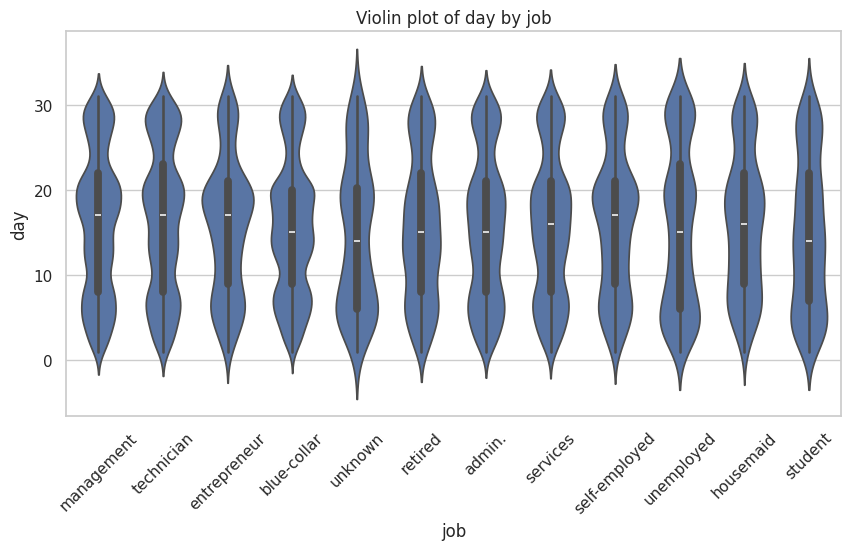


=== Numeric Variable: duration | Categorical Variable: job ===

                count        mean         std  min     25%    50%     75%  \
job                                                                         
admin.         5171.0  246.907948  239.780855  1.0  101.00  174.0  308.00   
blue-collar    9730.0  262.908736  260.784851  2.0  107.00  186.0  323.00   
entrepreneur   1486.0  255.979812  247.489419  0.0  102.00  178.0  328.00   
housemaid      1240.0  245.825000  259.380688  6.0   97.00  163.0  293.25   
management     9460.0  253.985201  256.818644  0.0   99.00  173.0  311.00   
retired        2264.0  287.361307  263.806848  5.0  120.00  204.0  365.00   
self-employed  1579.0  268.157061  281.908745  6.0  104.00  179.0  328.50   
services       4154.0  259.318729  259.787395  4.0  107.00  186.0  315.00   
student         938.0  246.656716  228.409973  4.0  107.00  180.0  310.75   
technician     7597.0  252.904962  256.498164  0.0  100.00  176.0  312.00   
unemployed 

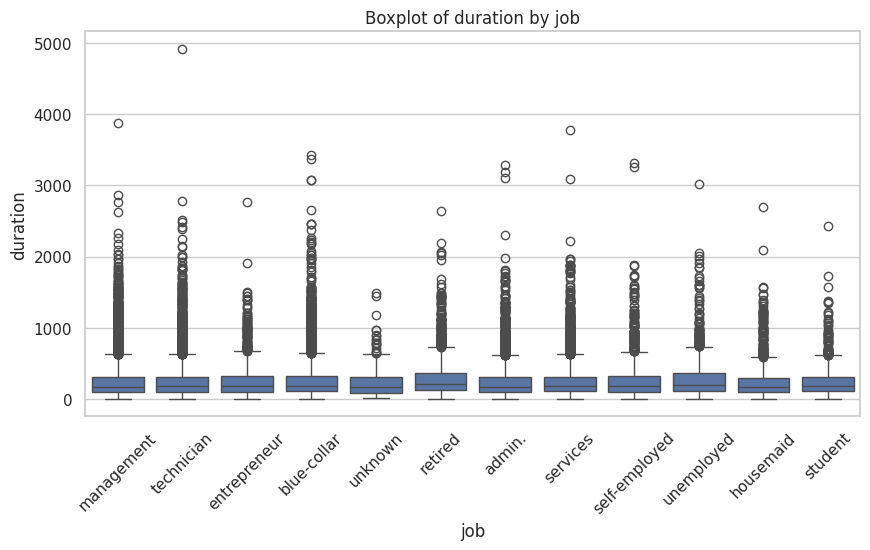

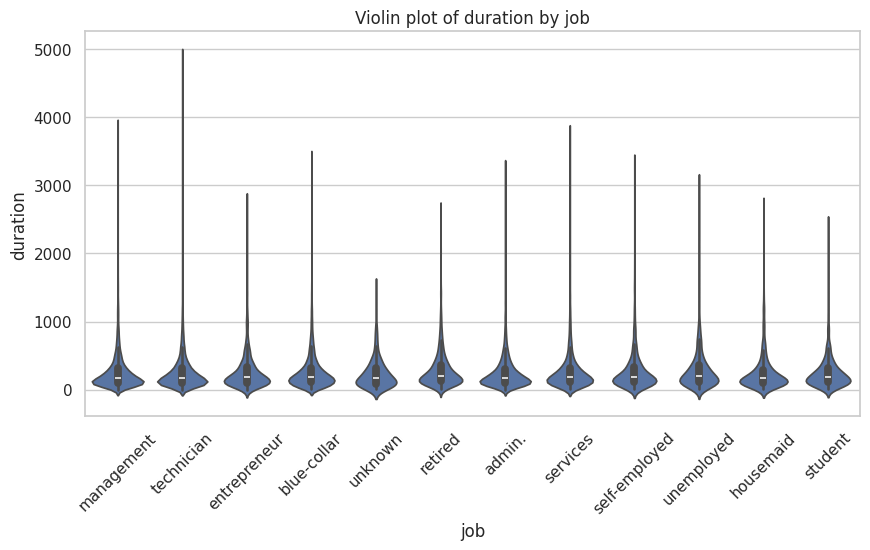


=== Numeric Variable: campaign | Categorical Variable: job ===

                count      mean       std  min  25%  50%  75%   max
job                                                                
admin.         5172.0  2.575019  2.950107  1.0  1.0  2.0  3.0  36.0
blue-collar    9732.0  2.816995  3.242741  1.0  1.0  2.0  3.0  50.0
entrepreneur   1487.0  2.799597  2.855926  1.0  1.0  2.0  3.0  32.0
housemaid      1240.0  2.820968  2.800071  1.0  1.0  2.0  3.0  38.0
management     9460.0  2.864165  3.203109  1.0  1.0  2.0  3.0  63.0
retired        2264.0  2.346731  2.269981  1.0  1.0  2.0  3.0  36.0
self-employed  1579.0  2.853072  3.186624  1.0  1.0  2.0  3.0  36.0
services       4154.0  2.718344  3.044436  1.0  1.0  2.0  3.0  34.0
student         938.0  2.299574  2.341865  1.0  1.0  2.0  3.0  26.0
technician     7597.0  2.906805  3.284196  1.0  1.0  2.0  3.0  58.0
unemployed     1303.0  2.432080  2.633201  1.0  1.0  2.0  3.0  35.0
unknown         288.0  3.309028  3.788621  1.0  1.0

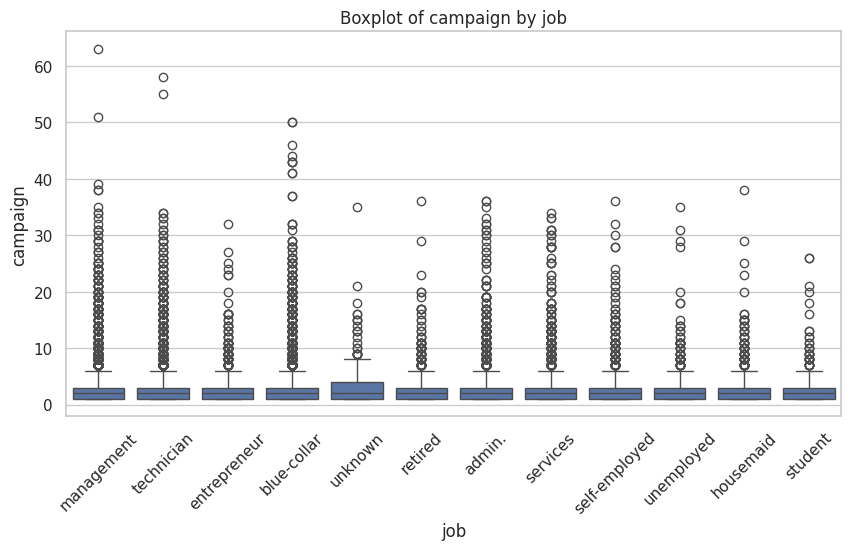

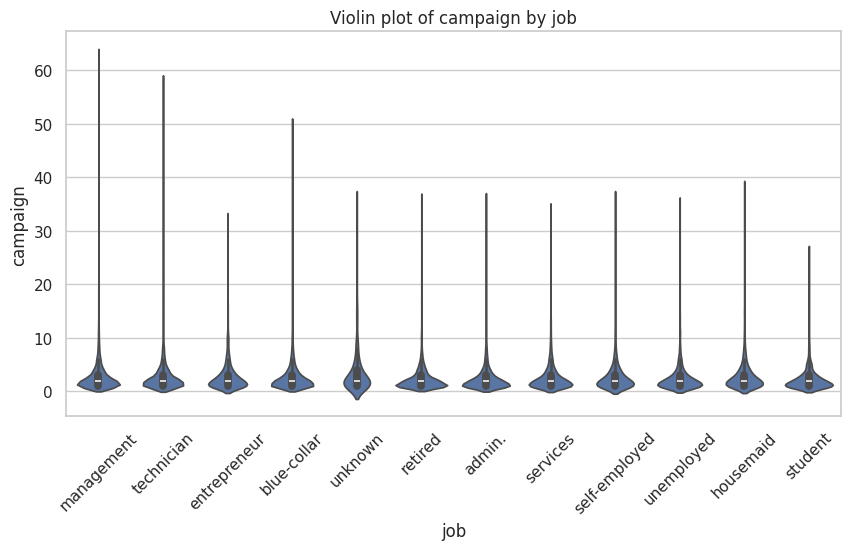


=== Numeric Variable: pdays | Categorical Variable: job ===

                count       mean         std  min  25%  50%   75%    max
job                                                                     
admin.         5172.0  47.849575  108.702959 -1.0 -1.0 -1.0  -1.0  826.0
blue-collar    9732.0  44.033498  109.726424 -1.0 -1.0 -1.0  -1.0  838.0
entrepreneur   1487.0  32.486214   88.046350 -1.0 -1.0 -1.0  -1.0  557.0
housemaid      1240.0  21.505645   71.077241 -1.0 -1.0 -1.0  -1.0  842.0
management     9460.0  38.657082   97.077905 -1.0 -1.0 -1.0  -1.0  854.0
retired        2264.0  37.443905   87.009624 -1.0 -1.0 -1.0  -1.0  792.0
self-employed  1579.0  34.747308   87.798783 -1.0 -1.0 -1.0  -1.0  585.0
services       4154.0  41.995185  103.797862 -1.0 -1.0 -1.0  -1.0  761.0
student         938.0  57.041578  106.818847 -1.0 -1.0 -1.0  92.0  535.0
technician     7597.0  37.195077   94.993072 -1.0 -1.0 -1.0  -1.0  831.0
unemployed     1303.0  34.146585   94.431841 -1.0 -1.0 -1.0  -

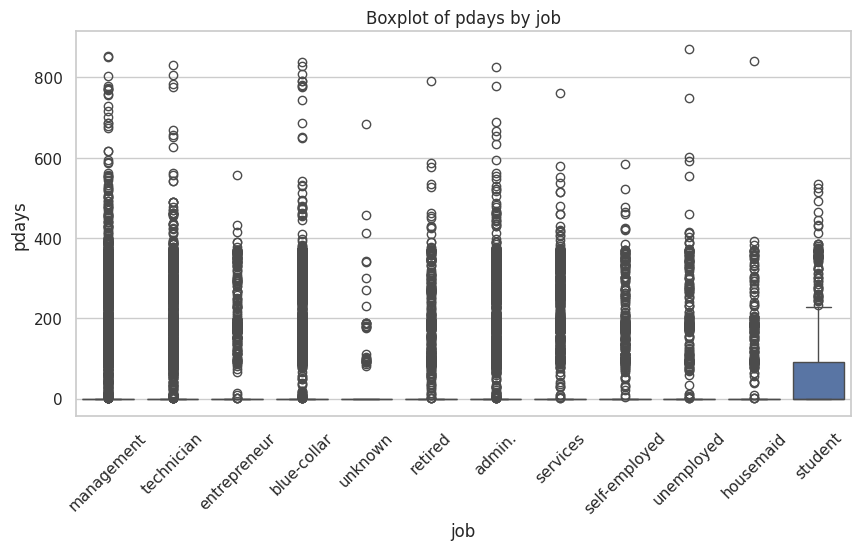

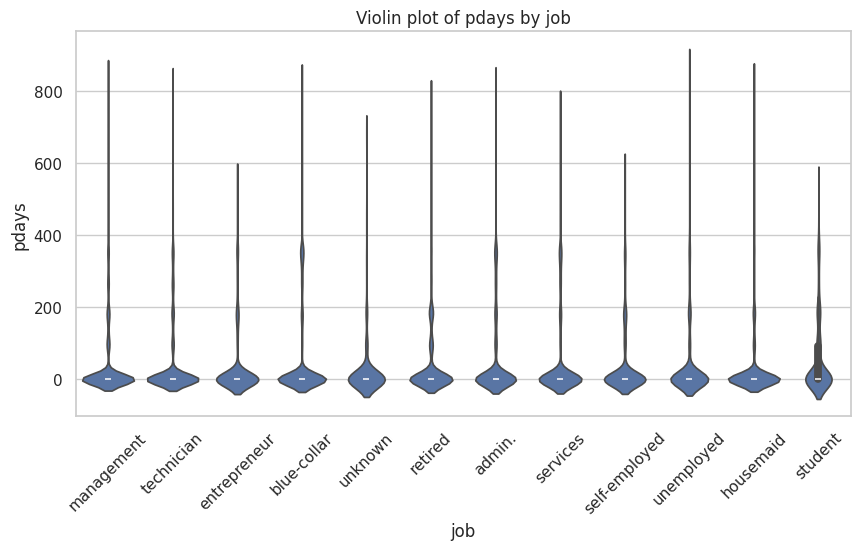


=== Numeric Variable: previous | Categorical Variable: job ===

                count      mean       std  min  25%  50%  75%    max
job                                                                 
admin.         5172.0  0.671500  2.014782  0.0  0.0  0.0  0.0   32.0
blue-collar    9732.0  0.505138  1.853396  0.0  0.0  0.0  0.0   58.0
entrepreneur   1487.0  0.478144  1.807164  0.0  0.0  0.0  0.0   37.0
housemaid      1240.0  0.371774  1.382355  0.0  0.0  0.0  0.0   18.0
management     9460.0  0.667865  3.522246  0.0  0.0  0.0  0.0  275.0
retired        2264.0  0.638693  1.727894  0.0  0.0  0.0  0.0   20.0
self-employed  1579.0  0.551615  1.713390  0.0  0.0  0.0  0.0   24.0
services       4154.0  0.501204  1.620101  0.0  0.0  0.0  0.0   30.0
student         938.0  0.953092  2.386805  0.0  0.0  0.0  1.0   37.0
technician     7597.0  0.574569  1.967449  0.0  0.0  0.0  0.0   55.0
unemployed     1303.0  0.466616  1.537123  0.0  0.0  0.0  0.0   17.0
unknown         288.0  0.319444  1.089

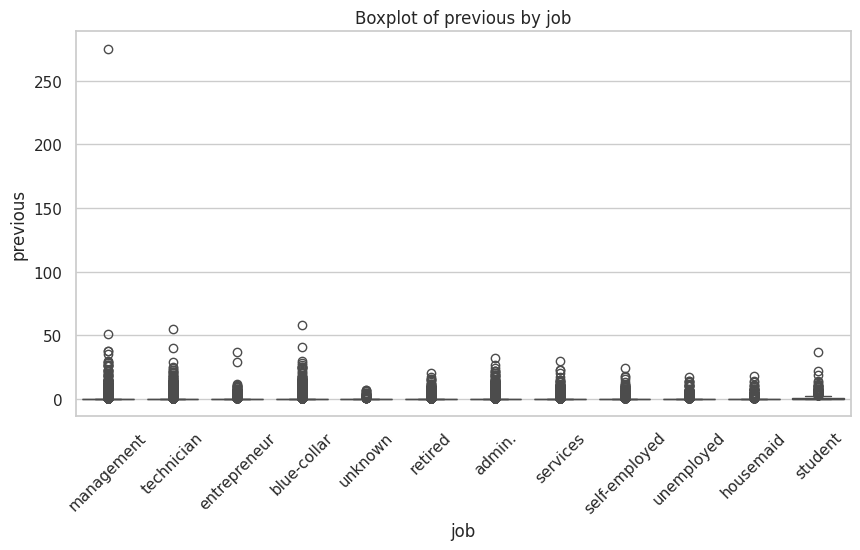

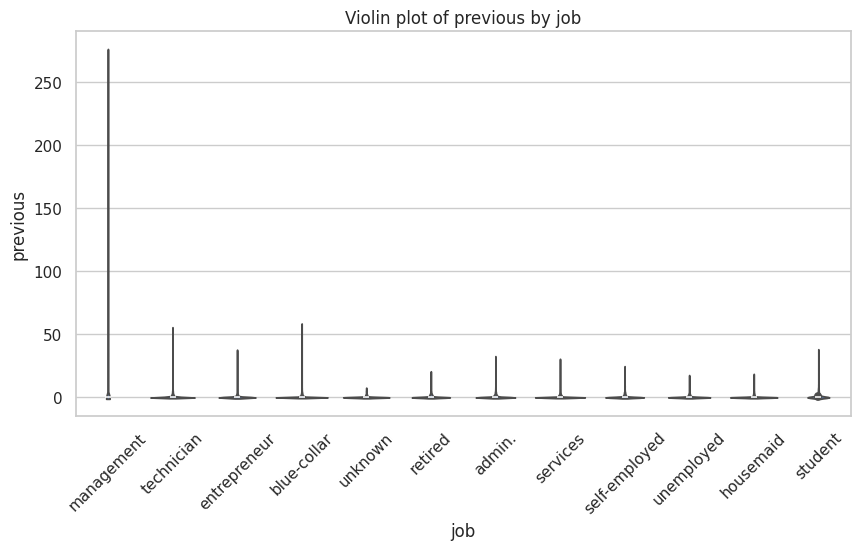


=== Numeric Variable: age | Categorical Variable: marital ===

            count       mean        std   min   25%   50%   75%   max
marital                                                              
divorced   5207.0  45.782984  10.124719  24.0  38.0  45.0  53.0  95.0
married   27217.0  43.408348  10.264273  20.0  35.0  42.0  51.0  95.0
single    12790.0  33.703440   7.603166  18.0  29.0  32.0  37.0  86.0


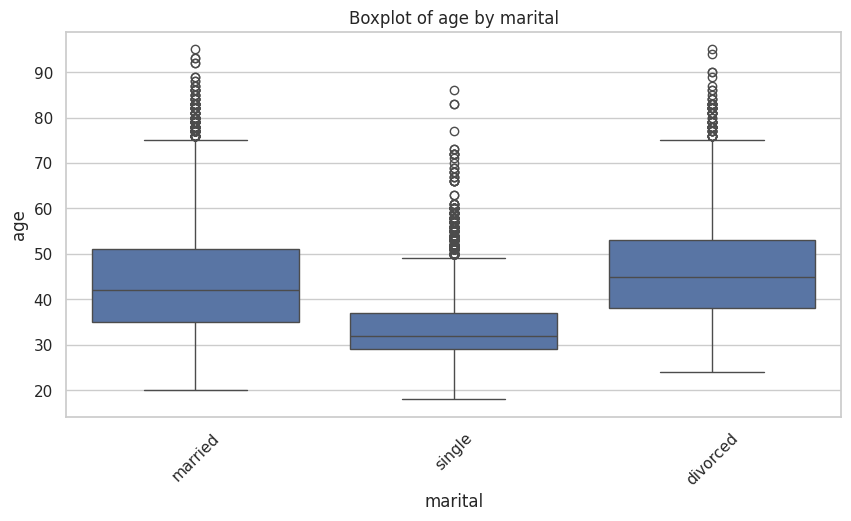

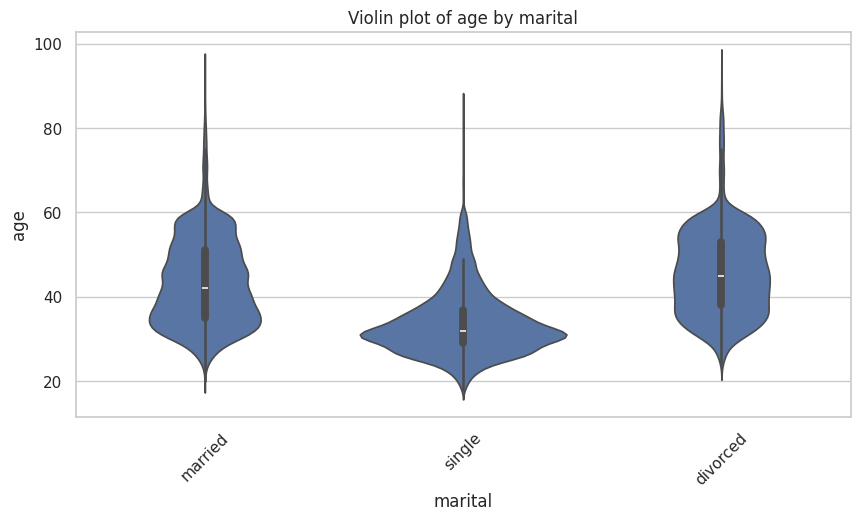


=== Numeric Variable: balance | Categorical Variable: marital ===

            count         mean          std     min   25%    50%      75%  \
marital                                                                     
divorced   5207.0  1178.872287  2926.453439 -4057.0  25.0  348.0  1205.50   
married   27217.0  1425.876144  3140.806336 -6847.0  75.0  477.0  1515.00   
single    12790.0  1301.497654  2875.317791 -8019.0  90.0  437.0  1335.75   

               max  
marital             
divorced   66721.0  
married    98417.0  
single    102127.0  


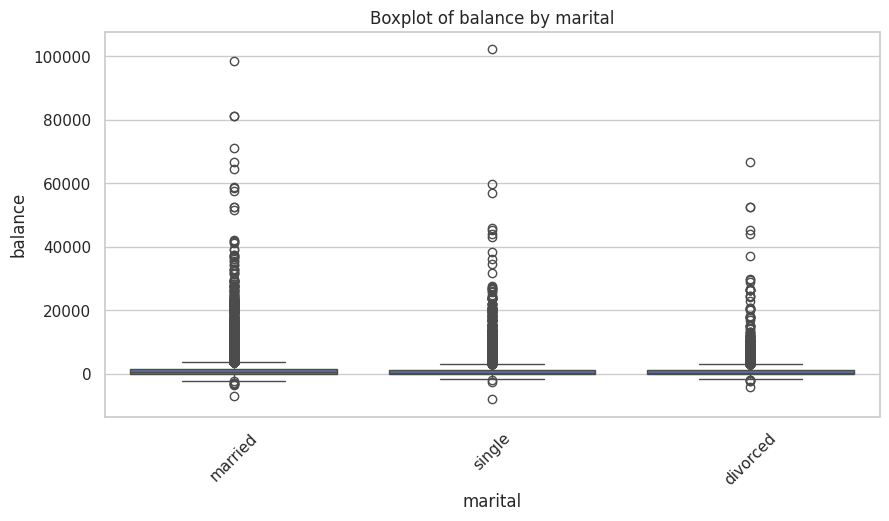

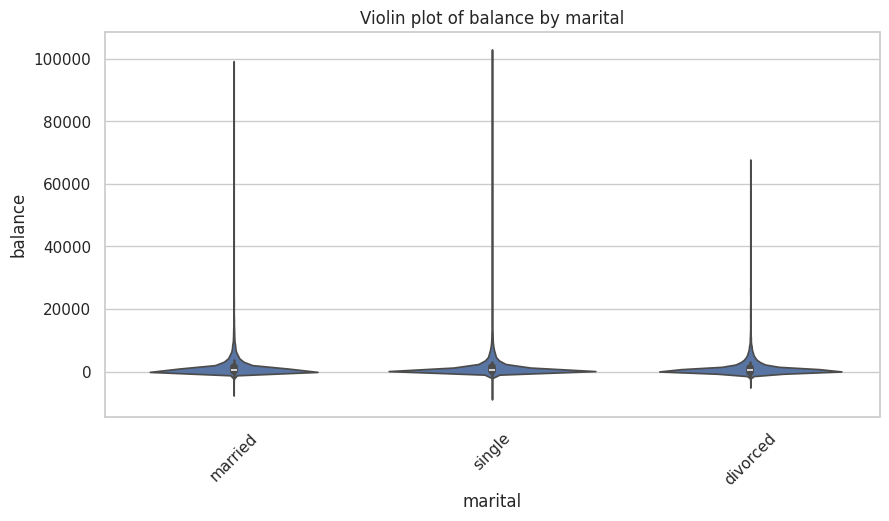


=== Numeric Variable: day | Categorical Variable: marital ===

            count       mean       std  min  25%   50%   75%   max
marital                                                           
divorced   5207.0  15.796428  8.262271  1.0  8.0  16.0  21.0  31.0
married   27217.0  15.853400  8.226938  1.0  8.0  16.0  21.0  31.0
single    12790.0  15.708210  8.546200  1.0  8.0  16.0  22.0  31.0


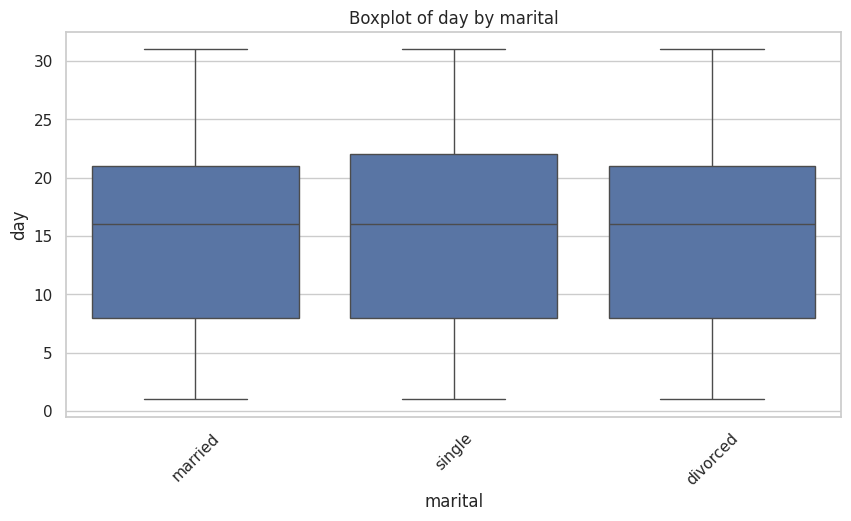

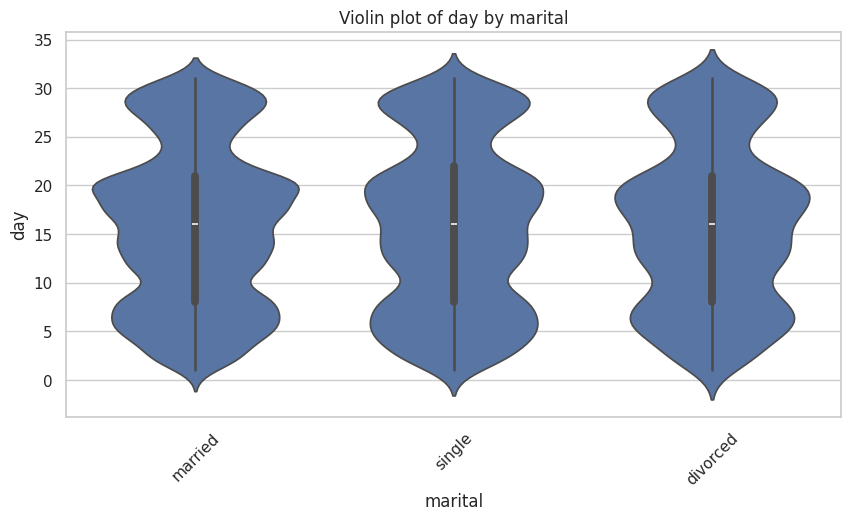


=== Numeric Variable: duration | Categorical Variable: marital ===

            count        mean         std  min    25%    50%    75%     max
marital                                                                    
divorced   5207.0  262.517188  263.807016  1.0  104.0  178.0  322.0  3094.0
married   27214.0  253.390755  253.147566  0.0  102.0  177.0  312.0  4918.0
single    12789.0  266.508093  263.853799  2.0  106.0  187.0  332.0  3785.0


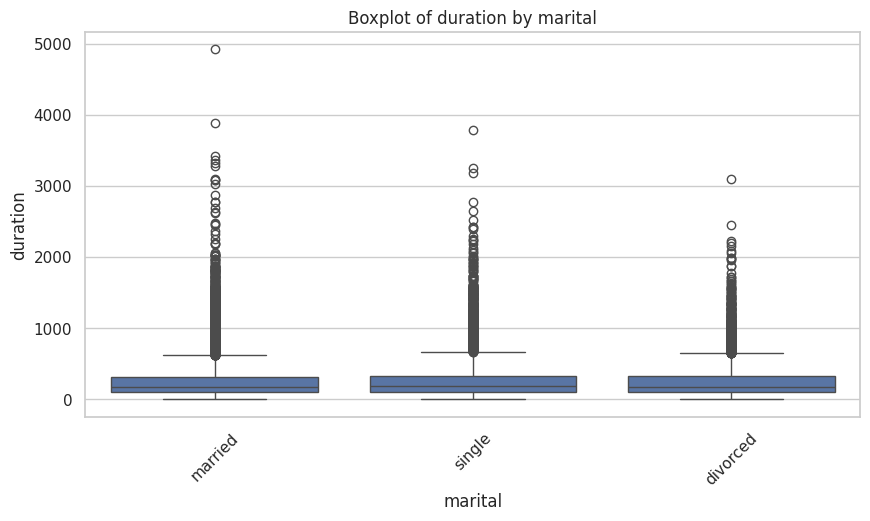

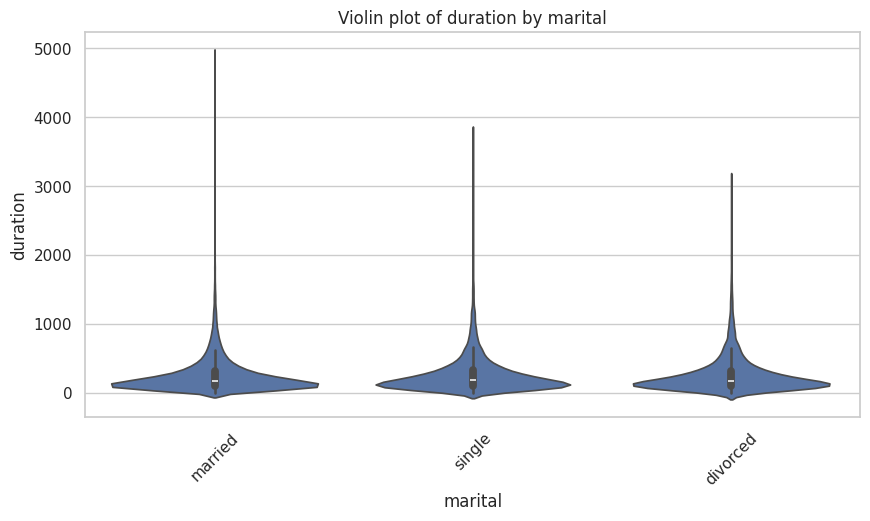


=== Numeric Variable: campaign | Categorical Variable: marital ===

            count      mean       std  min  25%  50%  75%   max
marital                                                        
divorced   5207.0  2.630882  2.796826  1.0  1.0  2.0  3.0  37.0
married   27217.0  2.842745  3.146009  1.0  1.0  2.0  3.0  63.0
single    12790.0  2.649805  3.106302  1.0  1.0  2.0  3.0  58.0


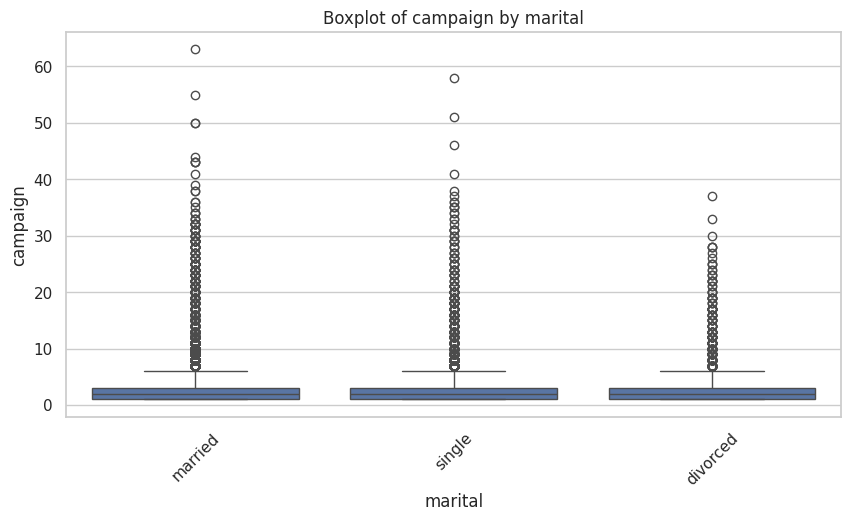

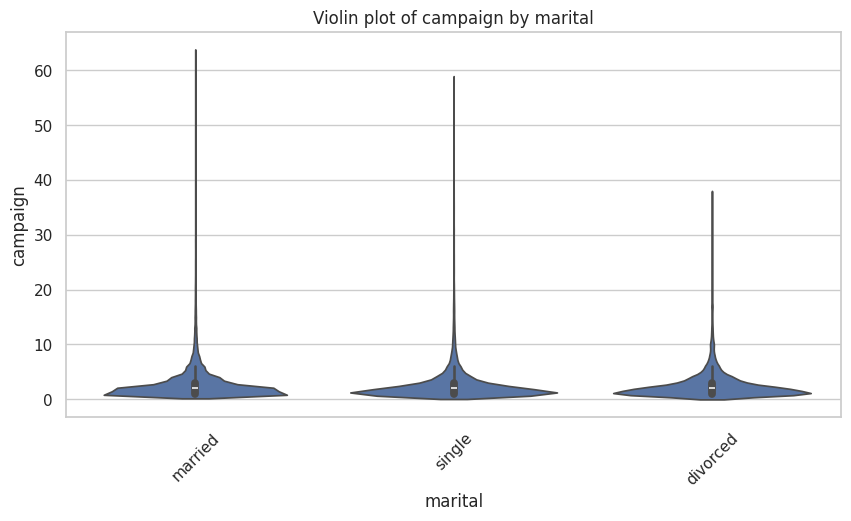


=== Numeric Variable: pdays | Categorical Variable: marital ===

            count       mean         std  min  25%  50%  75%    max
marital                                                            
divorced   5207.0  41.001728  102.327149 -1.0 -1.0 -1.0 -1.0  871.0
married   27217.0  37.946173   97.223082 -1.0 -1.0 -1.0 -1.0  842.0
single    12790.0  44.652385  105.041069 -1.0 -1.0 -1.0 -1.0  850.0


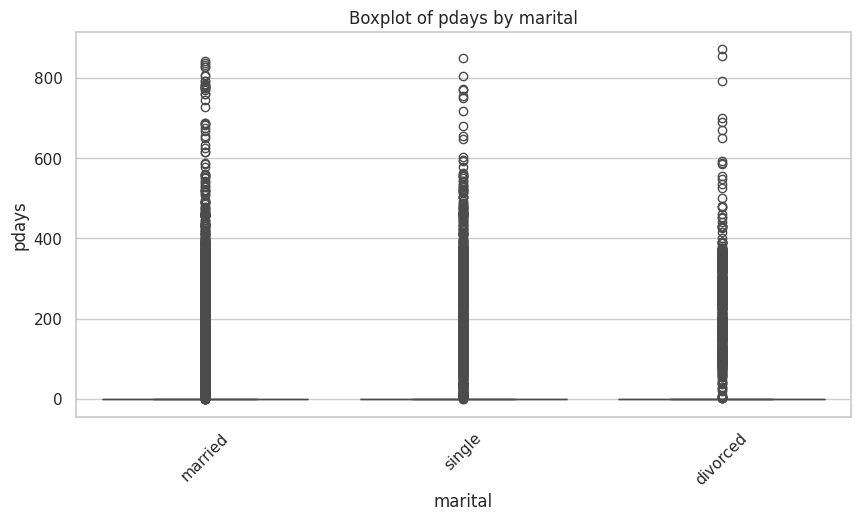

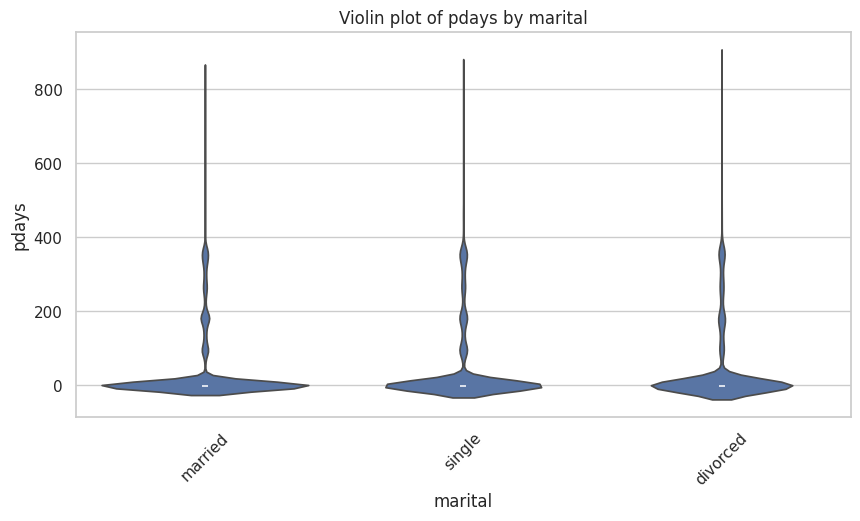


=== Numeric Variable: previous | Categorical Variable: marital ===

            count      mean       std  min  25%  50%  75%    max
marital                                                         
divorced   5207.0  0.551373  1.811625  0.0  0.0  0.0  0.0   30.0
married   27217.0  0.556490  2.478667  0.0  0.0  0.0  0.0  275.0
single    12790.0  0.642690  2.083432  0.0  0.0  0.0  0.0   51.0


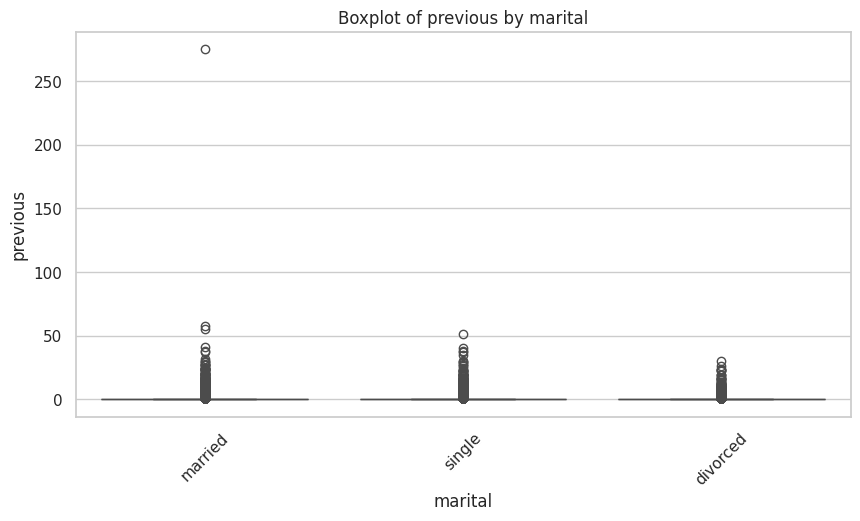

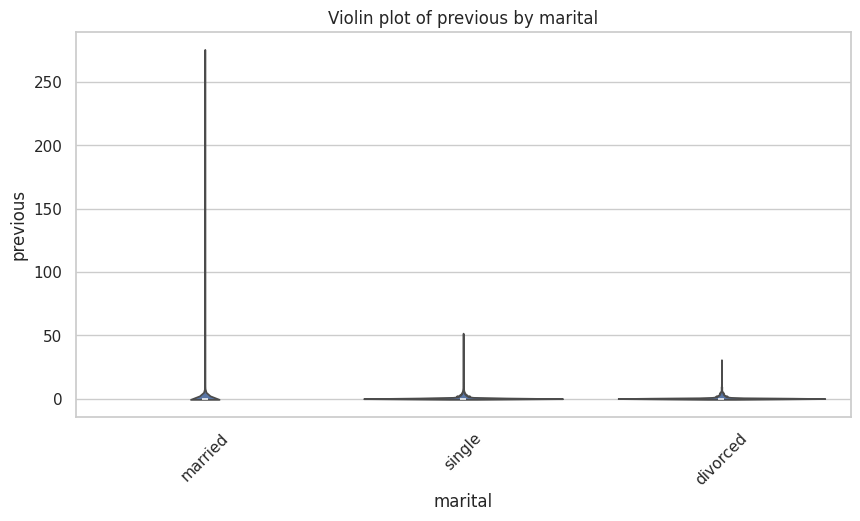


=== Numeric Variable: age | Categorical Variable: education ===

             count       mean        std   min   25%   50%   75%   max
education                                                             
primary     6851.0  45.865567  11.401980  18.0  37.0  45.0  54.0  95.0
secondary  23203.0  39.964186  10.159357  18.0  32.0  38.0  47.0  95.0
tertiary   13303.0  39.595129   9.888353  20.0  32.0  37.0  46.0  89.0
unknown     1857.0  44.510501  12.196400  18.0  36.0  45.0  53.0  93.0


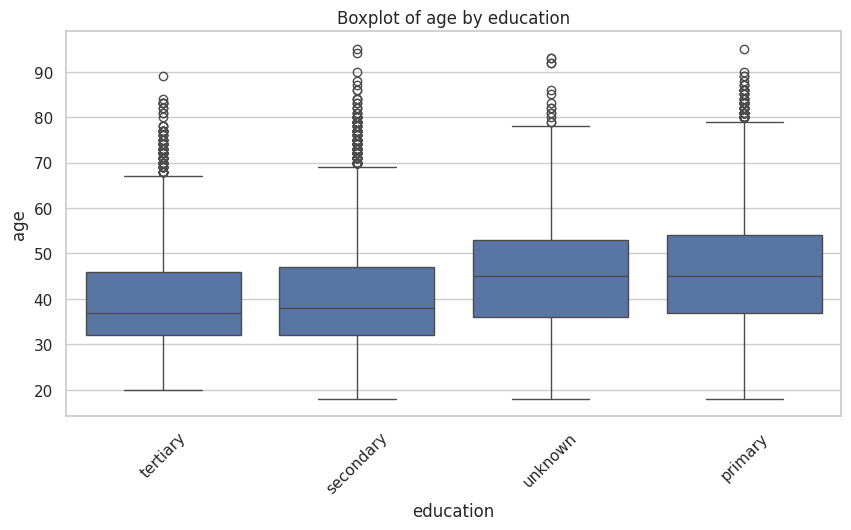

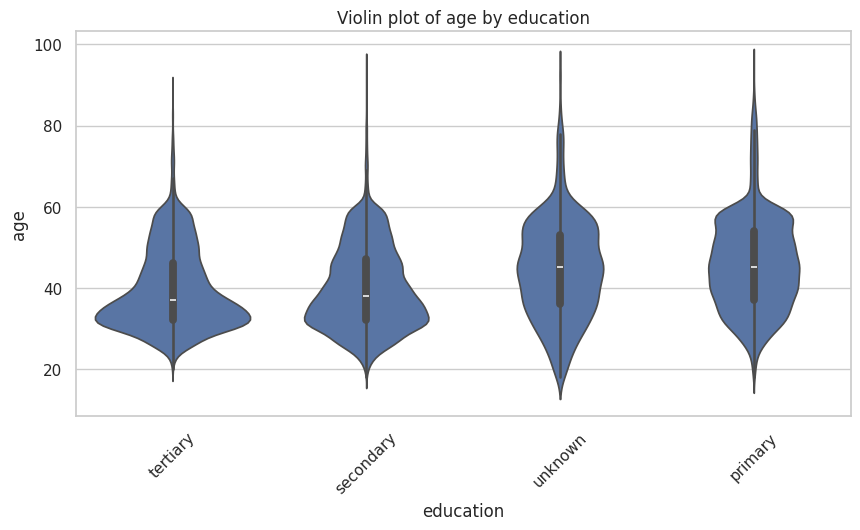


=== Numeric Variable: balance | Categorical Variable: education ===

             count         mean          std     min    25%    50%     75%  \
education                                                                    
primary     6851.0  1250.949934  2690.743991 -2604.0   61.0  403.0  1390.0   
secondary  23203.0  1154.832996  2558.211966 -8019.0   55.0  392.0  1234.0   
tertiary   13303.0  1758.369015  3838.811200 -6847.0  104.0  577.0  1804.5   
unknown     1857.0  1526.754443  3152.228273 -1445.0  106.0  568.0  1699.0   

                max  
education            
primary     71188.0  
secondary   81204.0  
tertiary   102127.0  
unknown     64343.0  


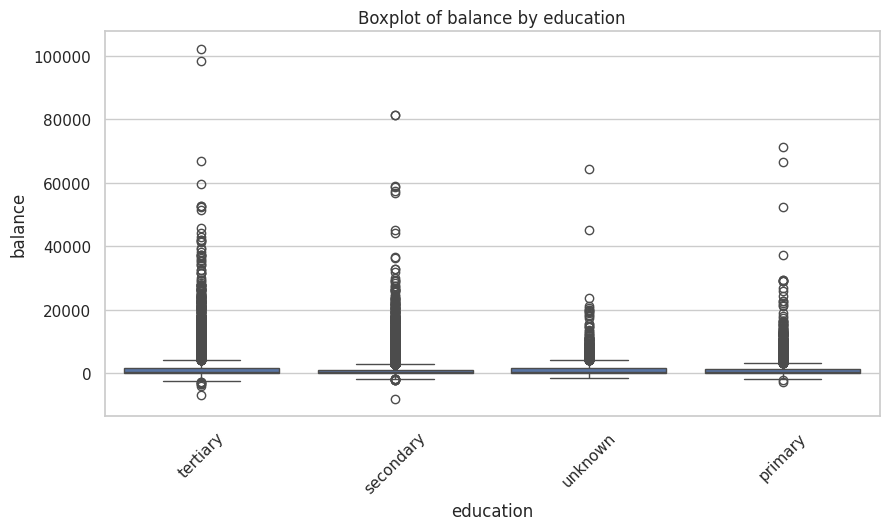

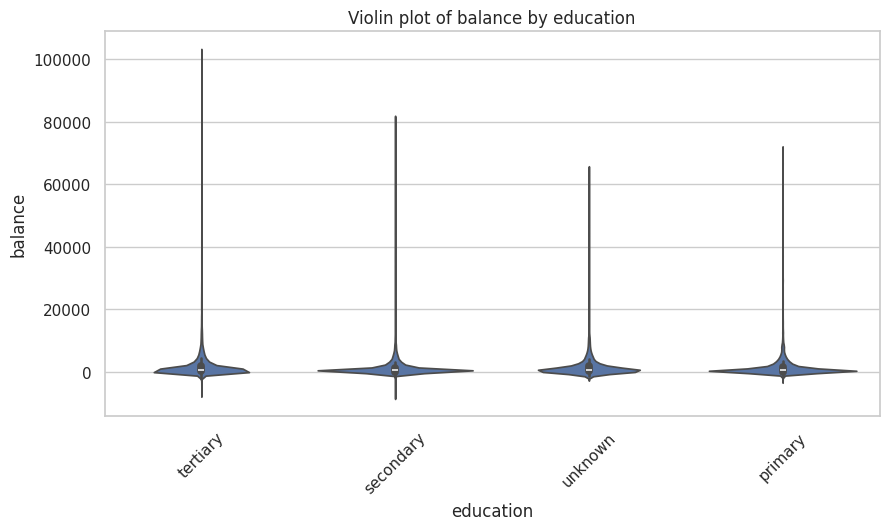


=== Numeric Variable: day | Categorical Variable: education ===

             count       mean       std  min  25%   50%   75%   max
education                                                          
primary     6851.0  15.421398  7.975752  1.0  9.0  15.0  21.0  31.0
secondary  23203.0  15.758738  8.307167  1.0  8.0  16.0  21.0  31.0
tertiary   13303.0  16.085018  8.462272  1.0  8.0  17.0  22.0  31.0
unknown     1857.0  15.810985  8.689590  1.0  8.0  16.0  22.0  31.0


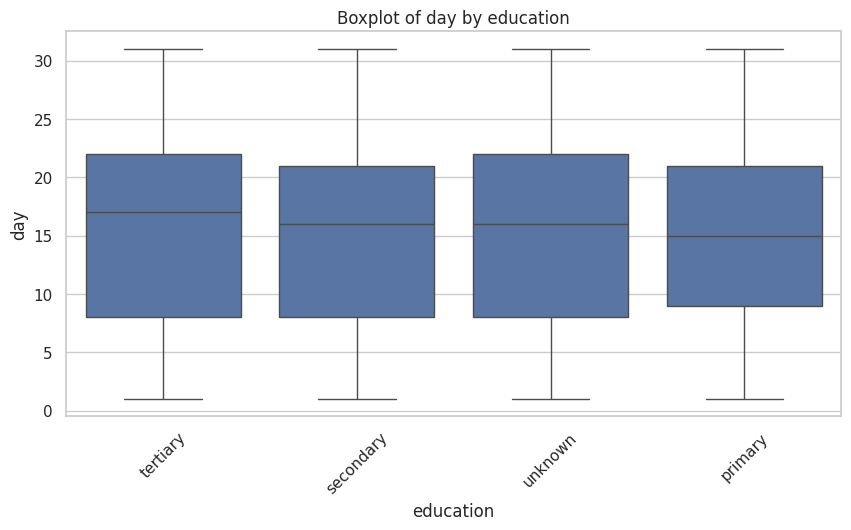

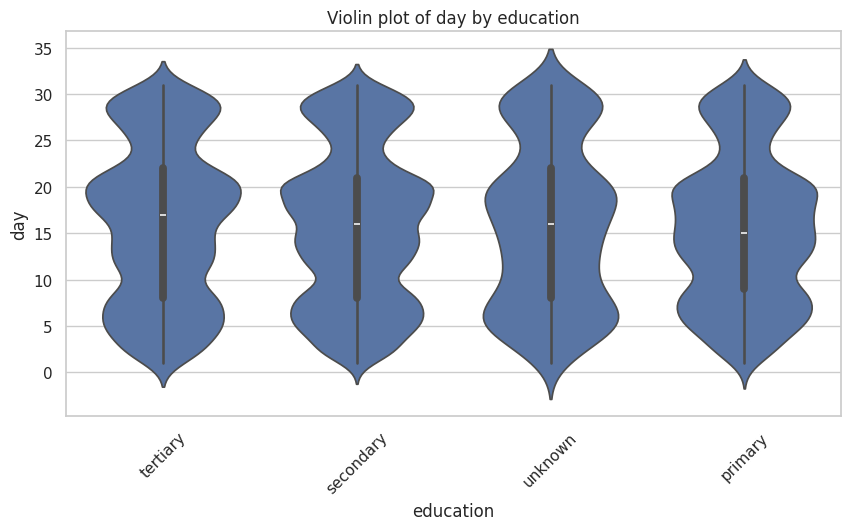


=== Numeric Variable: duration | Categorical Variable: education ===

             count        mean         std  min    25%    50%    75%     max
education                                                                   
primary     6851.0  255.933002  260.279981  0.0  103.0  178.0  312.0  3078.0
secondary  23199.0  258.669900  253.305646  0.0  105.0  183.0  321.0  3881.0
tertiary   13303.0  258.510336  264.919610  2.0  101.0  176.0  318.0  4918.0
unknown     1857.0  257.313947  245.622775  4.0   99.0  180.0  332.0  2429.0


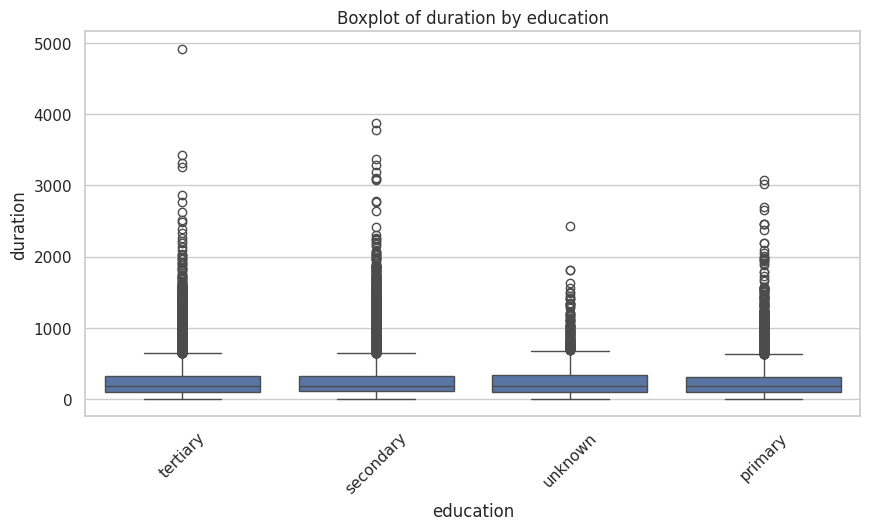

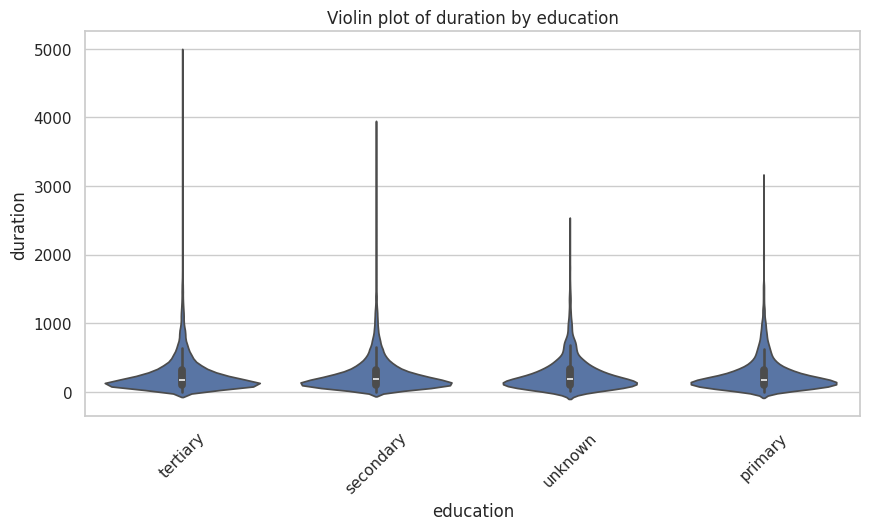


=== Numeric Variable: campaign | Categorical Variable: education ===

             count      mean       std  min  25%  50%  75%   max
education                                                       
primary     6851.0  2.834331  3.166683  1.0  1.0  2.0  3.0  58.0
secondary  23203.0  2.700728  2.985742  1.0  1.0  2.0  3.0  55.0
tertiary   13303.0  2.825453  3.146557  1.0  1.0  2.0  3.0  51.0
unknown     1857.0  2.849219  3.778611  1.0  1.0  2.0  3.0  63.0


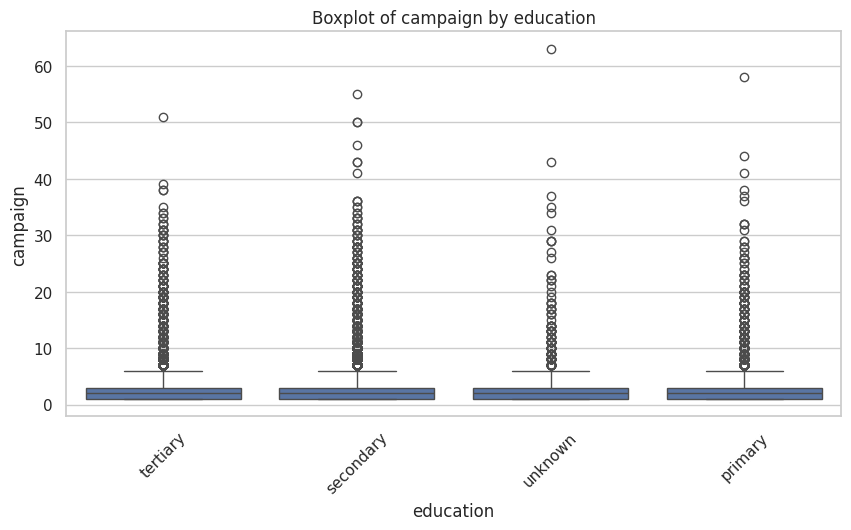

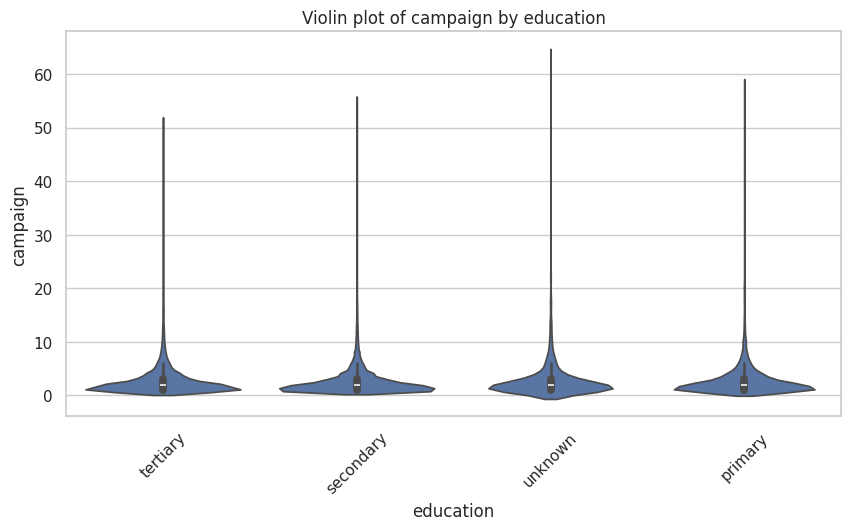


=== Numeric Variable: pdays | Categorical Variable: education ===

             count       mean         std  min  25%  50%  75%    max
education                                                           
primary     6851.0  36.081740   97.557124 -1.0 -1.0 -1.0 -1.0  791.0
secondary  23203.0  42.351636  103.587850 -1.0 -1.0 -1.0 -1.0  842.0
tertiary   13303.0  39.018116   95.774081 -1.0 -1.0 -1.0 -1.0  871.0
unknown     1857.0  36.856220   95.226077 -1.0 -1.0 -1.0 -1.0  687.0


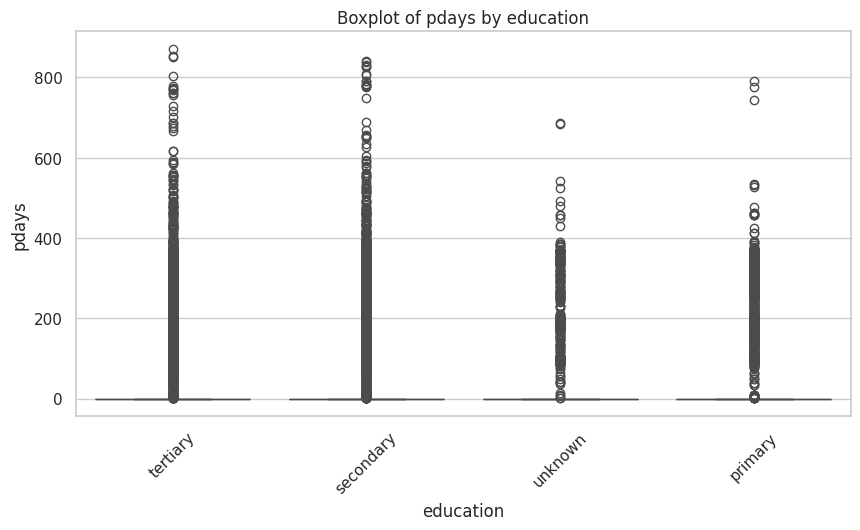

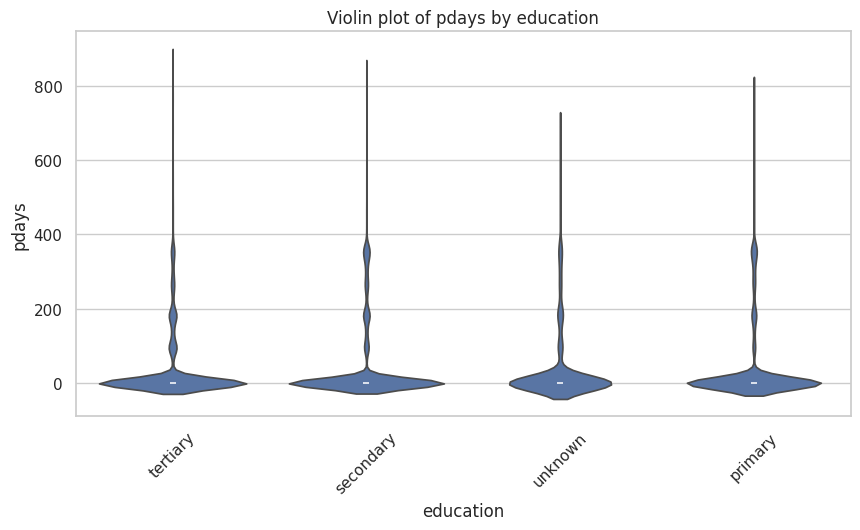


=== Numeric Variable: previous | Categorical Variable: education ===

             count      mean       std  min  25%  50%  75%    max
education                                                        
primary     6851.0  0.489272  1.897365  0.0  0.0  0.0  0.0   58.0
secondary  23203.0  0.567728  1.849831  0.0  0.0  0.0  0.0   55.0
tertiary   13303.0  0.661881  3.139243  0.0  0.0  0.0  0.0  275.0
unknown     1857.0  0.488422  1.569167  0.0  0.0  0.0  0.0   27.0


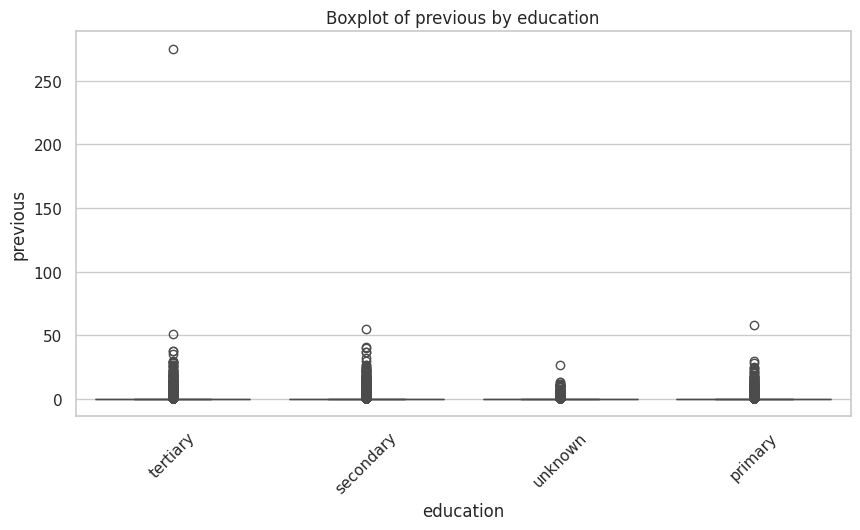

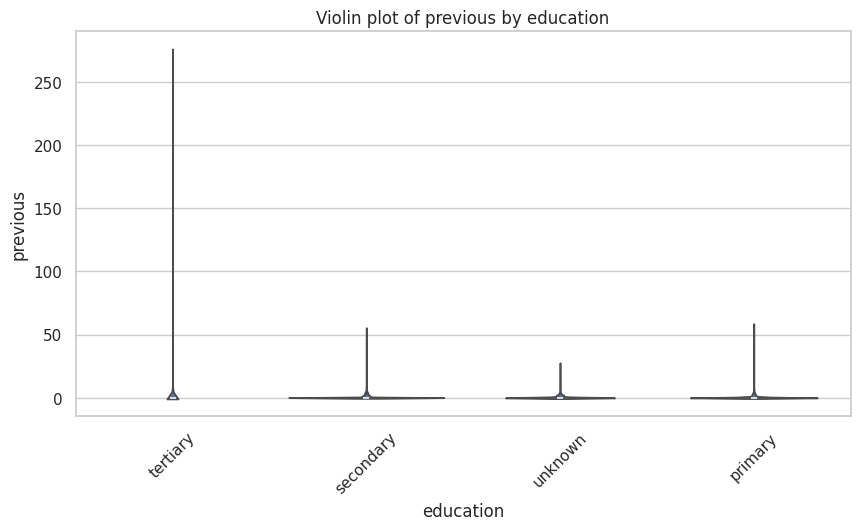


=== Numeric Variable: age | Categorical Variable: default ===

           count       mean        std   min   25%   50%   75%   max
default                                                             
no       44399.0  40.962251  10.638805  18.0  33.0  39.0  48.0  95.0
yes        815.0  39.534969   9.357804  21.0  32.0  38.0  47.0  71.0


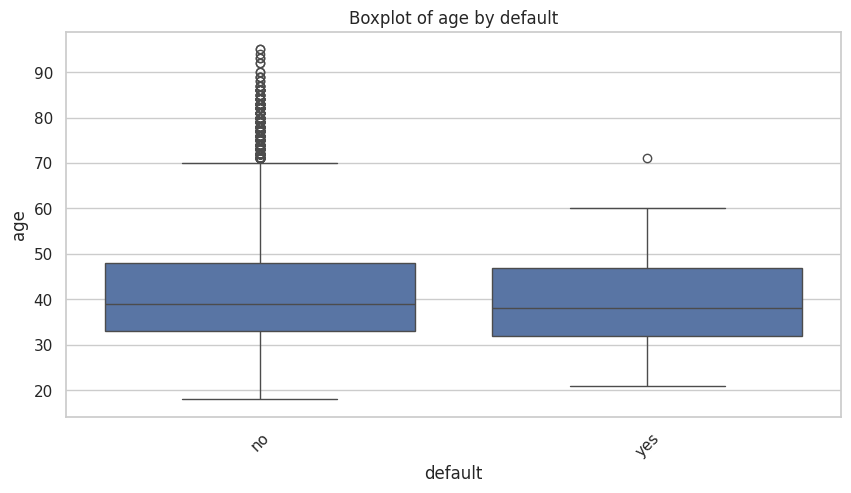

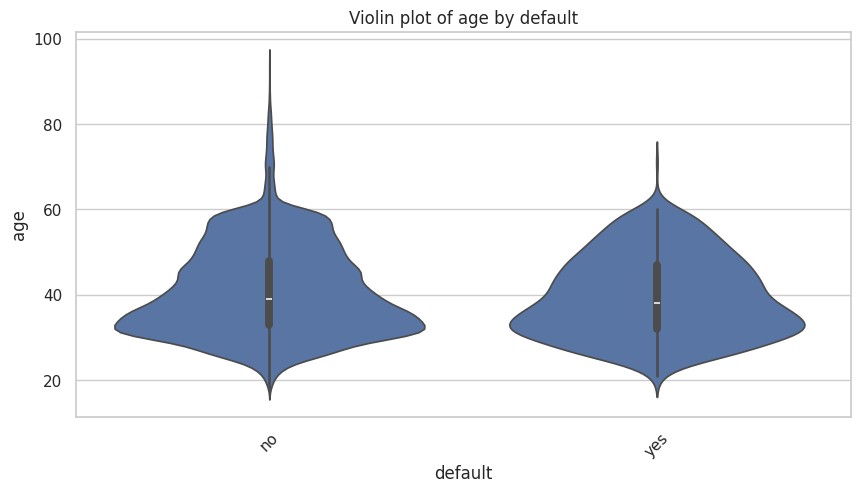


=== Numeric Variable: balance | Categorical Variable: default ===

           count         mean          std     min    25%    50%     75%  \
default                                                                    
no       44399.0  1389.778554  3063.182182 -4057.0   84.0  468.0  1462.5   
yes        815.0  -137.624540   906.704678 -8019.0 -339.0   -7.0    15.0   

              max  
default            
no       102127.0  
yes       16486.0  


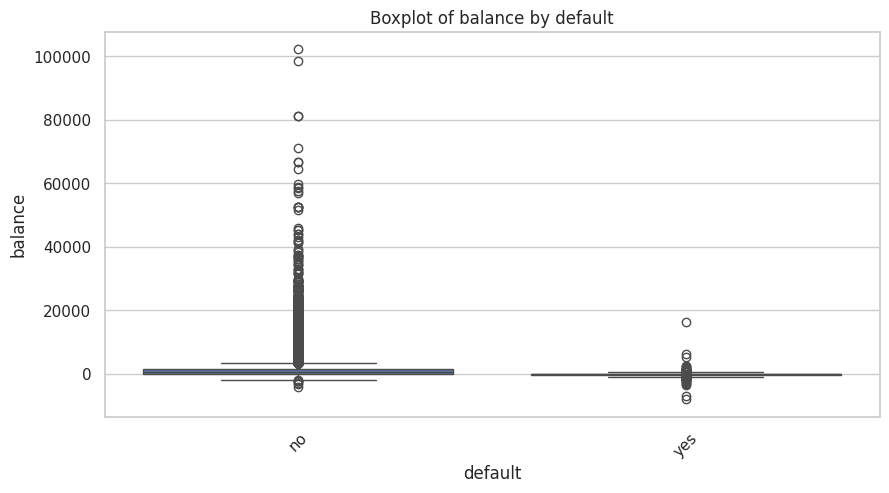

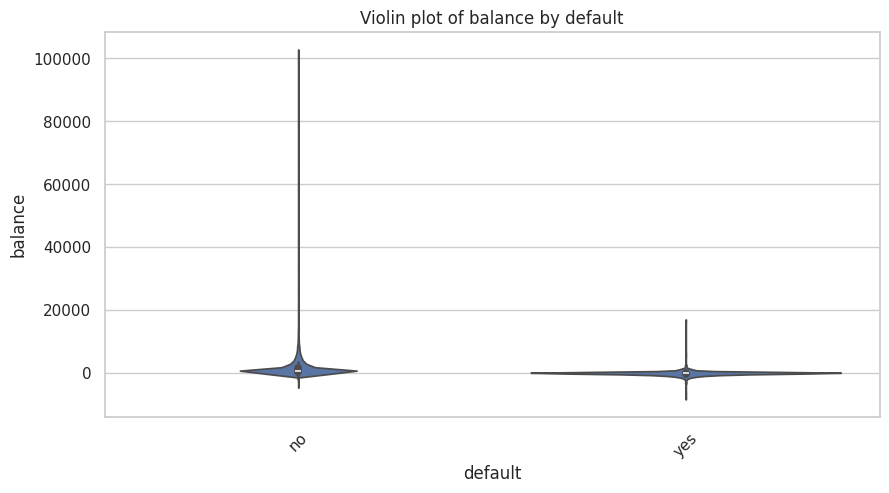


=== Numeric Variable: day | Categorical Variable: default ===

           count       mean       std  min  25%   50%   75%   max
default                                                          
no       44399.0  15.795131  8.317805  1.0  8.0  16.0  21.0  31.0
yes        815.0  16.385276  8.564183  1.0  8.0  17.0  23.0  31.0


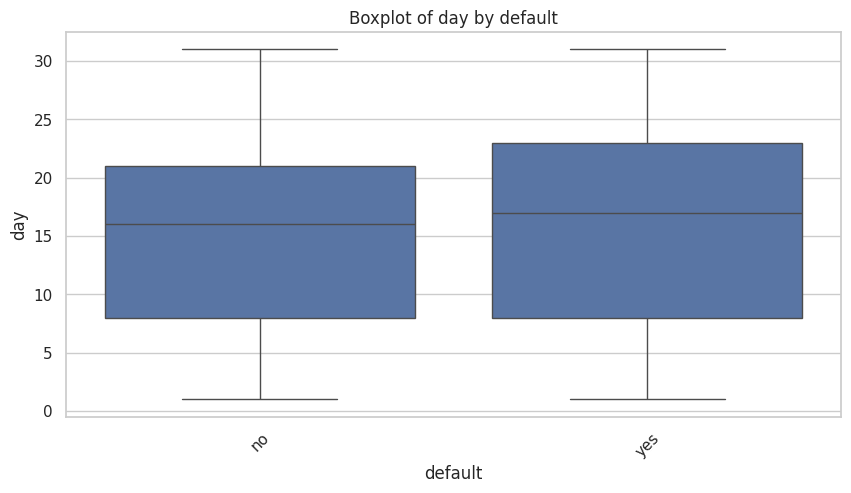

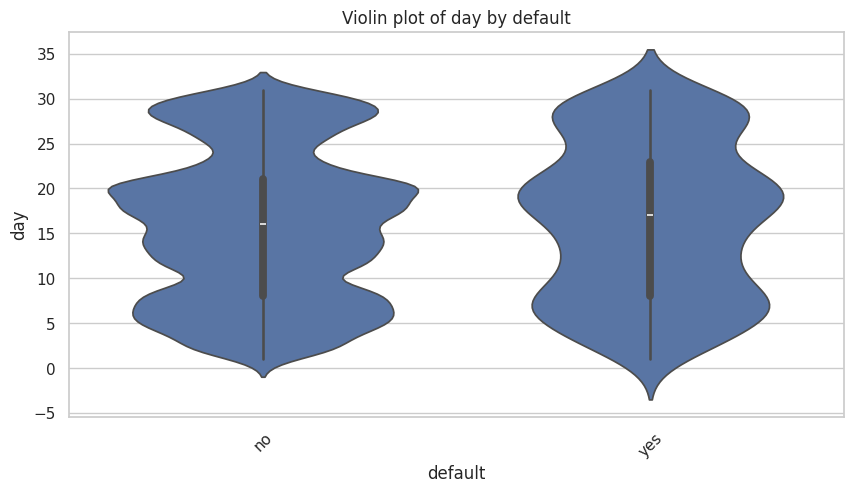


=== Numeric Variable: duration | Categorical Variable: default ===

           count        mean         std  min    25%    50%    75%     max
default                                                                   
no       44395.0  258.501993  258.231769  0.0  103.0  180.0  319.0  4918.0
yes        815.0  239.115337  214.512375  3.0   97.0  172.0  305.0  1558.0


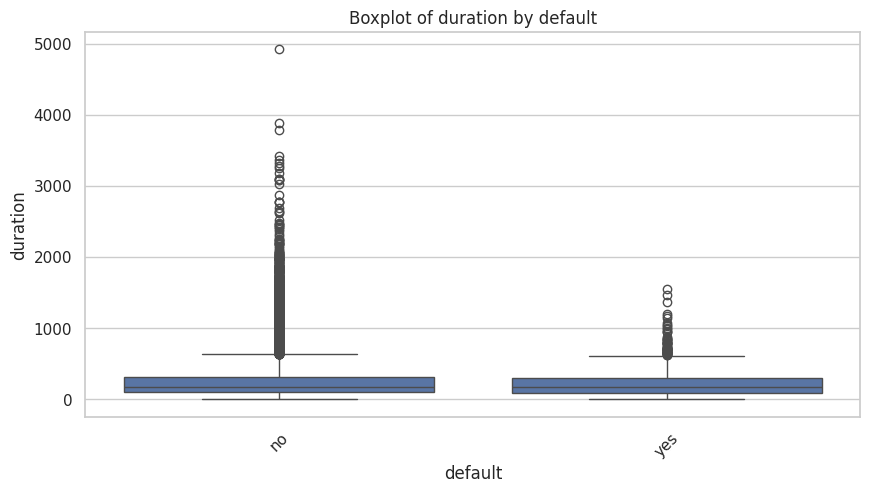

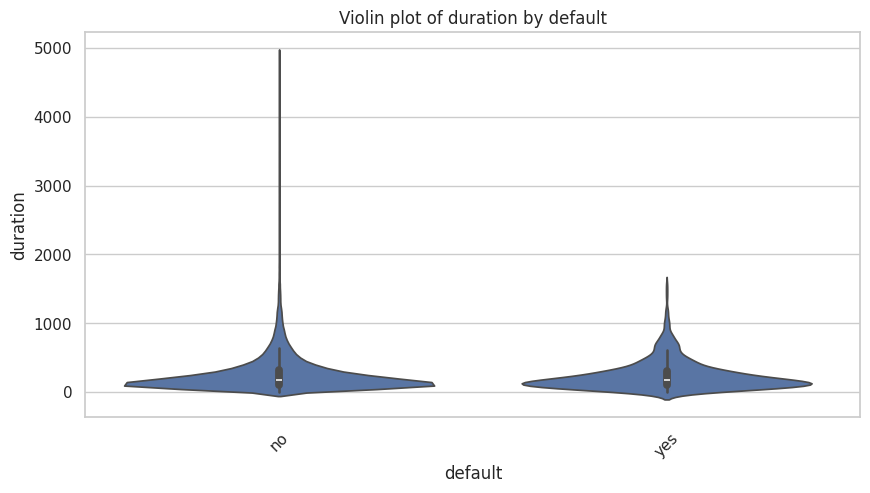


=== Numeric Variable: campaign | Categorical Variable: default ===

           count      mean       std  min  25%  50%  75%   max
default                                                       
no       44399.0  2.756706  3.086957  1.0  1.0  2.0  3.0  63.0
yes        815.0  3.148466  3.628145  1.0  1.0  2.0  4.0  36.0


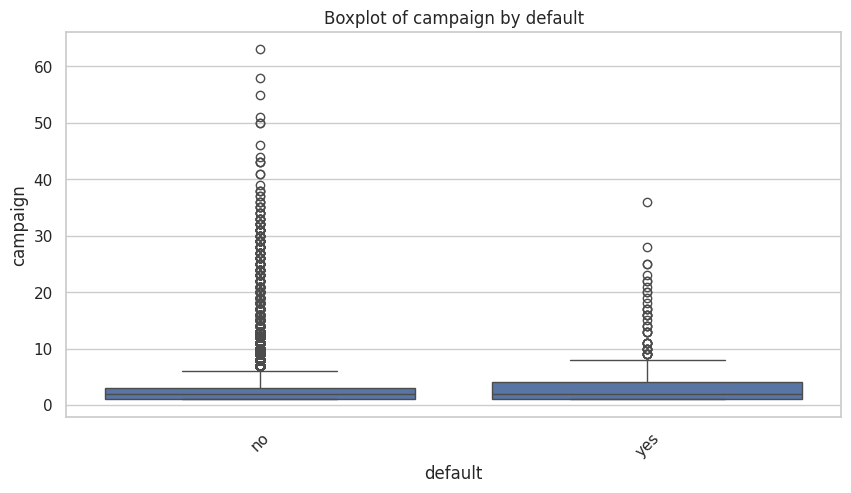

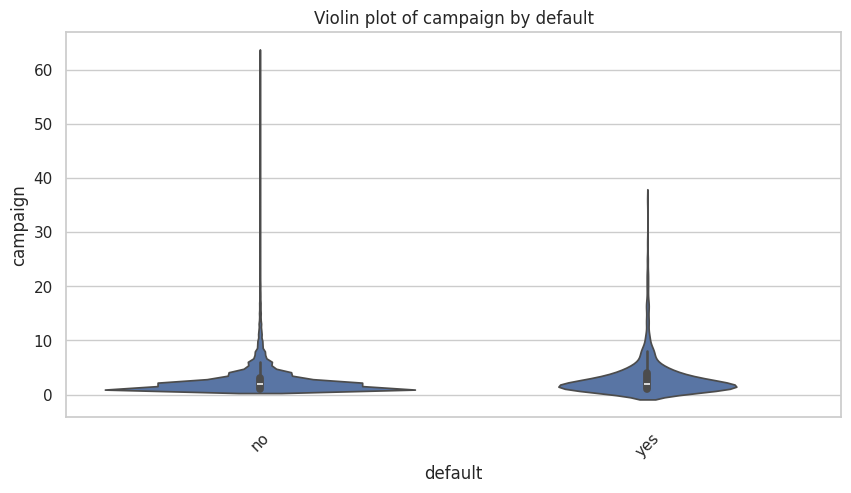


=== Numeric Variable: pdays | Categorical Variable: default ===

           count       mean         std  min  25%  50%  75%    max
default                                                           
no       44399.0  40.601725  100.501816 -1.0 -1.0 -1.0 -1.0  871.0
yes        815.0  18.042945   73.651493 -1.0 -1.0 -1.0 -1.0  521.0


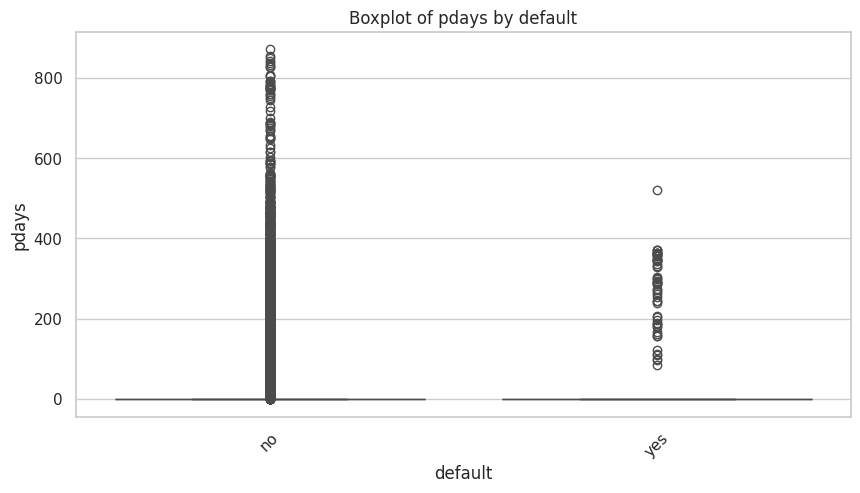

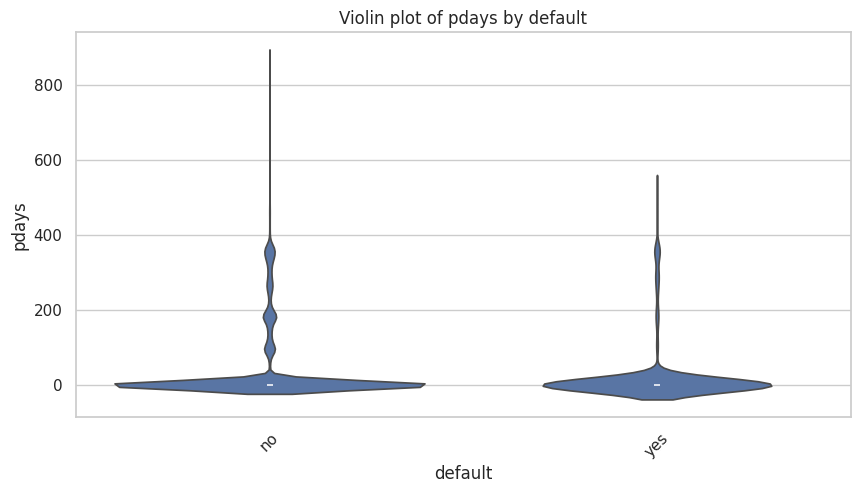


=== Numeric Variable: previous | Categorical Variable: default ===

           count      mean       std  min  25%  50%  75%    max
default                                                        
no       44399.0  0.586004  2.313523  0.0  0.0  0.0  0.0  275.0
yes        815.0  0.268712  1.629787  0.0  0.0  0.0  0.0   25.0


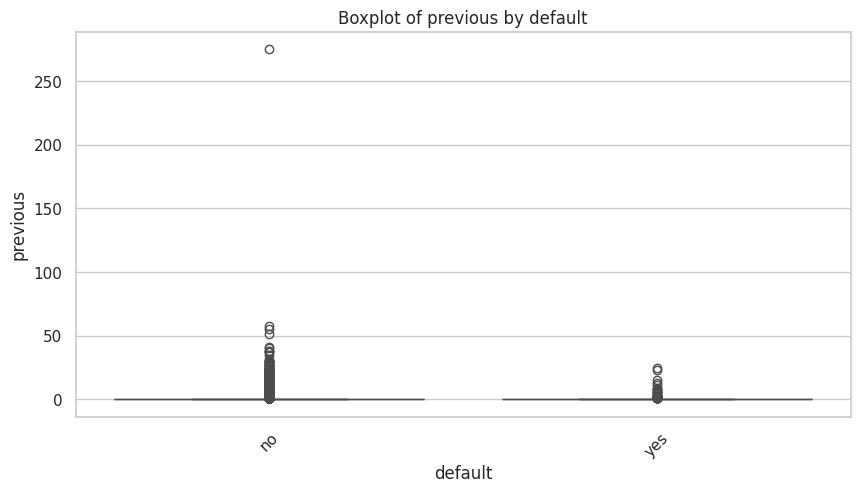

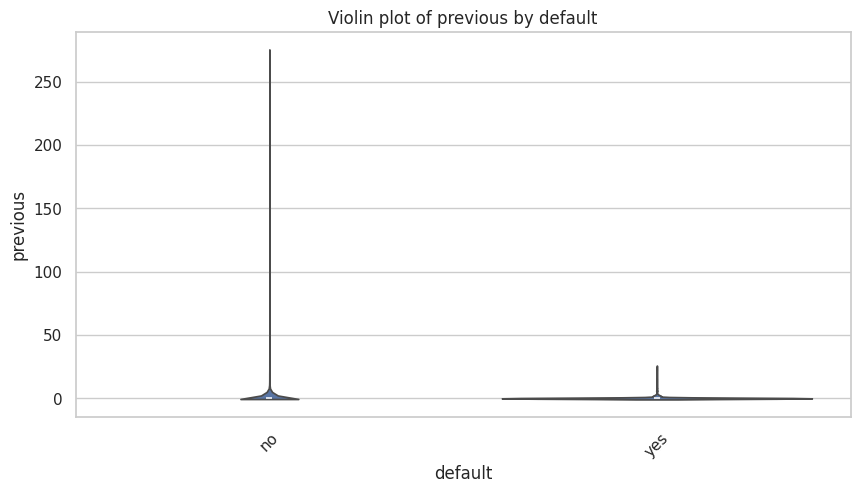


=== Numeric Variable: age | Categorical Variable: housing ===

           count       mean        std   min   25%   50%   75%   max
housing                                                             
no       20082.0  43.139827  12.058399  18.0  33.0  42.0  52.0  95.0
yes      25132.0  39.175951   8.927163  20.0  32.0  38.0  45.0  78.0


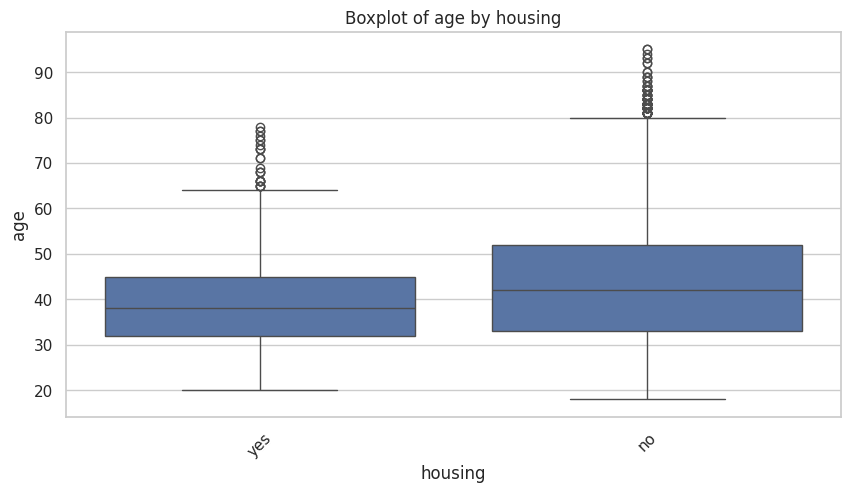

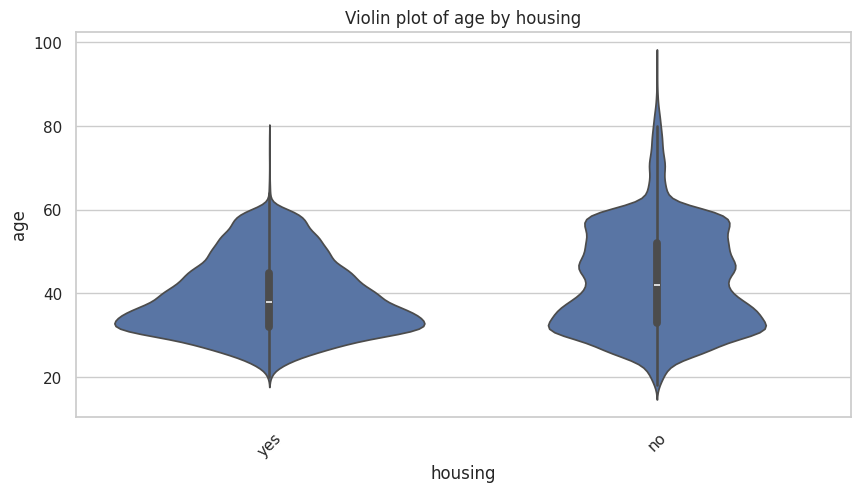


=== Numeric Variable: balance | Categorical Variable: housing ===

           count         mean          std     min   25%    50%     75%  \
housing                                                                   
no       20082.0  1596.458819  3613.320375 -8019.0  85.0  507.0  1708.0   
yes      25132.0  1175.096610  2483.204650 -4057.0  62.0  412.0  1258.0   

              max  
housing            
no       102127.0  
yes       58544.0  


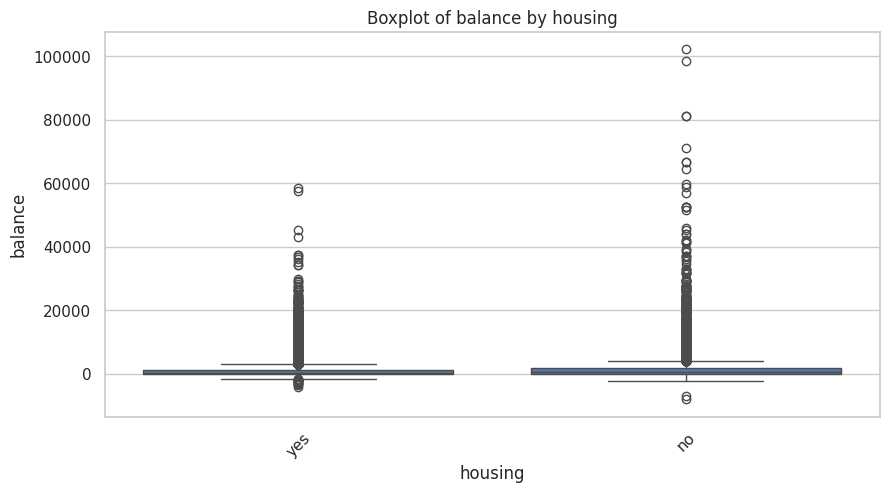

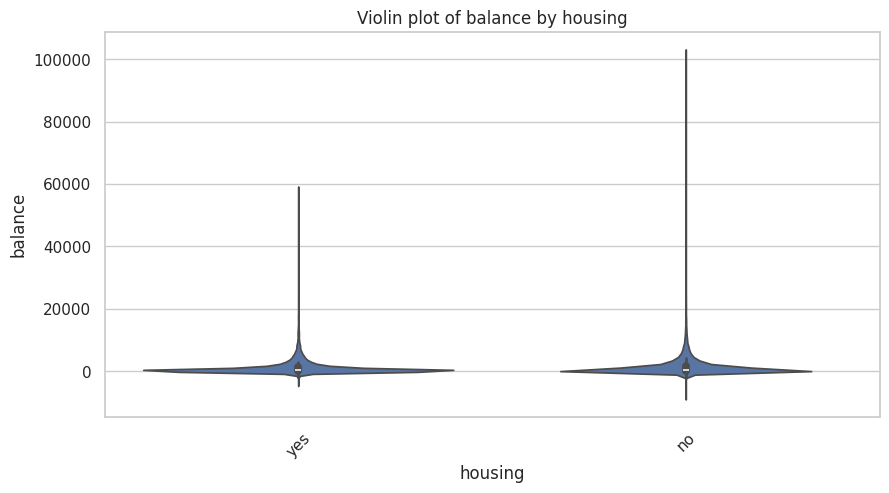


=== Numeric Variable: day | Categorical Variable: housing ===

           count       mean       std  min  25%   50%   75%   max
housing                                                          
no       20082.0  16.066428  8.671512  1.0  8.0  17.0  23.0  31.0
yes      25132.0  15.597485  8.026973  1.0  8.0  15.0  21.0  31.0


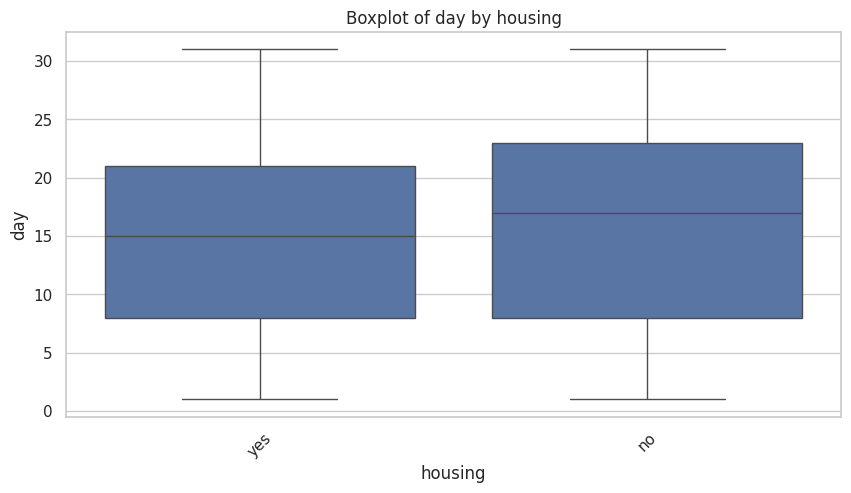

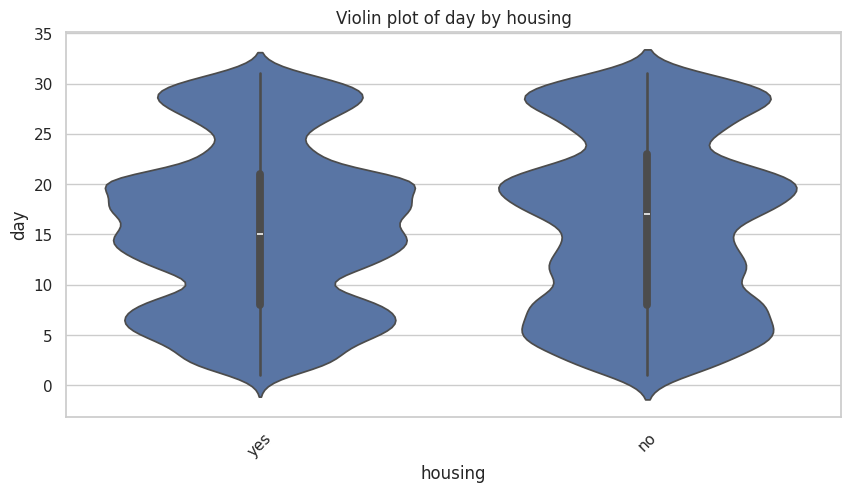


=== Numeric Variable: duration | Categorical Variable: housing ===

           count        mean         std  min    25%    50%    75%     max
housing                                                                   
no       20081.0  256.698820  256.530166  0.0  103.0  178.0  320.0  3881.0
yes      25129.0  259.314179  258.307974  0.0  103.0  182.0  318.0  4918.0


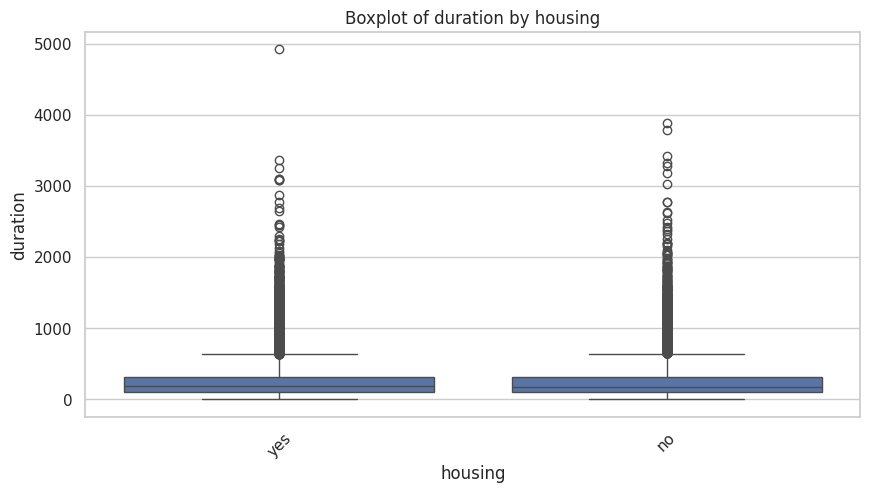

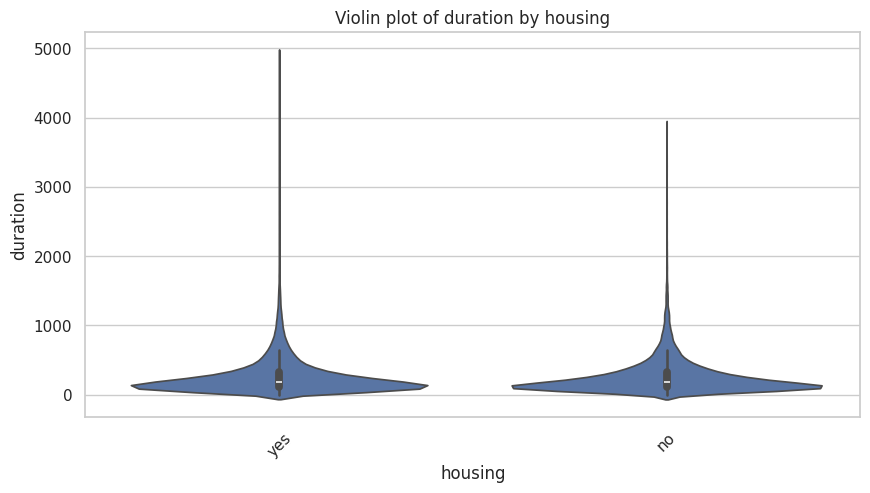


=== Numeric Variable: campaign | Categorical Variable: housing ===

           count      mean       std  min  25%  50%  75%   max
housing                                                       
no       20082.0  2.845533  3.041460  1.0  1.0  2.0  3.0  41.0
yes      25132.0  2.698432  3.140873  1.0  1.0  2.0  3.0  63.0


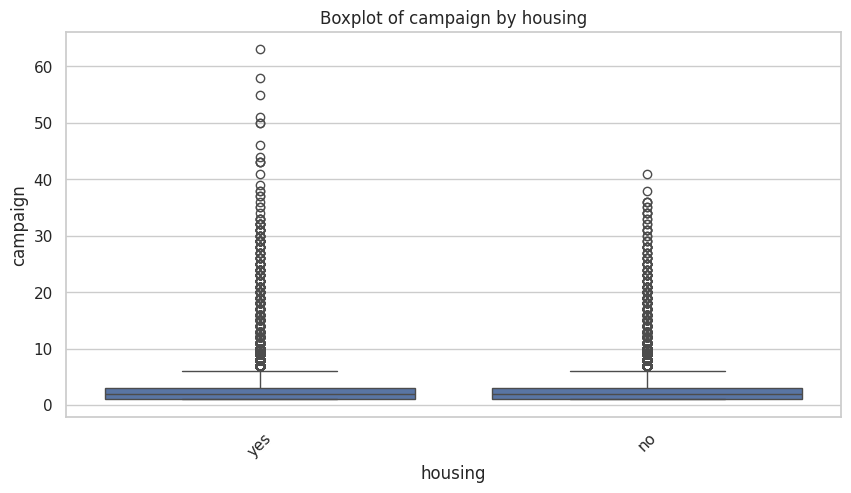

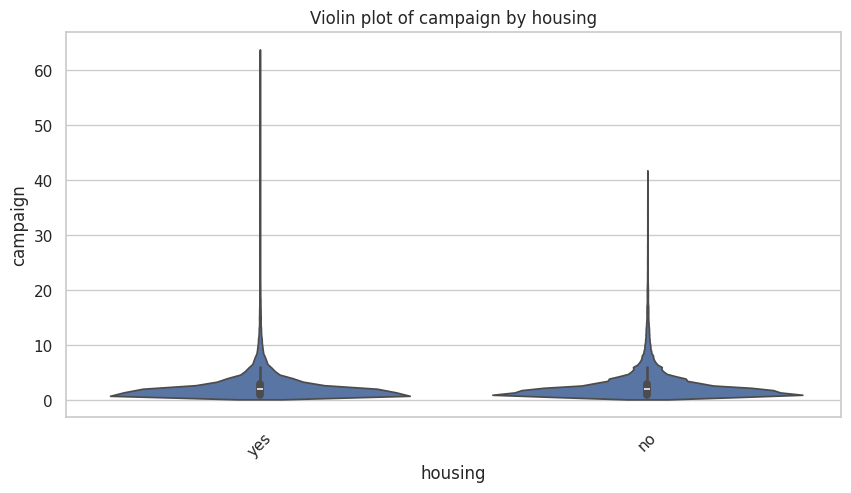


=== Numeric Variable: pdays | Categorical Variable: housing ===

           count       mean         std  min  25%  50%  75%    max
housing                                                           
no       20082.0  26.287222   77.459343 -1.0 -1.0 -1.0 -1.0  871.0
yes      25132.0  51.308332  113.859273 -1.0 -1.0 -1.0 -1.0  854.0


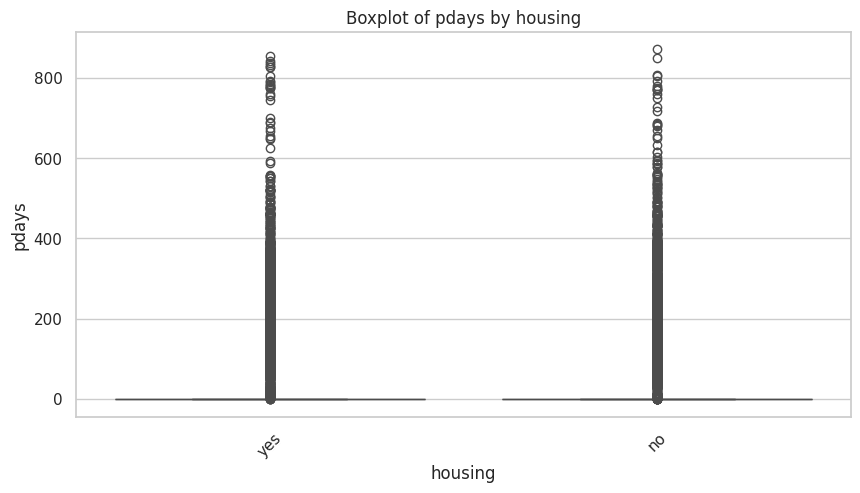

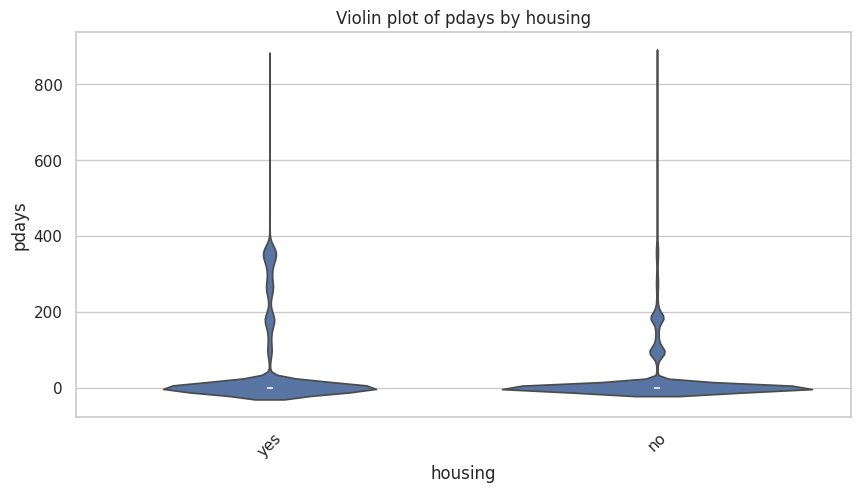


=== Numeric Variable: previous | Categorical Variable: housing ===

           count      mean       std  min  25%  50%  75%    max
housing                                                        
no       20082.0  0.484762  1.660189  0.0  0.0  0.0  0.0   37.0
yes      25132.0  0.656613  2.707326  0.0  0.0  0.0  0.0  275.0


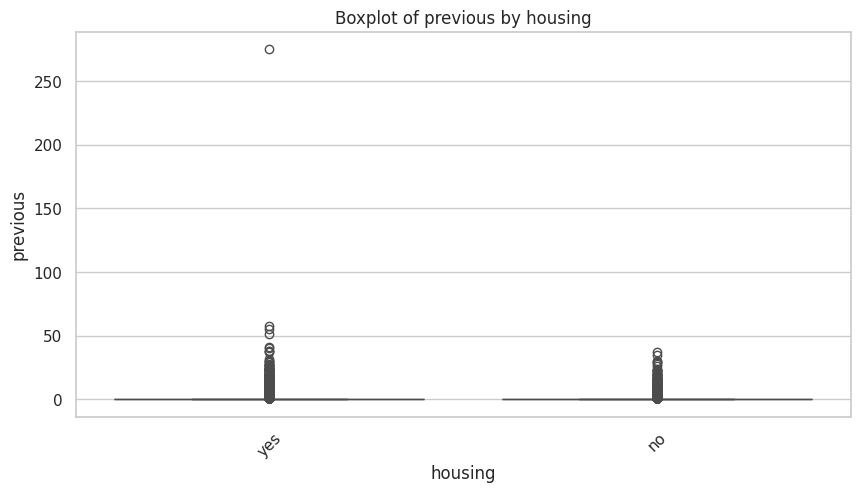

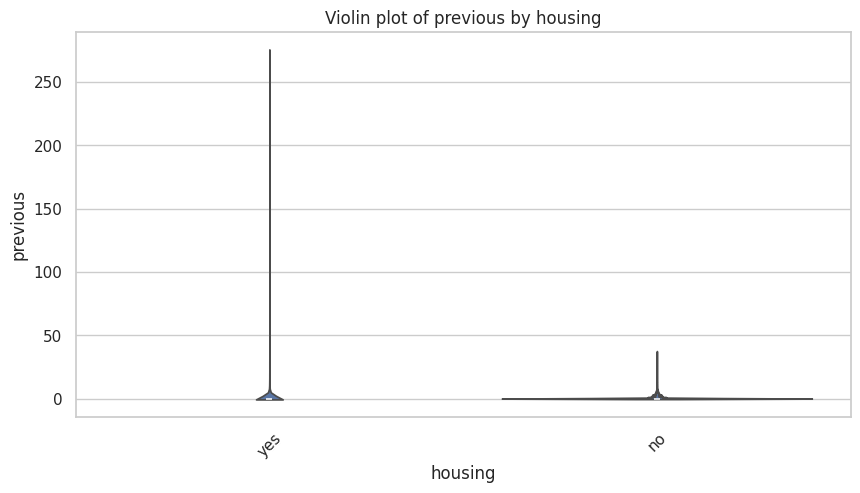


=== Numeric Variable: age | Categorical Variable: loan ===

        count       mean        std   min   25%   50%   75%   max
loan                                                             
no    37969.0  41.009271  10.787283  18.0  33.0  39.0  48.0  95.0
yes    7245.0  40.555280   9.679023  20.0  33.0  39.0  48.0  72.0


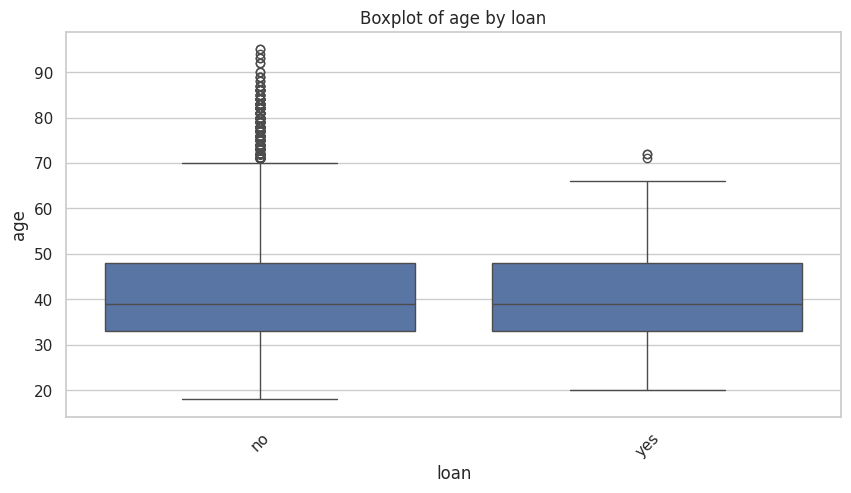

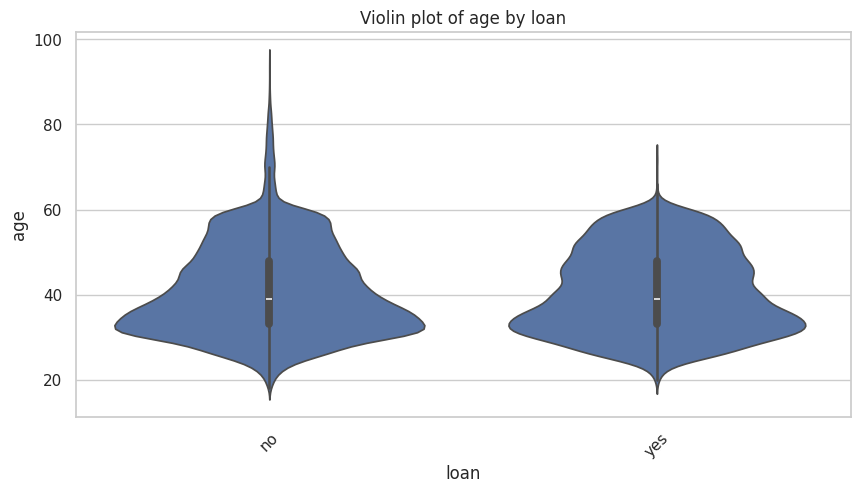


=== Numeric Variable: balance | Categorical Variable: loan ===

        count         mean          std     min   25%    50%     75%       max
loan                                                                          
no    37969.0  1474.451974  3204.008585 -4057.0  94.0  496.0  1558.0  102127.0
yes    7245.0   774.209386  1908.170718 -8019.0   2.0  258.0   864.0   51439.0


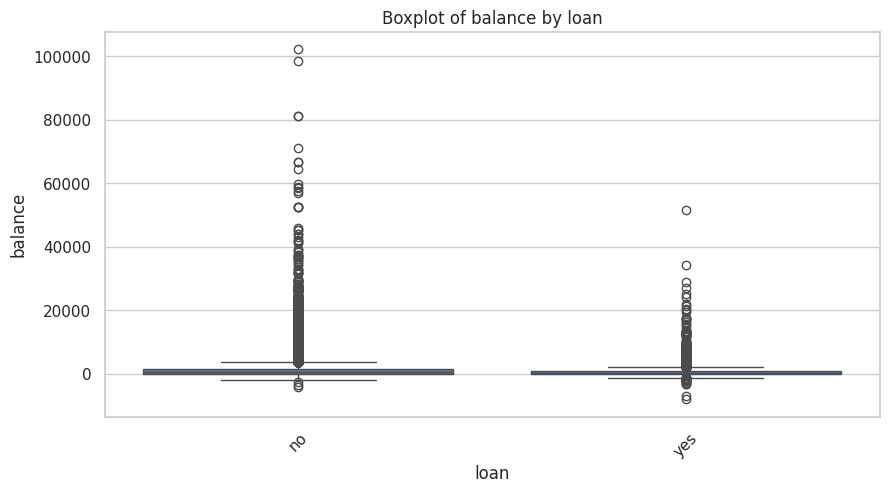

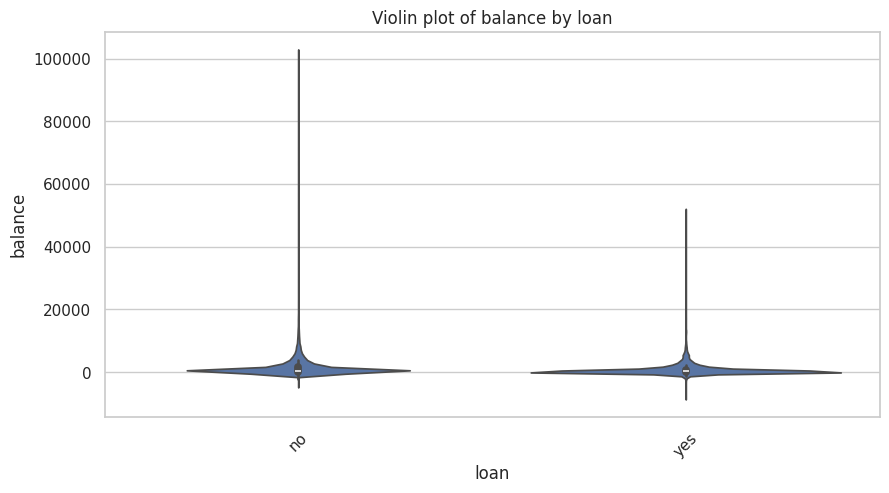


=== Numeric Variable: day | Categorical Variable: loan ===

        count       mean       std  min  25%   50%   75%   max
loan                                                          
no    37969.0  15.764571  8.306032  1.0  8.0  16.0  21.0  31.0
yes    7245.0  16.021670  8.406070  1.0  8.0  17.0  22.0  31.0


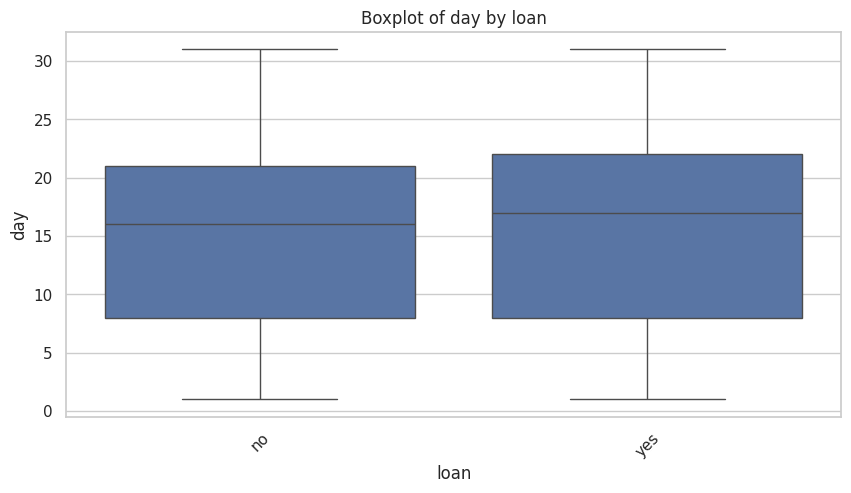

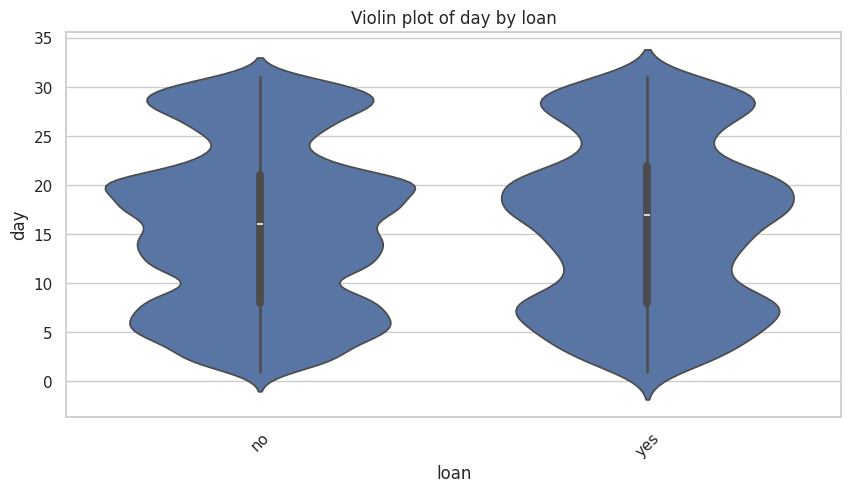


=== Numeric Variable: duration | Categorical Variable: loan ===

        count        mean         std  min    25%    50%    75%     max
loan                                                                   
no    37966.0  259.546831  258.265161  0.0  103.0  181.0  322.0  4918.0
yes    7244.0  250.844837  253.472689  0.0  102.0  174.0  304.0  3422.0


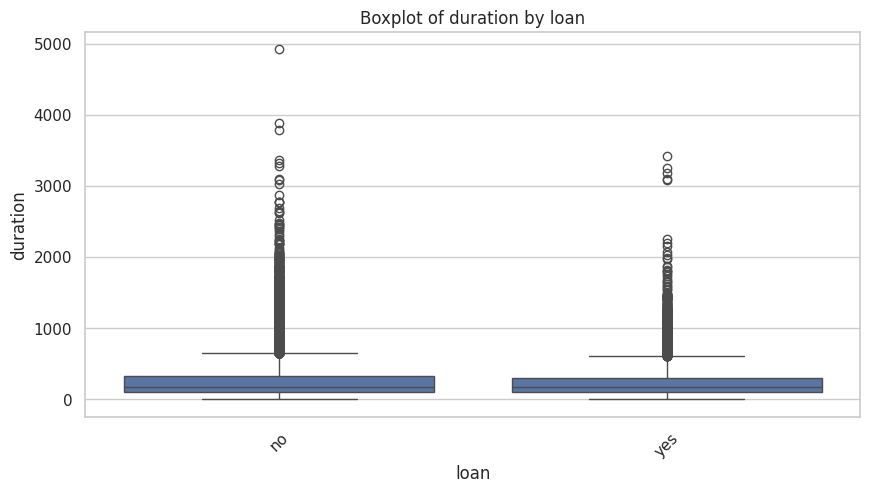

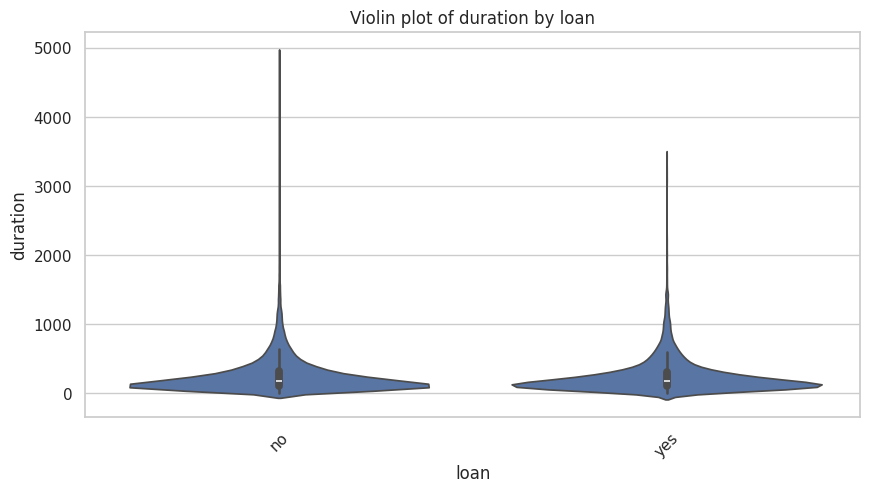


=== Numeric Variable: campaign | Categorical Variable: loan ===

        count      mean       std  min  25%  50%  75%   max
loan                                                       
no    37969.0  2.750296  3.050597  1.0  1.0  2.0  3.0  63.0
yes    7245.0  2.834369  3.334417  1.0  1.0  2.0  3.0  50.0


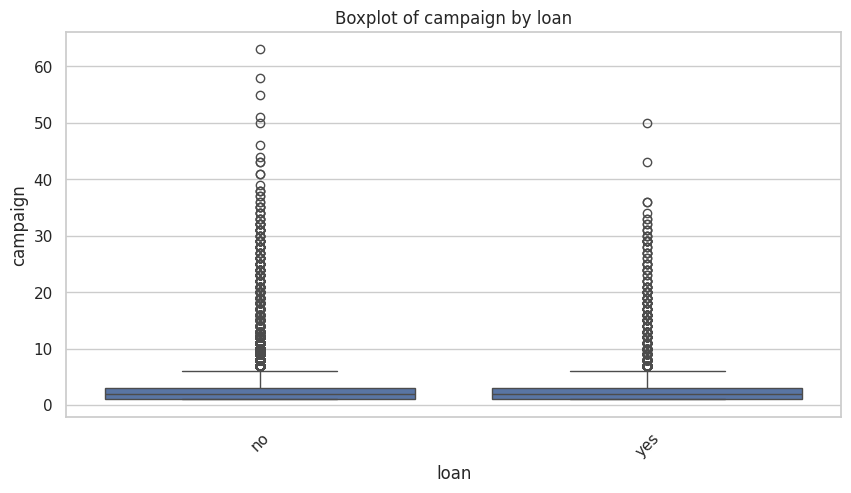

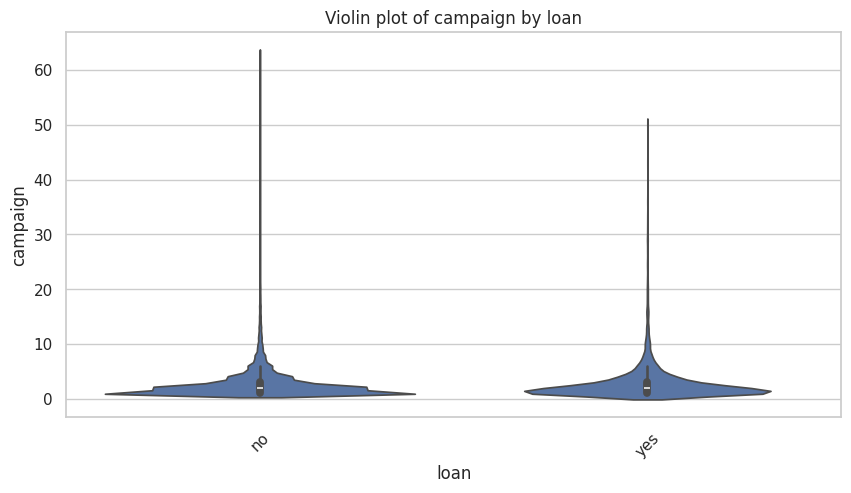


=== Numeric Variable: pdays | Categorical Variable: loan ===

        count       mean         std  min  25%  50%  75%    max
loan                                                           
no    37969.0  41.190761  101.267913 -1.0 -1.0 -1.0 -1.0  871.0
yes    7245.0  34.977088   93.748548 -1.0 -1.0 -1.0 -1.0  808.0


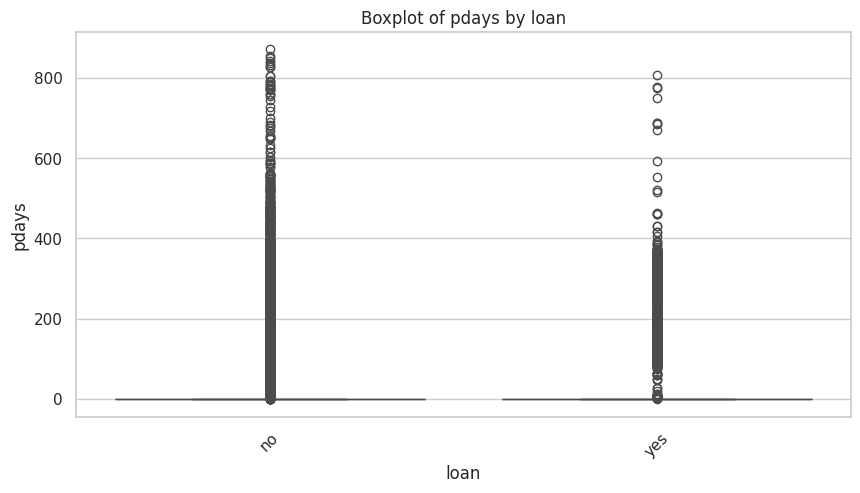

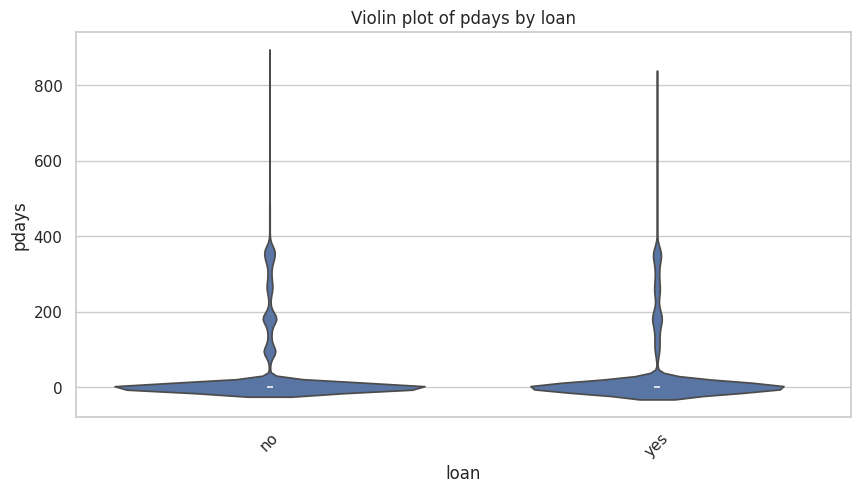


=== Numeric Variable: previous | Categorical Variable: loan ===

        count      mean       std  min  25%  50%  75%    max
loan                                                        
no    37969.0  0.591404  2.348087  0.0  0.0  0.0  0.0  275.0
yes    7245.0  0.522015  2.052316  0.0  0.0  0.0  0.0   58.0


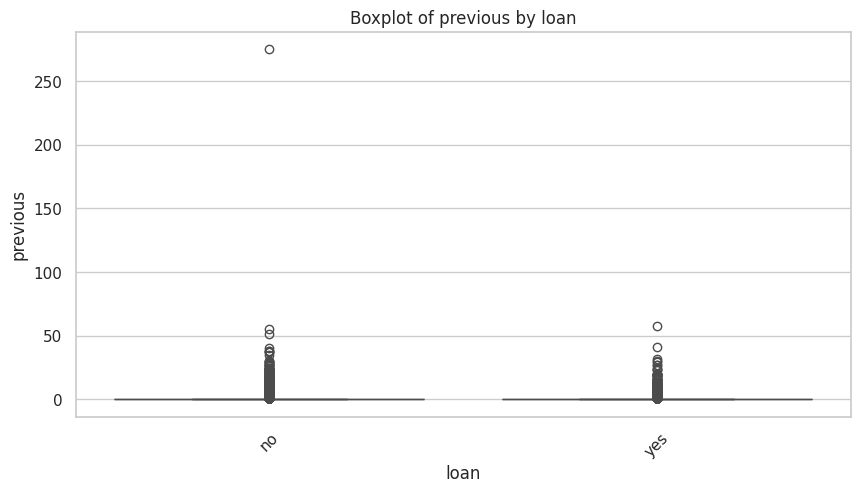

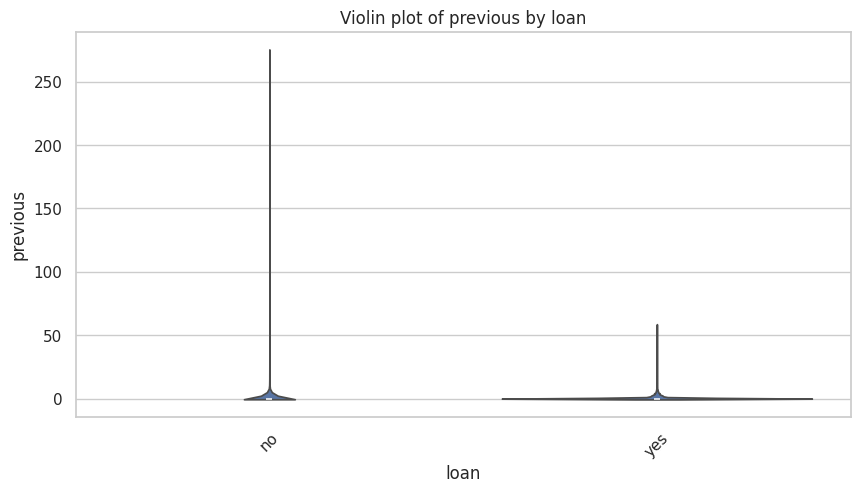


=== Numeric Variable: age | Categorical Variable: contact ===

             count       mean        std   min   25%   50%   75%   max
contact                                                               
cellular   29285.0  40.400785  10.494896  18.0  32.0  38.0  48.0  94.0
telephone   2906.0  47.837922  13.934969  18.0  37.0  47.0  57.0  95.0
unknown    13023.0  40.601244   9.439264  20.0  33.0  39.0  48.0  61.0


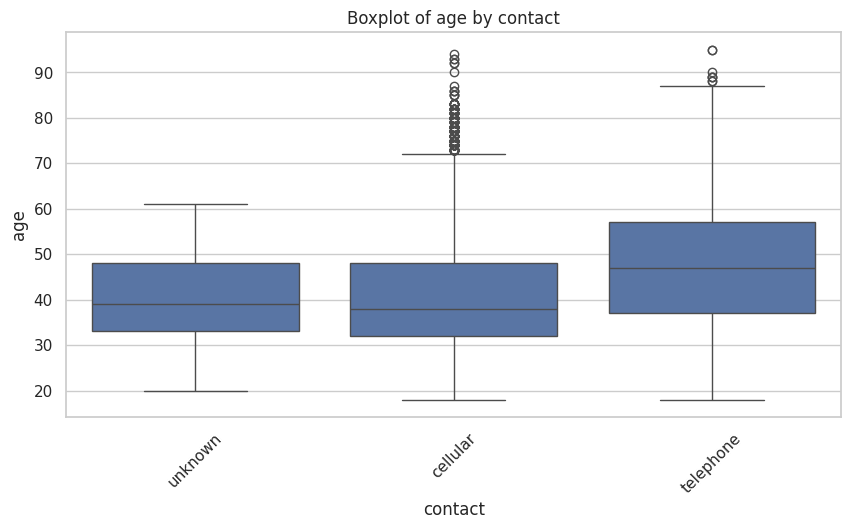

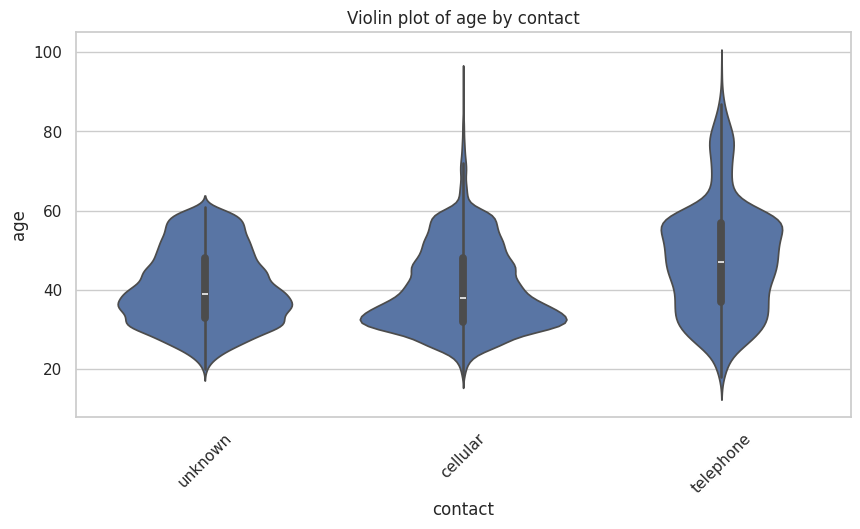


=== Numeric Variable: balance | Categorical Variable: contact ===

             count         mean          std     min    25%    50%     75%  \
contact                                                                      
cellular   29285.0  1397.926993  3057.197381 -8019.0   79.0  463.0  1468.0   
telephone   2906.0  1803.704061  4301.802924 -1965.0  124.0  657.0  1987.0   
unknown    13023.0  1183.502880  2638.378740 -3372.0   50.0  389.0  1255.5   

                max  
contact              
cellular   102127.0  
telephone   98417.0  
unknown     58544.0  


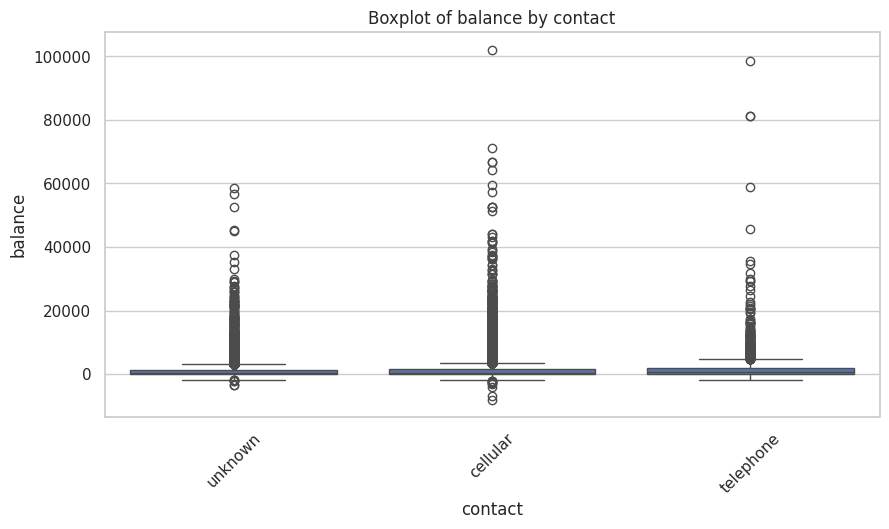

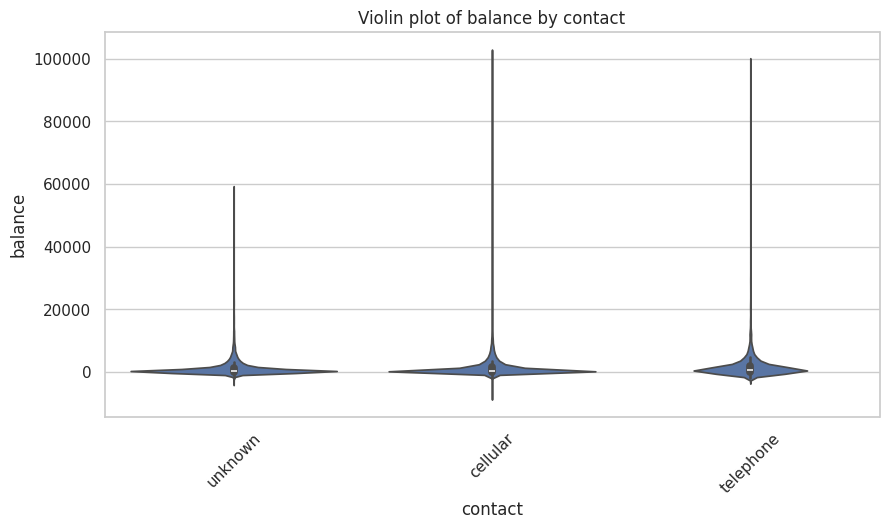


=== Numeric Variable: day | Categorical Variable: contact ===

             count       mean       std  min  25%   50%   75%   max
contact                                                            
cellular   29285.0  15.930306  8.210676  1.0  9.0  16.0  21.0  31.0
telephone   2906.0  16.557467  8.742893  1.0  9.0  17.0  23.0  31.0
unknown    13023.0  15.357982  8.454296  1.0  8.0  15.0  21.0  31.0


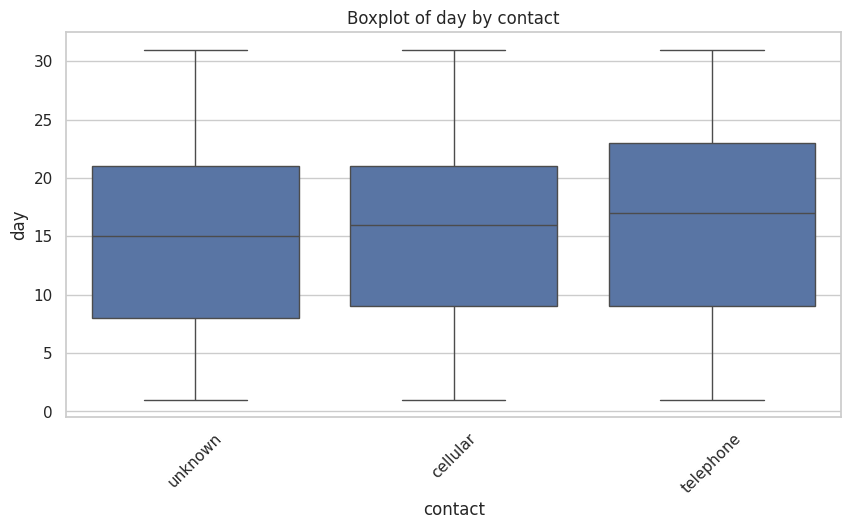

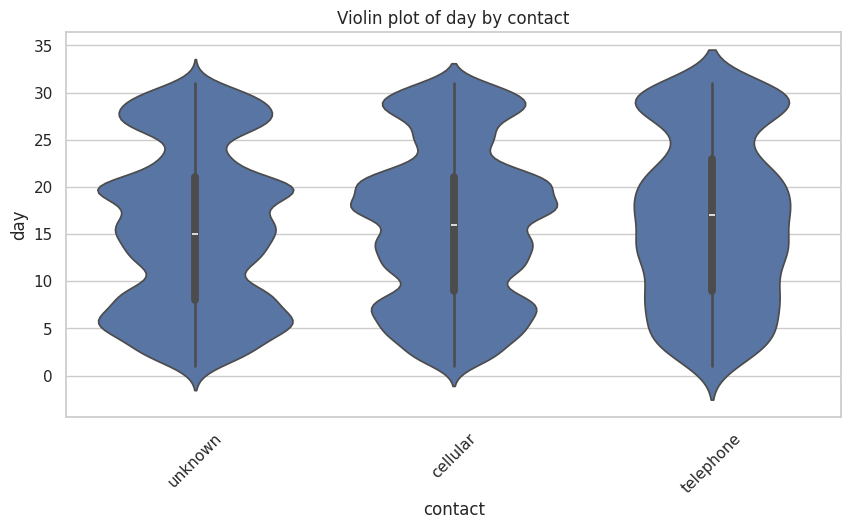


=== Numeric Variable: duration | Categorical Variable: contact ===

             count        mean         std  min    25%    50%    75%     max
contact                                                                     
cellular   29285.0  263.013966  253.501587  0.0  106.0  184.0  326.0  3422.0
telephone   2906.0  235.366139  290.118299  2.0   75.0  155.0  282.0  4918.0
unknown    13019.0  252.303326  258.378679  0.0  101.0  178.0  311.0  3881.0


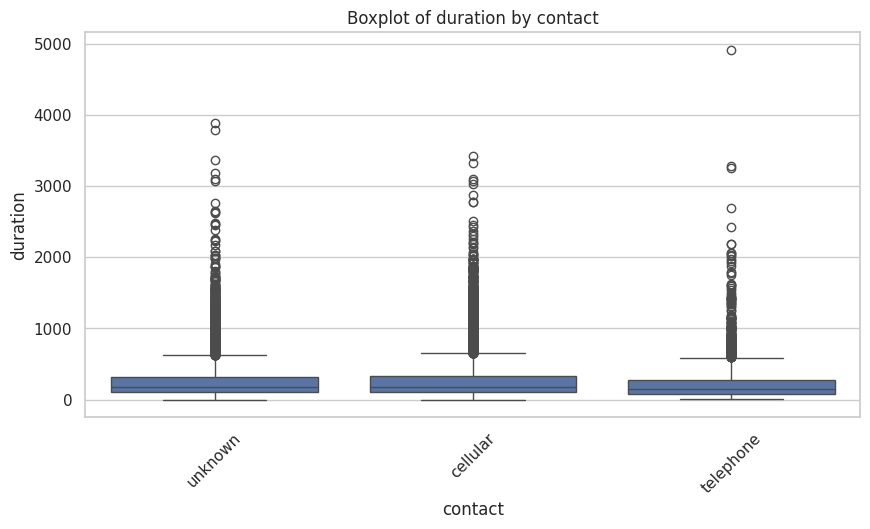

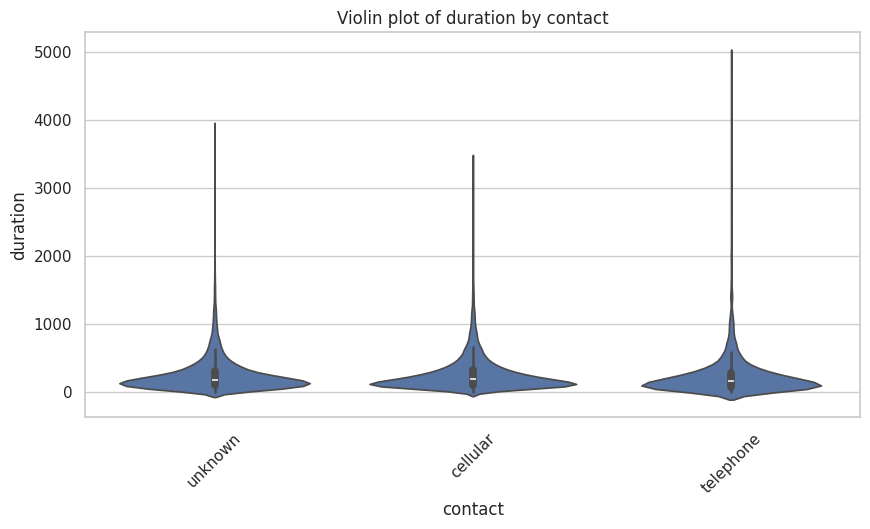


=== Numeric Variable: campaign | Categorical Variable: contact ===

             count      mean       std  min  25%  50%  75%   max
contact                                                         
cellular   29285.0  2.690114  2.900720  1.0  1.0  2.0  3.0  50.0
telephone   2906.0  3.400895  3.623406  1.0  1.0  2.0  4.0  43.0
unknown    13023.0  2.787223  3.371638  1.0  1.0  2.0  3.0  63.0


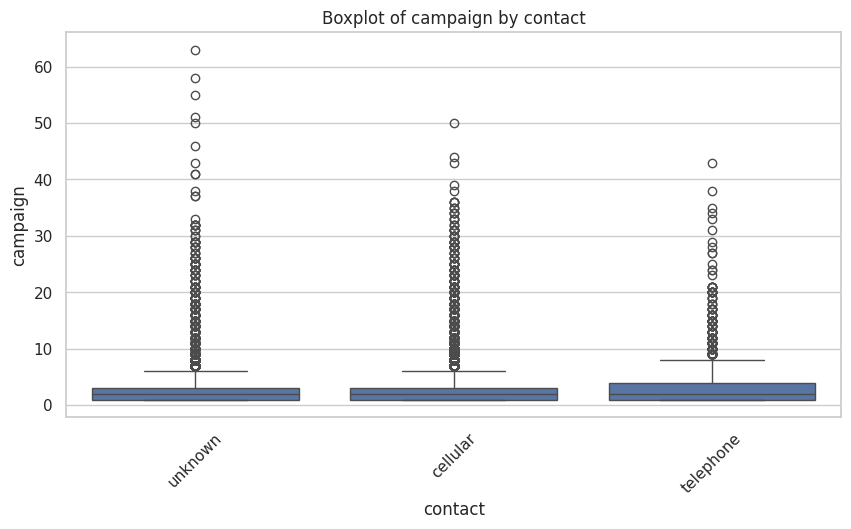

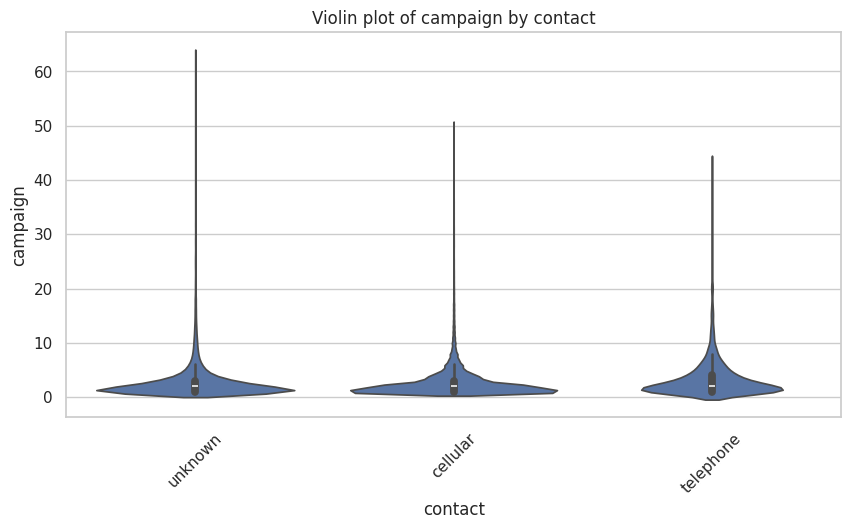


=== Numeric Variable: pdays | Categorical Variable: contact ===

             count       mean         std  min  25%  50%   75%    max
contact                                                              
cellular   29285.0  56.885129  113.379313 -1.0 -1.0 -1.0  51.0  871.0
telephone   2906.0  46.312801  104.231149 -1.0 -1.0 -1.0  -1.0  690.0
unknown    13023.0   1.298856   36.447464 -1.0 -1.0 -1.0  -1.0  850.0


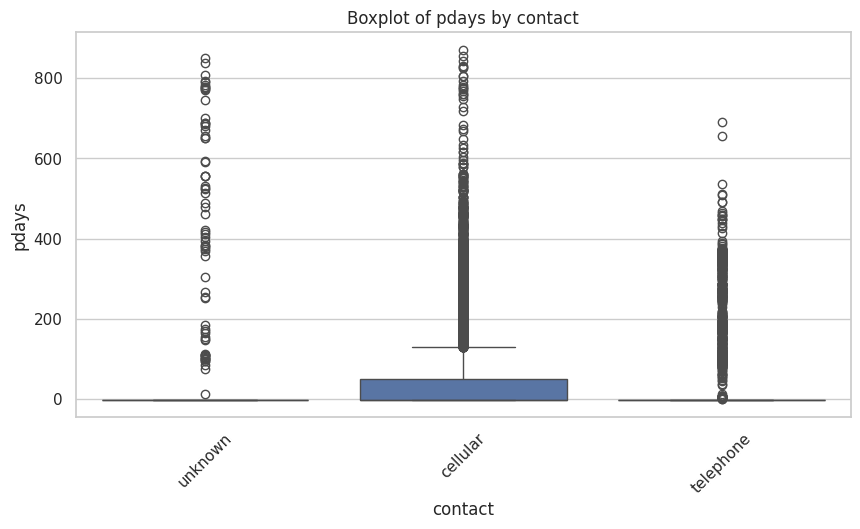

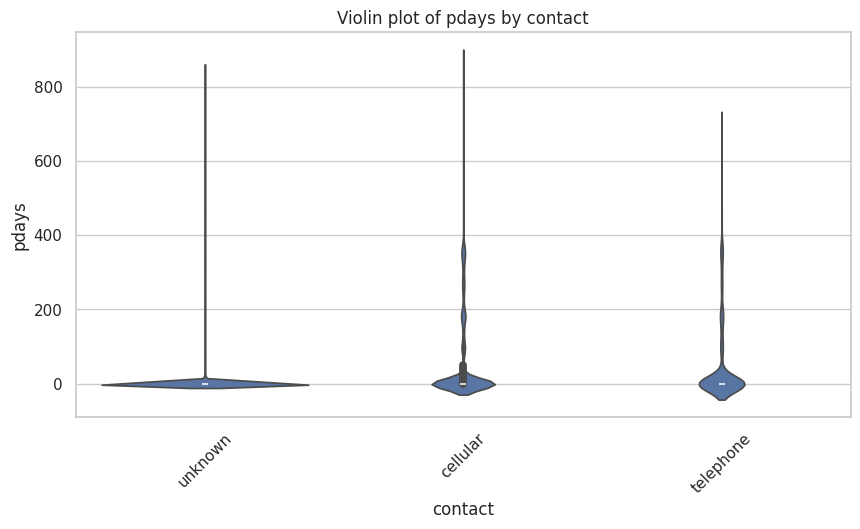


=== Numeric Variable: previous | Categorical Variable: contact ===

             count      mean       std  min  25%  50%  75%    max
contact                                                          
cellular   29285.0  0.804064  2.695072  0.0  0.0  0.0  1.0  275.0
telephone   2906.0  0.827254  2.501998  0.0  0.0  0.0  0.0   37.0
unknown    13023.0  0.021961  0.502468  0.0  0.0  0.0  0.0   41.0


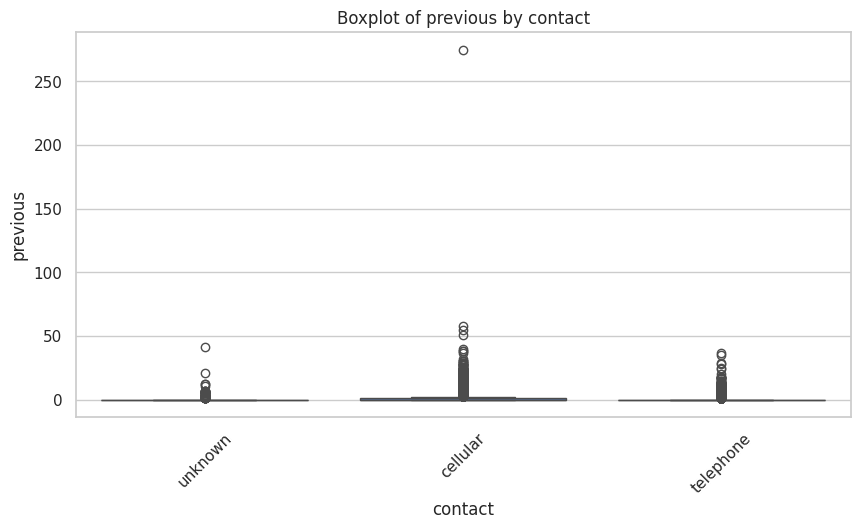

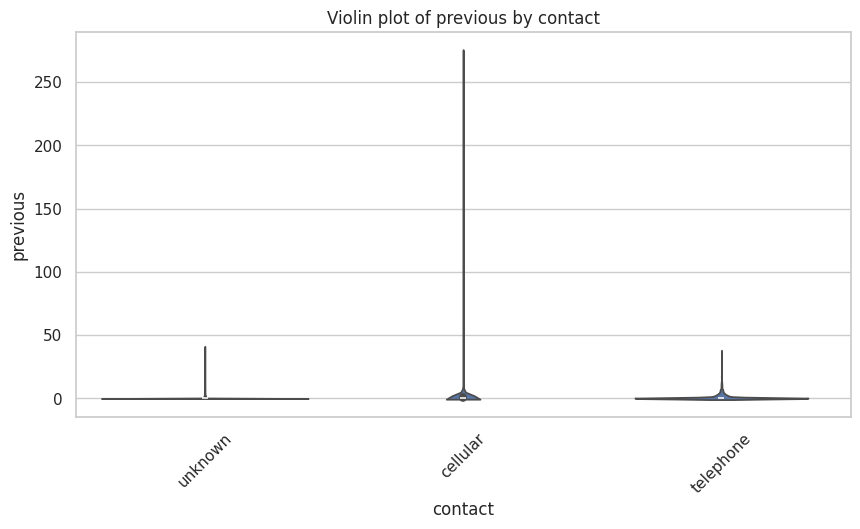


=== Numeric Variable: age | Categorical Variable: month ===

         count       mean        std   min   25%   50%   75%   max
month                                                             
apr     2932.0  39.770805  11.030029  19.0  32.0  37.0  46.0  95.0
aug     6247.0  42.894509  10.540618  18.0  34.0  42.0  51.0  93.0
dec      214.0  44.457944  16.345036  19.0  31.0  40.0  57.0  89.0
feb     2649.0  40.885240  11.722933  18.0  32.0  38.0  48.0  90.0
jan     1403.0  40.493229  11.610988  19.0  31.0  38.0  49.0  92.0
jul     6895.0  41.008847  10.376412  19.0  32.0  40.0  49.0  93.0
jun     5341.0  42.438120   9.904779  19.0  36.0  41.0  50.0  83.0
mar      477.0  42.941300  15.877707  19.0  30.0  38.0  55.0  94.0
may    13769.0  38.892585   9.354408  18.0  32.0  37.0  45.0  84.0
nov     3970.0  42.057935   9.592407  18.0  34.0  40.0  49.0  83.0
oct      738.0  45.891599  16.020142  19.0  33.0  43.0  58.0  95.0
sep      579.0  43.958549  16.722082  18.0  31.0  39.0  56.0  89.0


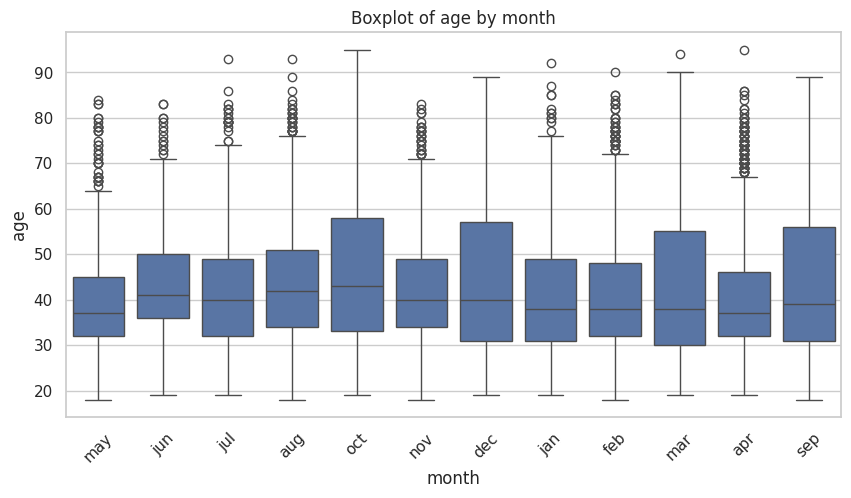

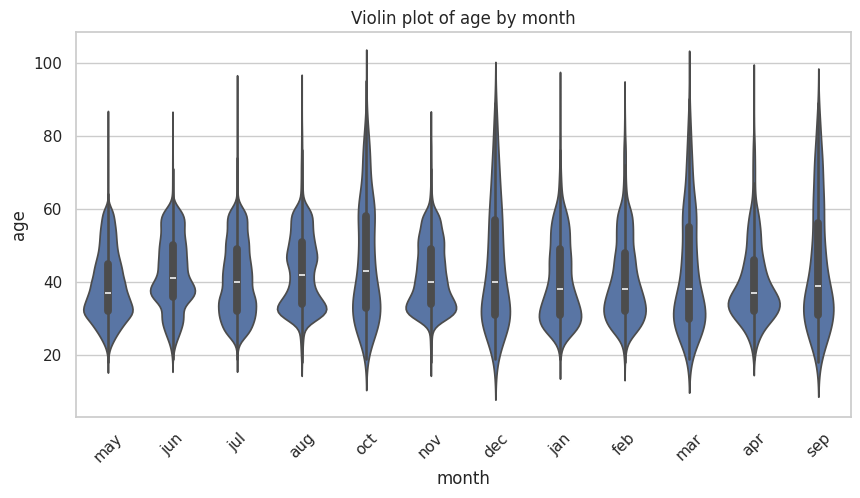


=== Numeric Variable: balance | Categorical Variable: month ===

         count         mean          std     min     25%     50%      75%  \
month                                                                       
apr     2932.0  1542.551160  3086.574937 -3058.0  214.00   642.5  1717.50   
aug     6247.0  1427.701777  3349.379759 -1980.0   60.00   418.0  1437.50   
dec      214.0  2315.672897  6131.746436   -46.0  320.75   909.5  2341.75   
feb     2649.0  1319.098905  2925.506977 -1455.0  147.00   503.0  1272.00   
jan     1403.0   946.783321  1712.879295 -1161.0  127.00   433.0  1095.50   
jul     6895.0   900.025526  2268.594561 -8019.0    2.50   244.0   973.00   
jun     5341.0  1608.222243  3283.817180 -1968.0  120.00   625.0  1823.00   
mar      477.0  2046.228512  3130.538337  -675.0  293.00   997.0  2667.00   
may    13769.0  1034.980028  2403.456785 -4057.0   47.00   337.0  1061.00   
nov     3970.0  2512.932997  4355.453937 -2604.0  204.00  1056.5  3116.50   
oct      7

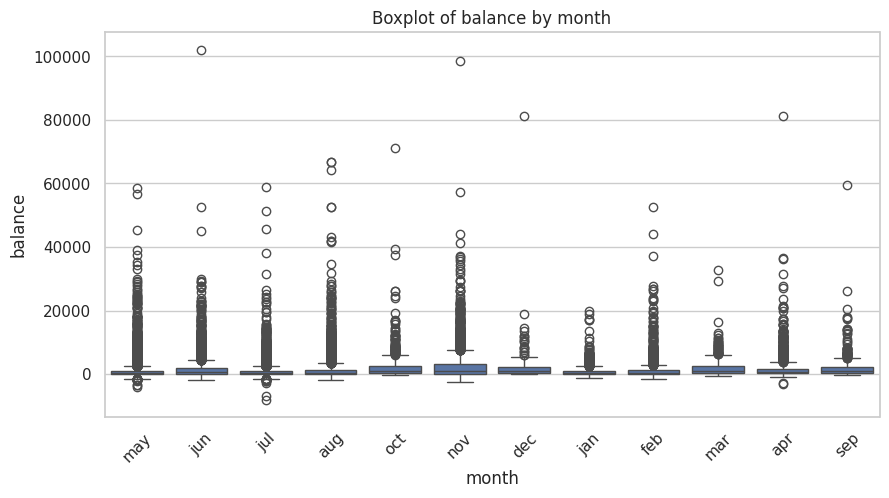

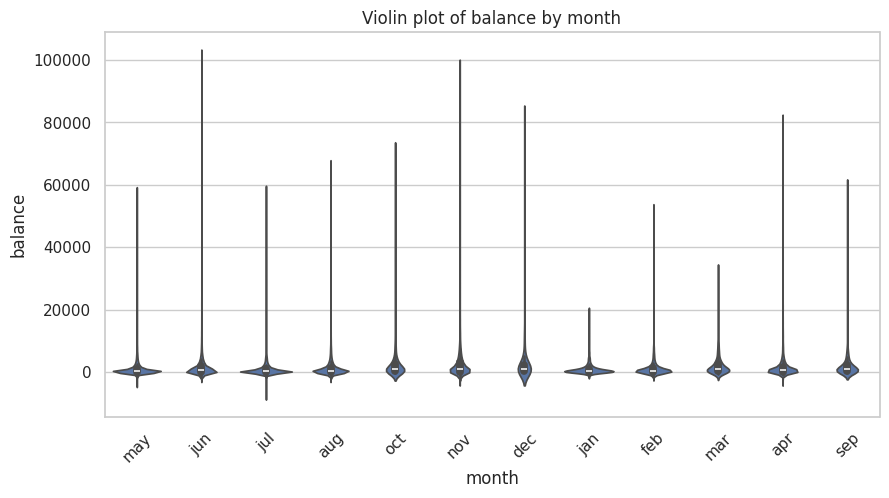


=== Numeric Variable: day | Categorical Variable: month ===

         count       mean       std  min   25%   50%   75%   max
month                                                           
apr     2932.0  17.317190  7.145106  1.0  15.0  17.0  20.0  30.0
aug     6247.0  16.432688  7.963086  1.0  10.0  17.0  22.0  31.0
dec      214.0  14.434579  8.710413  2.0   7.0  14.0  21.0  31.0
feb     2649.0   6.354851  5.724887  1.0   3.0   4.0   6.0  27.0
jan     1403.0  27.456878  4.441098  6.0  28.0  29.0  29.0  30.0
jul     6895.0  18.694271  8.703156  1.0  10.0  19.0  28.0  31.0
jun     5341.0  11.399551  7.575109  1.0   4.0  11.0  18.0  30.0
mar      477.0  14.134172  9.400229  1.0   5.0  12.0  23.0  31.0
may    13769.0  15.489070  7.666004  4.0   8.0  14.0  21.0  31.0
nov     3970.0  18.383627  3.446921  2.0  18.0  19.0  20.0  30.0
oct      738.0  17.777778  8.173123  1.0  12.0  19.0  25.0  31.0
sep      579.0  11.868739  8.365362  1.0   6.0   9.0  16.5  30.0


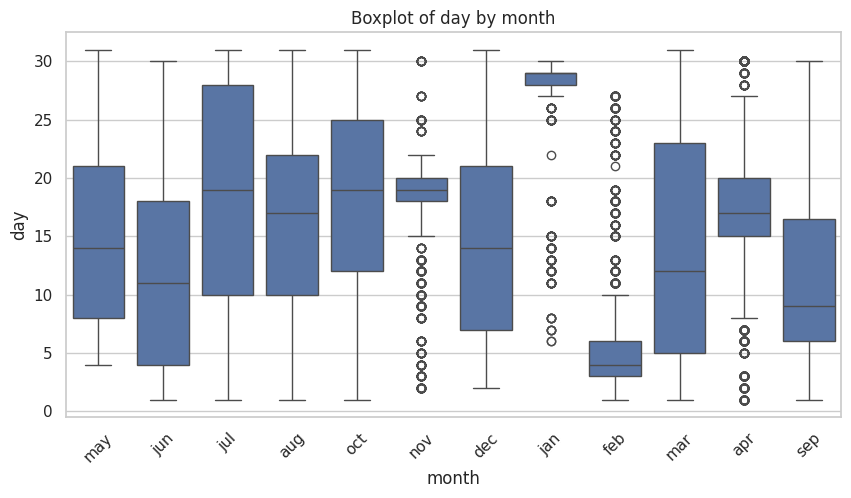

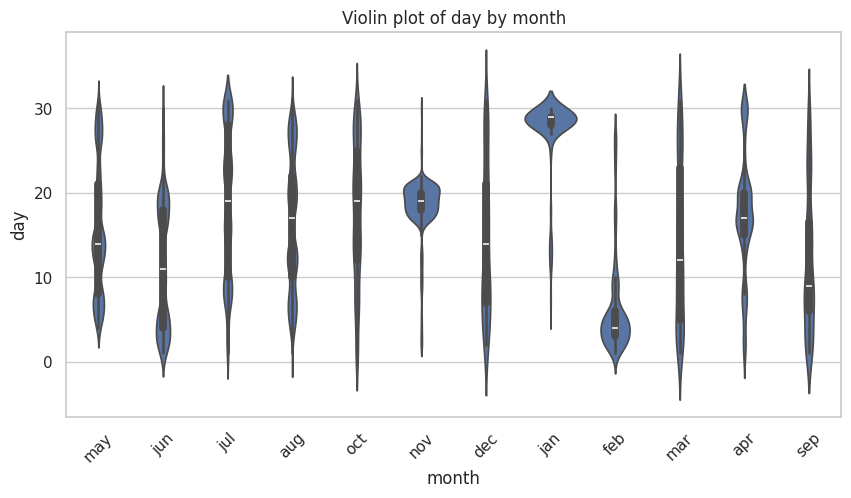


=== Numeric Variable: duration | Categorical Variable: month ===

         count        mean         std   min     25%    50%     75%     max
month                                                                      
apr     2932.0  298.098909  261.783182   1.0  124.00  224.0  383.00  2870.0
aug     6247.0  232.402113  241.884535   0.0   96.00  156.0  274.00  3785.0
dec      214.0  329.327103  283.420349   6.0  154.25  267.0  399.00  2062.0
feb     2649.0  248.298226  259.596924   2.0  100.00  171.0  300.00  3102.0
jan     1403.0  268.220242  263.481623   7.0  114.00  194.0  333.50  3025.0
jul     6895.0  267.975344  266.282837   4.0  101.00  180.0  333.00  2692.0
jun     5341.0  243.087811  264.031740   4.0   89.00  164.0  301.00  3881.0
mar      477.0  244.400419  238.336102  10.0  116.00  187.0  283.00  3076.0
may    13765.0  260.887759  246.691086   0.0  110.00  190.0  323.00  3366.0
nov     3970.0  253.148615  269.813124   2.0   95.00  168.0  303.00  4918.0
oct      738.0  288.3

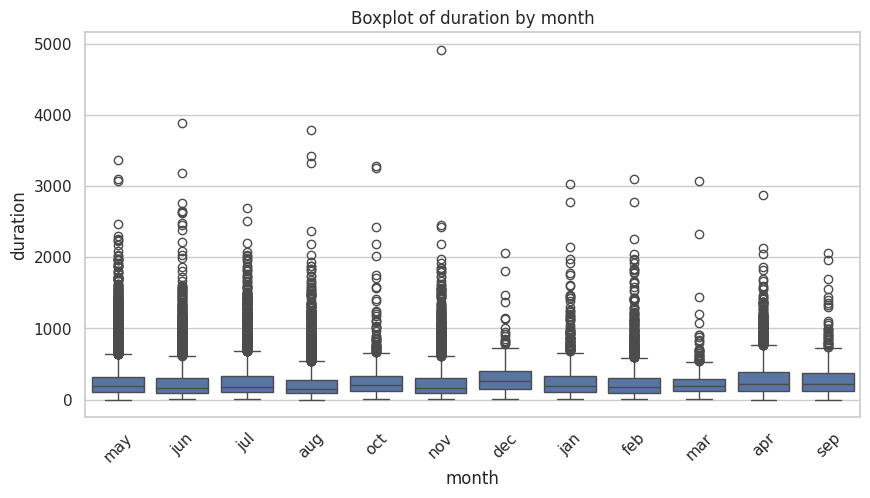

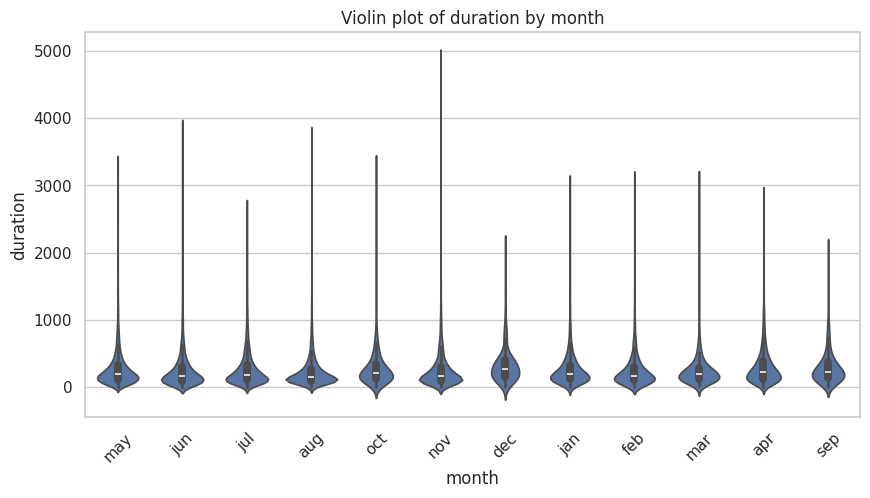


=== Numeric Variable: campaign | Categorical Variable: month ===

         count      mean       std  min  25%  50%  75%   max
month                                                       
apr     2932.0  1.955321  1.474582  1.0  1.0  1.5  2.0  23.0
aug     6247.0  3.927325  3.762757  1.0  2.0  3.0  4.0  38.0
dec      214.0  2.196262  1.612389  1.0  1.0  2.0  3.0  10.0
feb     2649.0  2.382031  2.031417  1.0  1.0  2.0  3.0  21.0
jan     1403.0  1.672131  0.974416  1.0  1.0  1.0  2.0  11.0
jul     6895.0  3.524438  4.268947  1.0  1.0  2.0  4.0  50.0
jun     5341.0  3.135368  3.912362  1.0  1.0  2.0  3.0  58.0
mar      477.0  2.205451  2.083280  1.0  1.0  2.0  2.0  19.0
may    13769.0  2.447382  2.474685  1.0  1.0  2.0  3.0  63.0
nov     3970.0  1.918136  1.387087  1.0  1.0  1.0  2.0  13.0
oct      738.0  1.536585  0.897390  1.0  1.0  1.0  2.0   7.0
sep      579.0  1.765112  1.337544  1.0  1.0  1.0  2.0  13.0


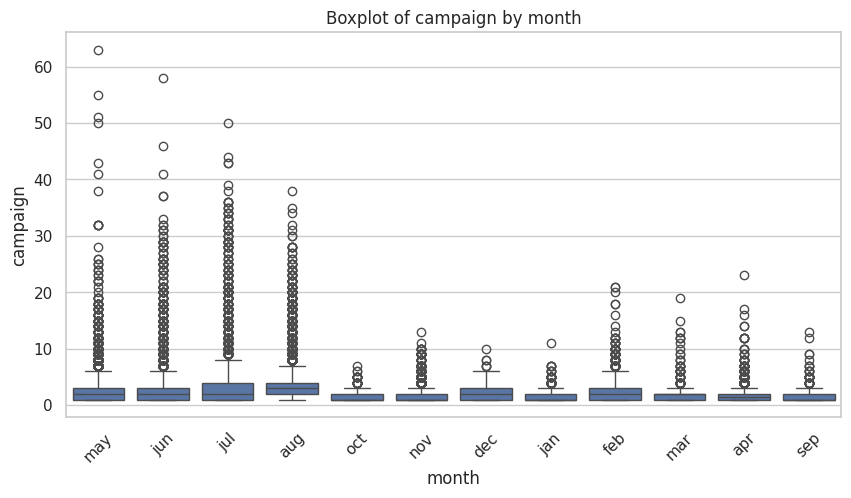

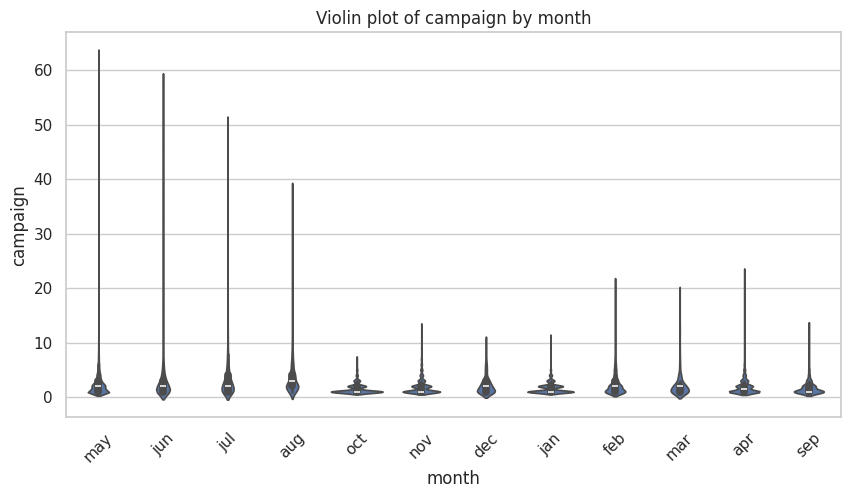


=== Numeric Variable: pdays | Categorical Variable: month ===

         count        mean         std  min  25%    50%     75%    max
month                                                                 
apr     2932.0   95.201910  136.055155 -1.0 -1.0   -1.0  187.00  648.0
aug     6247.0   13.328958   60.963033 -1.0 -1.0   -1.0   -1.00  828.0
dec      214.0  108.780374  108.294822 -1.0 -1.0  125.0  195.00  536.0
feb     2649.0   68.702907  107.747648 -1.0 -1.0   -1.0  182.00  616.0
jan     1403.0   67.898076  105.150685 -1.0 -1.0   -1.0  182.00  555.0
jul     6895.0    8.032342   54.460539 -1.0 -1.0   -1.0   -1.00  792.0
jun     5341.0    9.154465   51.714202 -1.0 -1.0   -1.0   -1.00  756.0
mar      477.0   71.228512  115.040202 -1.0 -1.0   -1.0  130.00  667.0
may    13769.0   52.145762  119.671920 -1.0 -1.0   -1.0   -1.00  670.0
nov     3970.0   42.744836   75.110106 -1.0 -1.0   -1.0   96.75  871.0
oct      738.0   84.357724  130.444088 -1.0 -1.0   -1.0  144.00  826.0
sep      579.

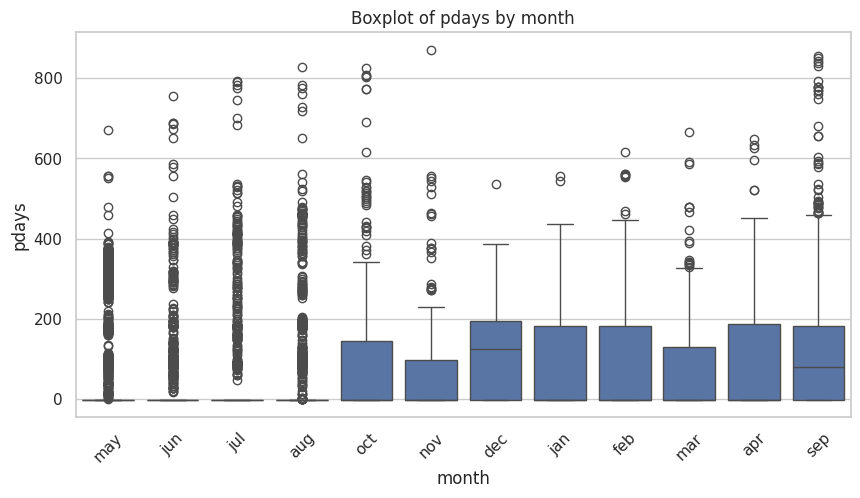

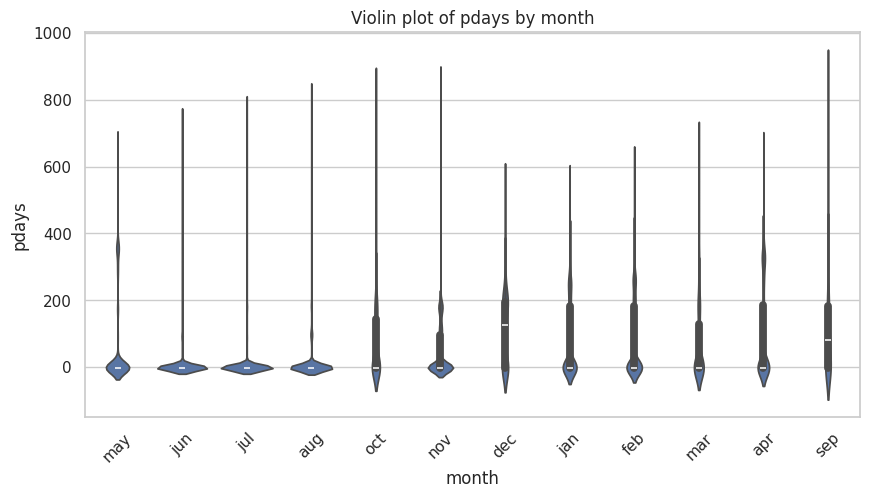


=== Numeric Variable: previous | Categorical Variable: month ===

         count      mean       std  min  25%  50%  75%    max
month                                                        
apr     2932.0  1.052524  2.194089  0.0  0.0  0.0  1.0   25.0
aug     6247.0  0.278374  1.330142  0.0  0.0  0.0  0.0   35.0
dec      214.0  1.803738  3.591694  0.0  0.0  1.0  2.0   37.0
feb     2649.0  1.182710  5.838122  0.0  0.0  0.0  1.0  275.0
jan     1403.0  1.185317  3.212828  0.0  0.0  0.0  1.0   51.0
jul     6895.0  0.129949  1.070584  0.0  0.0  0.0  0.0   55.0
jun     5341.0  0.197903  1.169671  0.0  0.0  0.0  0.0   30.0
mar      477.0  1.188679  2.424065  0.0  0.0  0.0  2.0   28.0
may    13769.0  0.584865  1.968540  0.0  0.0  0.0  0.0   58.0
nov     3970.0  0.861461  2.109368  0.0  0.0  0.0  1.0   37.0
oct      738.0  1.544715  2.686977  0.0  0.0  0.0  2.0   20.0
sep      579.0  1.894646  3.093294  0.0  0.0  1.0  3.0   41.0


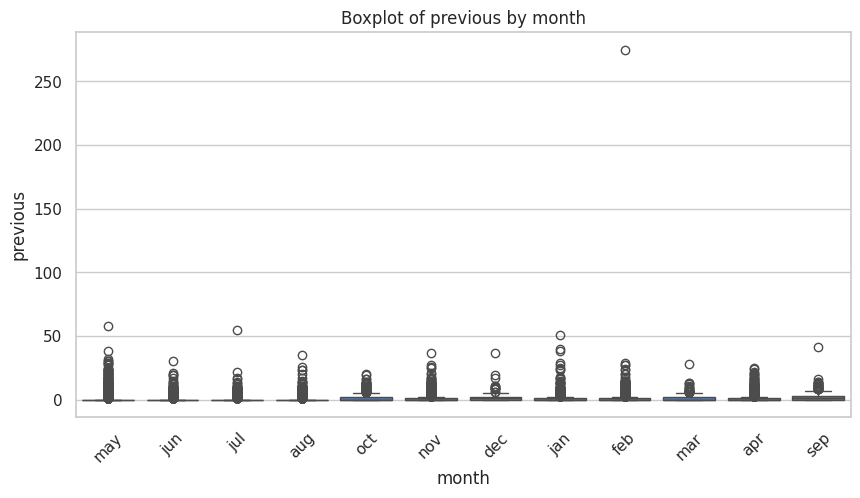

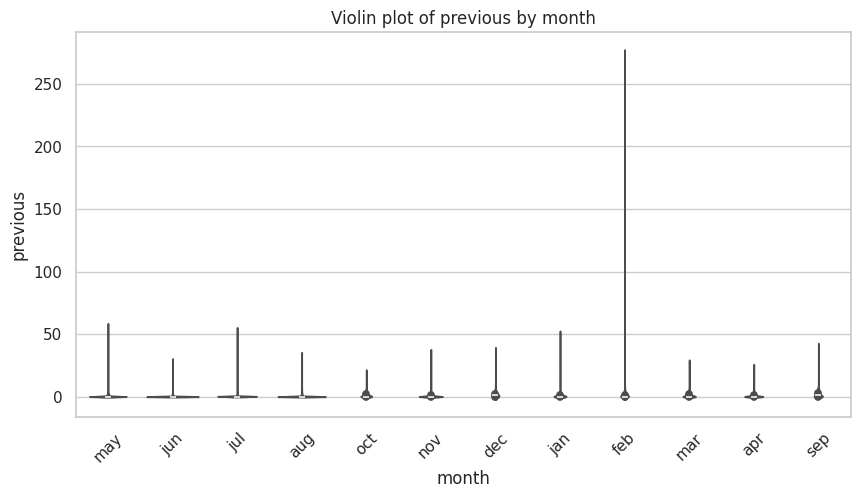


=== Numeric Variable: age | Categorical Variable: poutcome ===

            count       mean        std   min   25%   50%   75%   max
poutcome                                                             
failure    4901.0  40.786166  10.429079  19.0  33.0  38.0  47.0  88.0
other      1840.0  39.752174  11.091370  18.0  32.0  37.0  46.0  89.0
success    1511.0  42.964924  14.301418  18.0  32.0  39.0  53.0  93.0
unknown   36962.0  40.932498  10.430428  18.0  33.0  39.0  49.0  95.0


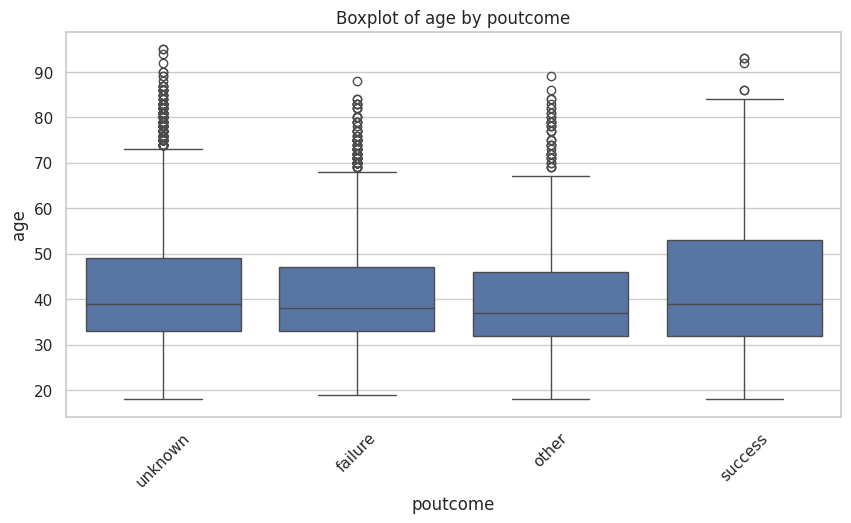

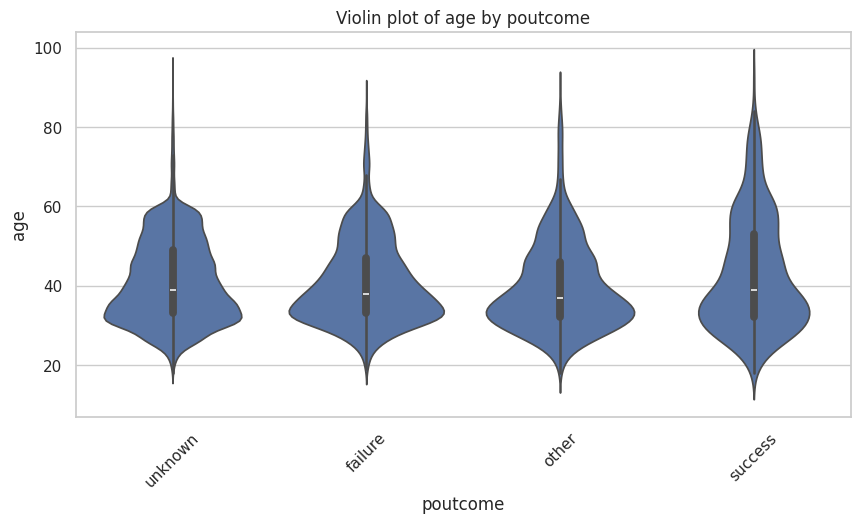


=== Numeric Variable: balance | Categorical Variable: poutcome ===

            count         mean          std     min     25%    50%     75%  \
poutcome                                                                     
failure    4901.0  1465.805550  2688.830172 -1884.0  142.00  549.0  1625.0   
other      1840.0  1487.411413  3352.315711 -1882.0  140.75  570.0  1549.5   
success    1511.0  1939.301125  3725.976363  -405.0  294.00  920.0  2316.5   
unknown   36962.0  1318.694335  3039.275113 -8019.0   55.00  414.0  1358.0   

               max  
poutcome            
failure    37378.0  
other      81204.0  
success    81204.0  
unknown   102127.0  


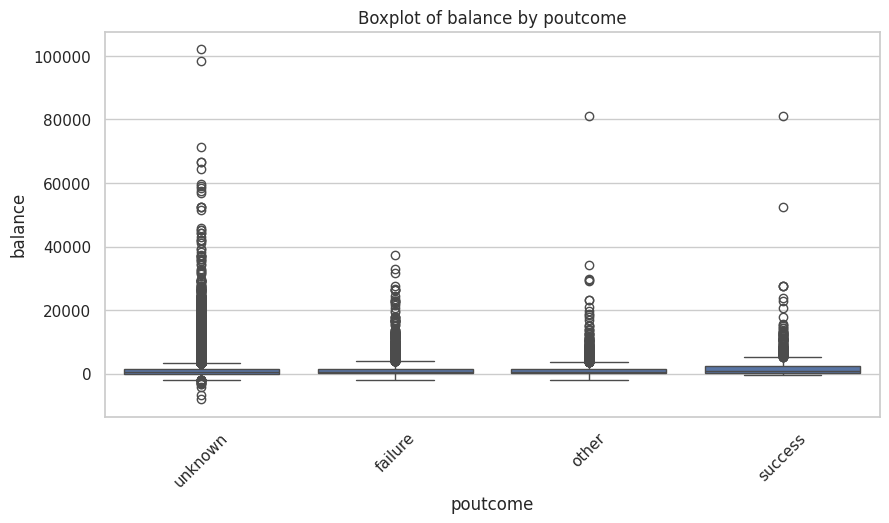

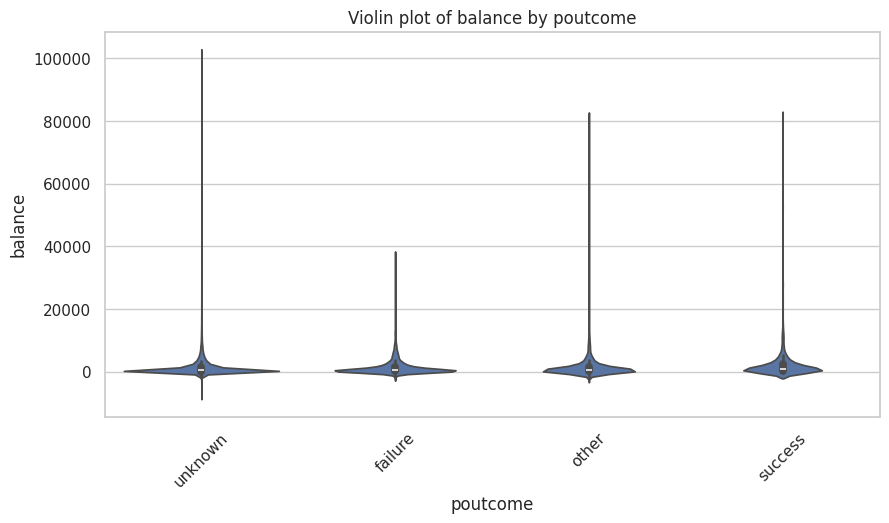


=== Numeric Variable: day | Categorical Variable: poutcome ===

            count       mean       std  min  25%   50%   75%   max
poutcome                                                          
failure    4901.0  14.166701  7.662562  1.0  7.0  14.0  19.0  31.0
other      1840.0  14.475000  8.173514  1.0  7.0  14.0  20.0  31.0
success    1511.0  14.449371  8.403952  1.0  8.0  13.0  21.0  31.0
unknown   36962.0  16.144797  8.372689  1.0  9.0  17.0  22.0  31.0


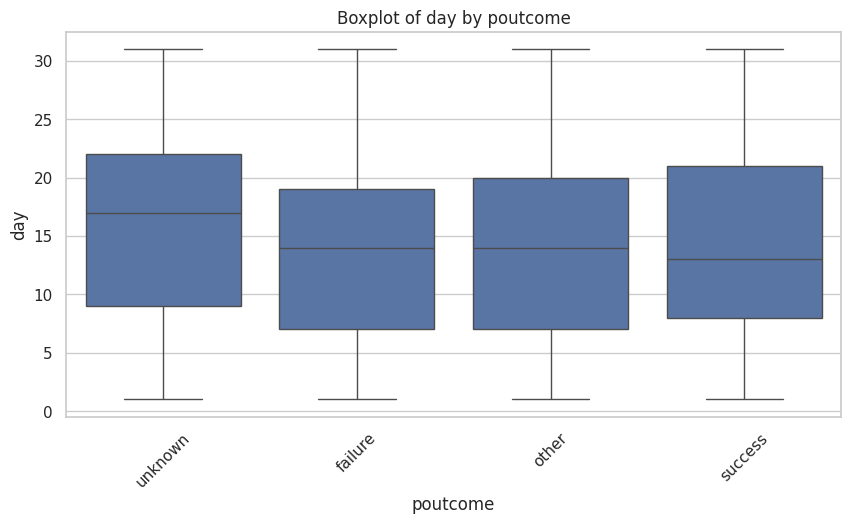

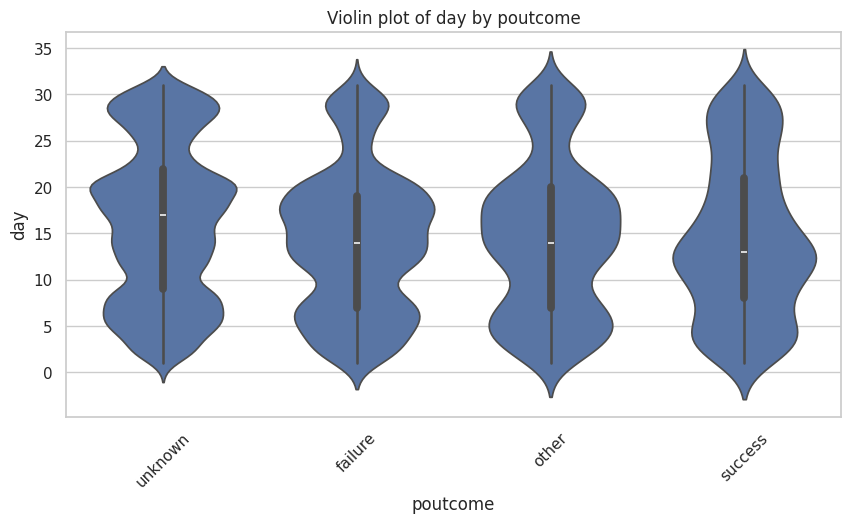


=== Numeric Variable: duration | Categorical Variable: poutcome ===

            count        mean         std  min    25%    50%    75%     max
poutcome                                                                   
failure    4901.0  244.185880  227.130245  5.0  105.0  177.0  300.0  2219.0
other      1840.0  255.715217  247.410369  4.0   99.0  182.5  329.5  2053.0
success    1511.0  316.868961  236.863512  1.0  166.0  253.0  388.5  2062.0
unknown   36958.0  257.725391  262.257228  0.0  101.0  177.0  318.0  4918.0


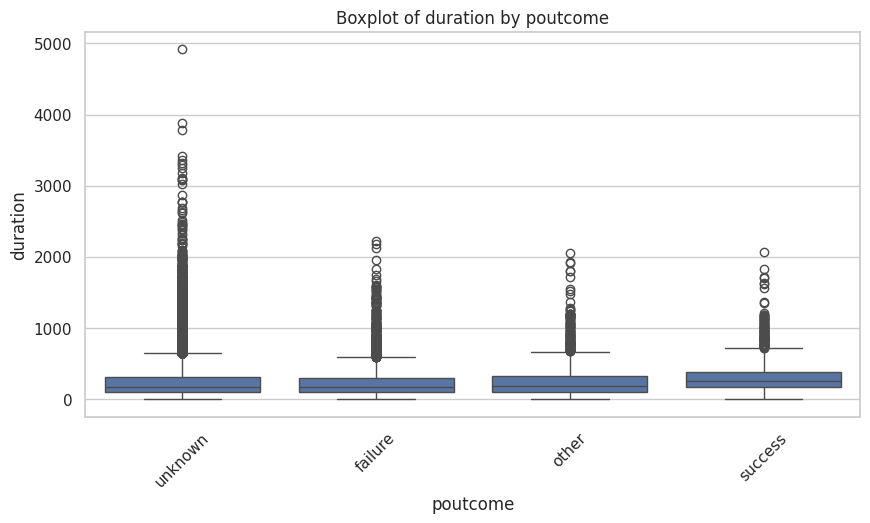

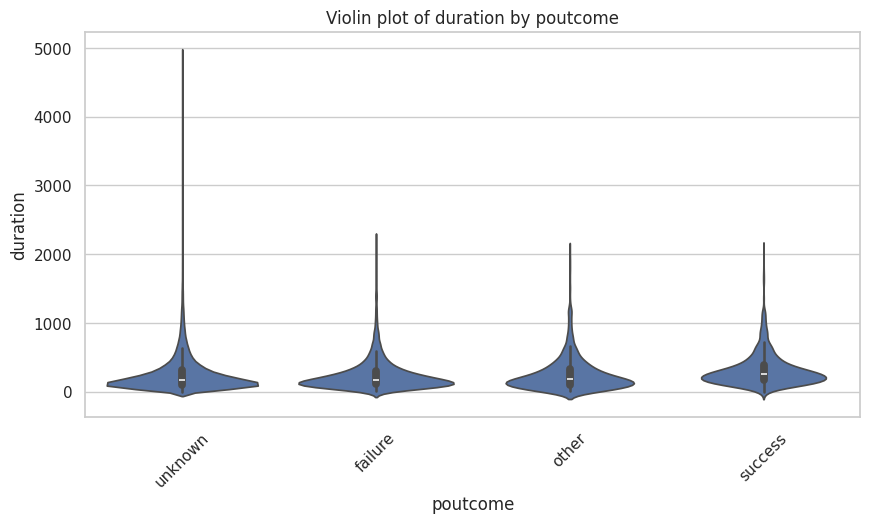


=== Numeric Variable: campaign | Categorical Variable: poutcome ===

            count      mean       std  min  25%  50%  75%   max
poutcome                                                       
failure    4901.0  1.980820  1.470818  1.0  1.0  1.0  2.0  15.0
other      1840.0  2.461413  1.902641  1.0  1.0  2.0  3.0  16.0
success    1511.0  1.806089  1.269141  1.0  1.0  1.0  2.0  11.0
unknown   36962.0  2.921785  3.325496  1.0  1.0  2.0  3.0  63.0


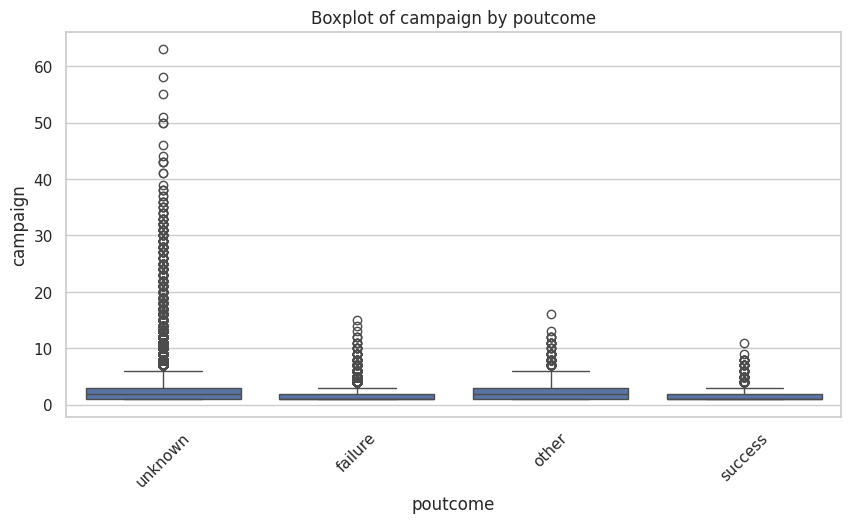

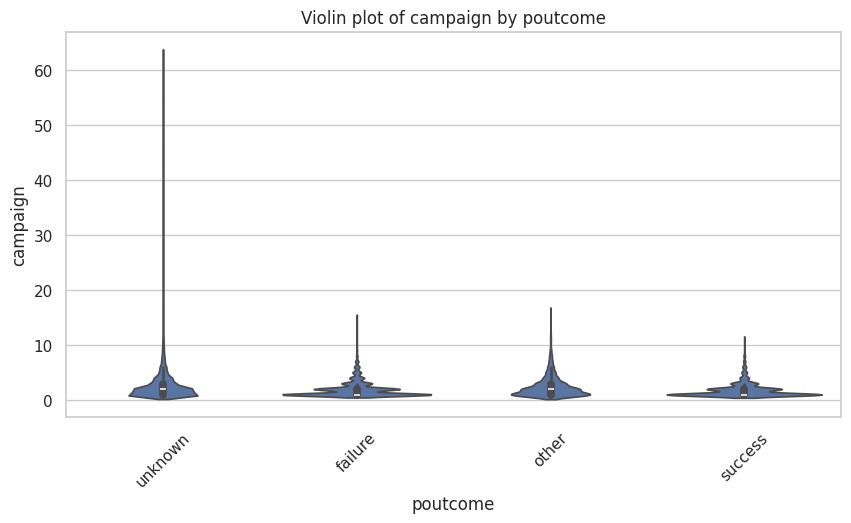


=== Numeric Variable: pdays | Categorical Variable: poutcome ===

            count        mean         std  min    25%    50%    75%    max
poutcome                                                                  
failure    4901.0  241.509284  111.727351  1.0  164.0  245.0  339.0  871.0
other      1840.0  229.683696  122.727765  1.0  139.0  225.0  335.0  838.0
success    1511.0  163.259431   95.218252  1.0   92.0  165.0  187.0  771.0
unknown   36962.0   -0.962042    3.778734 -1.0   -1.0   -1.0   -1.0  528.0


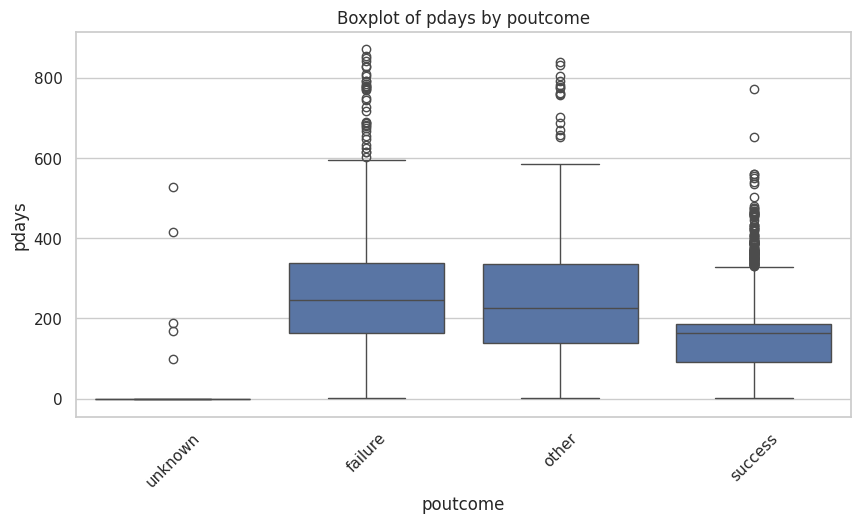

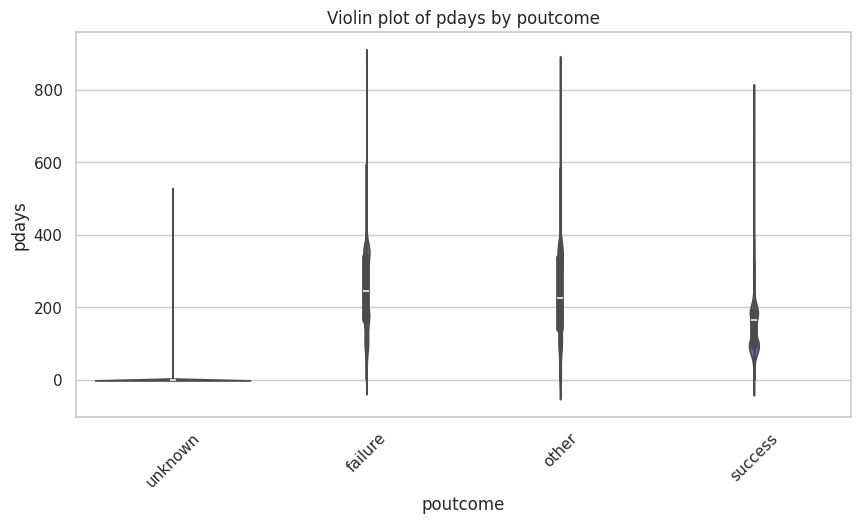


=== Numeric Variable: previous | Categorical Variable: poutcome ===

            count      mean       std  min  25%  50%  75%    max
poutcome                                                        
failure    4901.0  2.896552  3.130252  1.0  1.0  2.0  3.0   55.0
other      1840.0  4.009239  7.799166  1.0  1.0  2.0  4.0  275.0
success    1511.0  3.075447  2.593854  1.0  1.0  2.0  4.0   28.0
unknown   36962.0  0.000460  0.047386  0.0  0.0  0.0  0.0    7.0


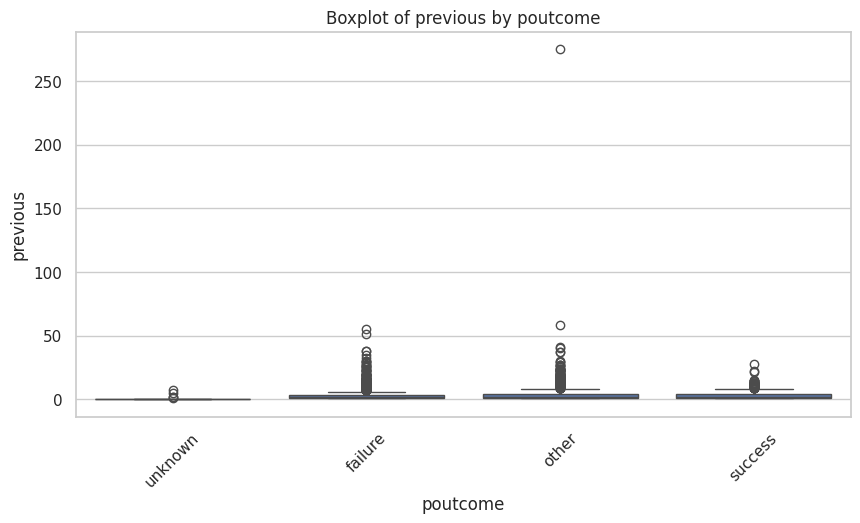

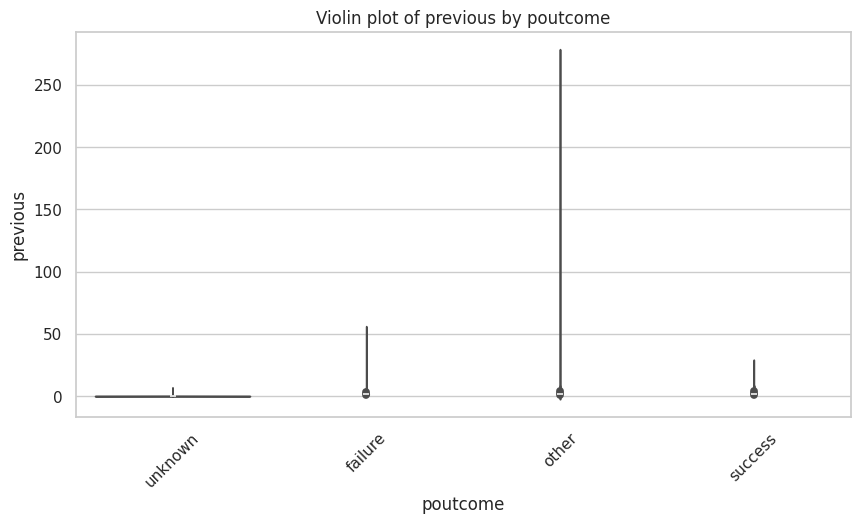


=== Numeric Variable: age | Categorical Variable: y ===

       count       mean        std   min   25%   50%   75%   max
y                                                               
no   39925.0  40.839349  10.172613  18.0  33.0  39.0  48.0  95.0
yes   5289.0  41.670070  13.497781  18.0  31.0  38.0  50.0  95.0


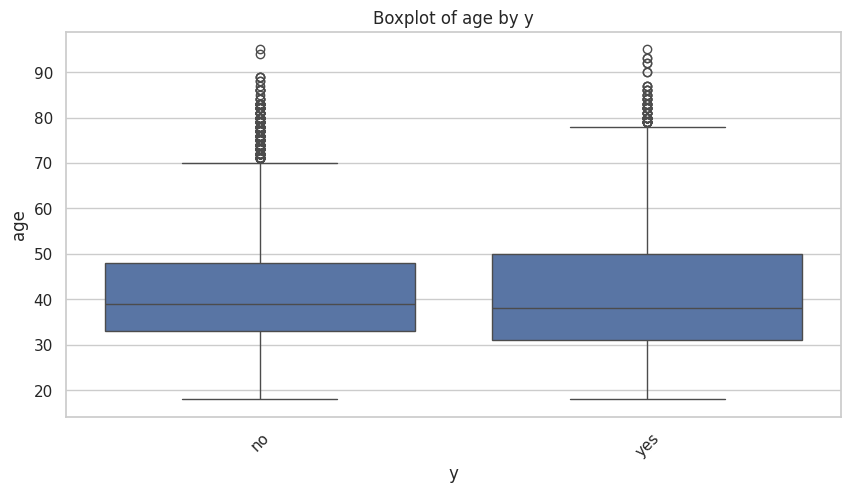

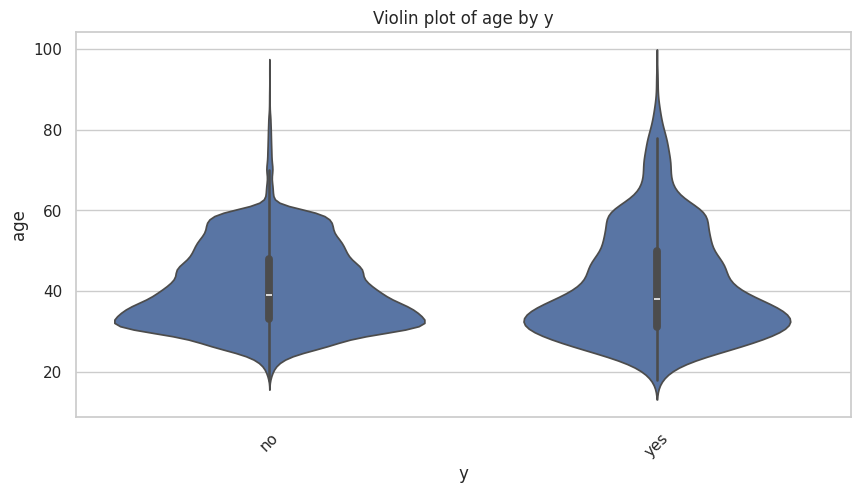


=== Numeric Variable: balance | Categorical Variable: y ===

       count         mean          std     min    25%    50%     75%       max
y                                                                             
no   39925.0  1303.690445  2974.094666 -8019.0   58.0  417.0  1345.0  102127.0
yes   5289.0  1804.267915  3501.104777 -3058.0  210.0  733.0  2159.0   81204.0


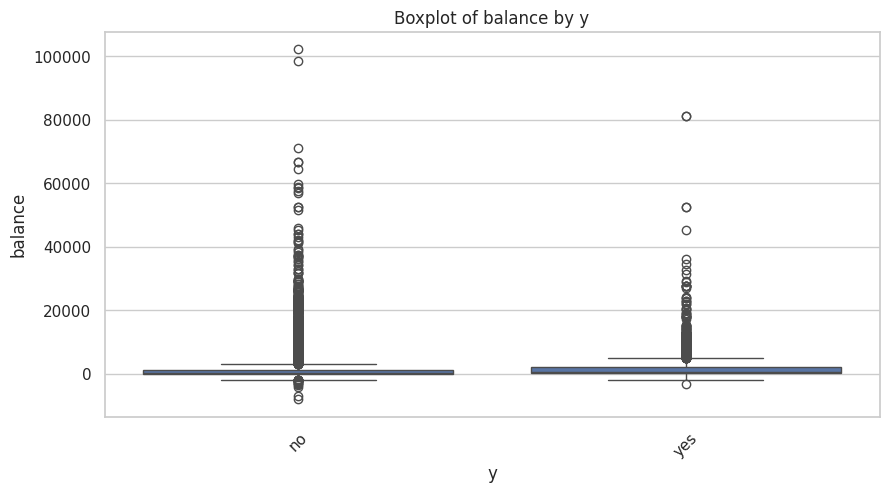

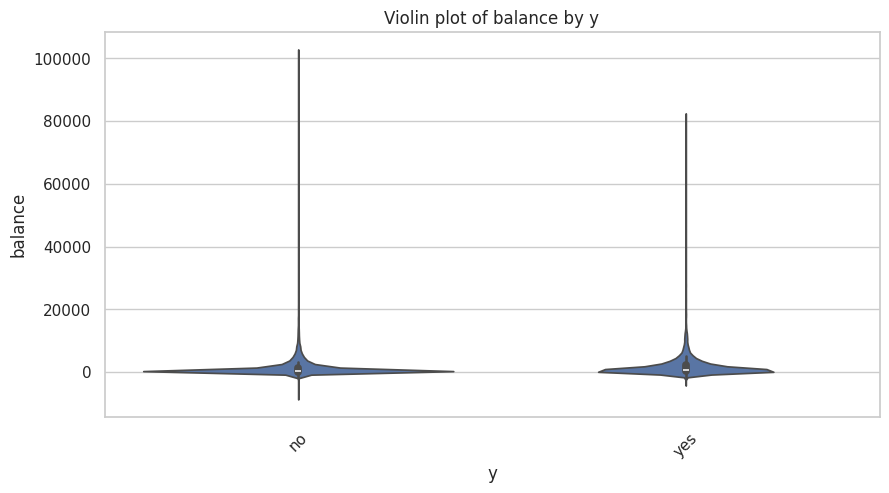


=== Numeric Variable: day | Categorical Variable: y ===

       count       mean       std  min  25%   50%   75%   max
y                                                            
no   39925.0  15.891547  8.294859  1.0  8.0  16.0  21.0  31.0
yes   5289.0  15.158253  8.501875  1.0  8.0  15.0  22.0  31.0


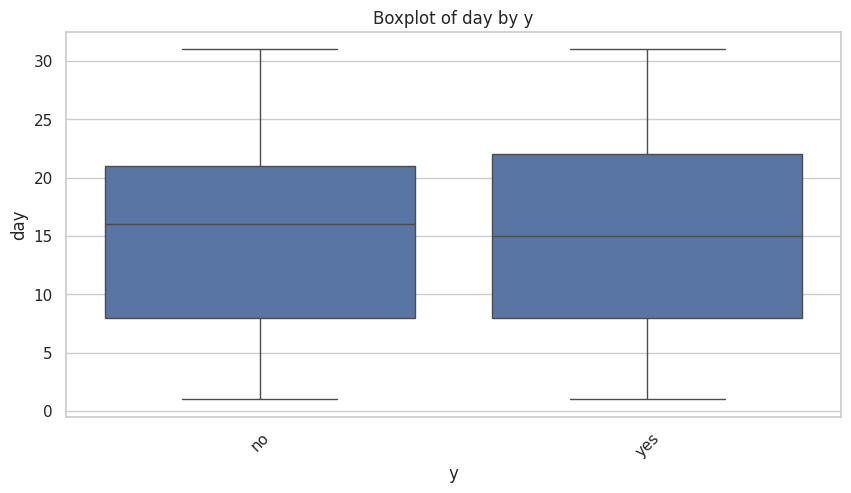

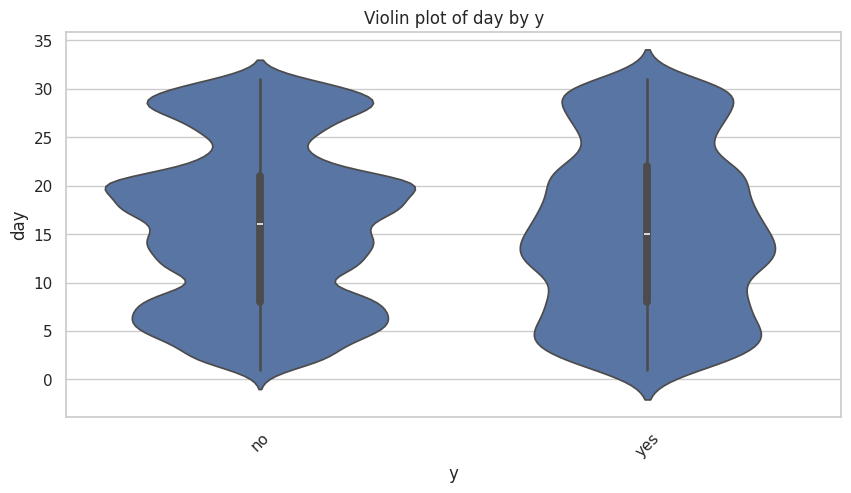


=== Numeric Variable: duration | Categorical Variable: y ===

       count        mean         std  min    25%    50%    75%     max
y                                                                     
no   39921.0  221.169911  207.369008  0.0   95.0  164.0  279.0  4918.0
yes   5289.0  537.294574  392.525262  8.0  244.0  426.0  725.0  3881.0


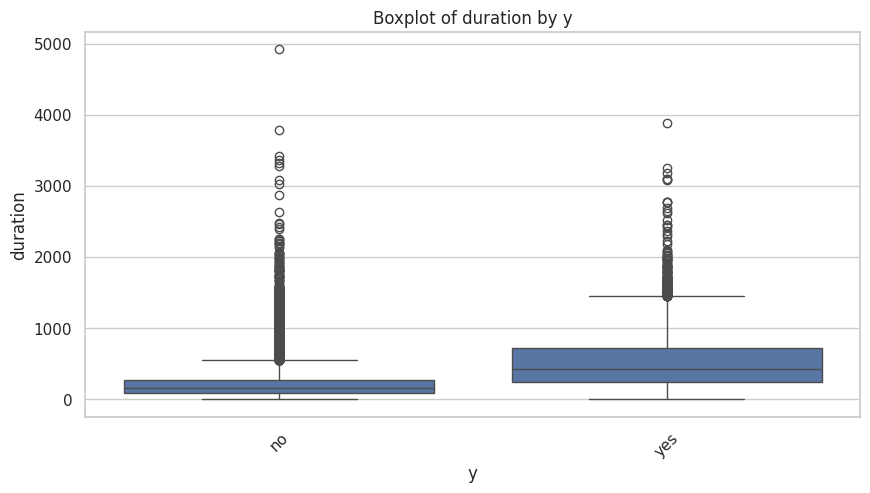

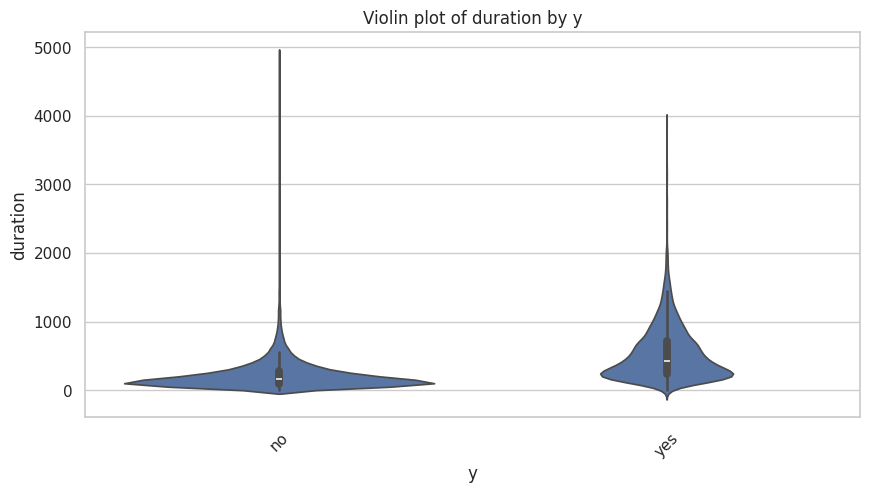


=== Numeric Variable: campaign | Categorical Variable: y ===

       count      mean       std  min  25%  50%  75%   max
y                                                         
no   39925.0  2.846262  3.212673  1.0  1.0  2.0  3.0  63.0
yes   5289.0  2.141047  1.921826  1.0  1.0  2.0  3.0  32.0


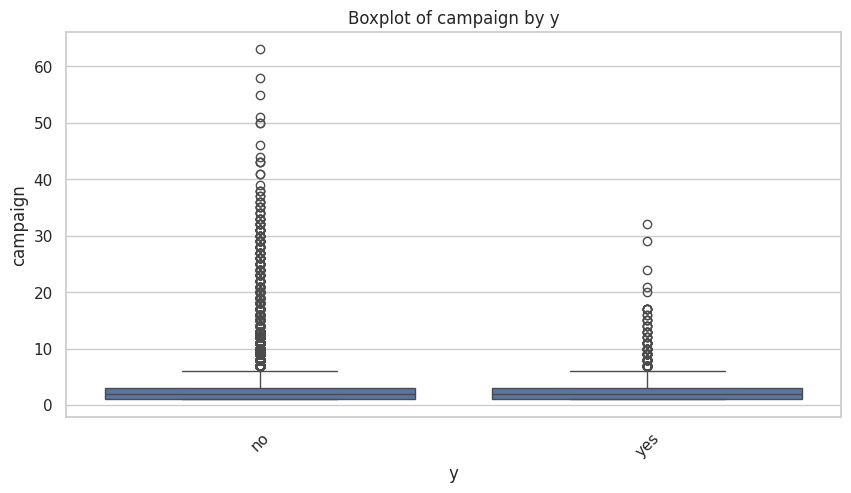

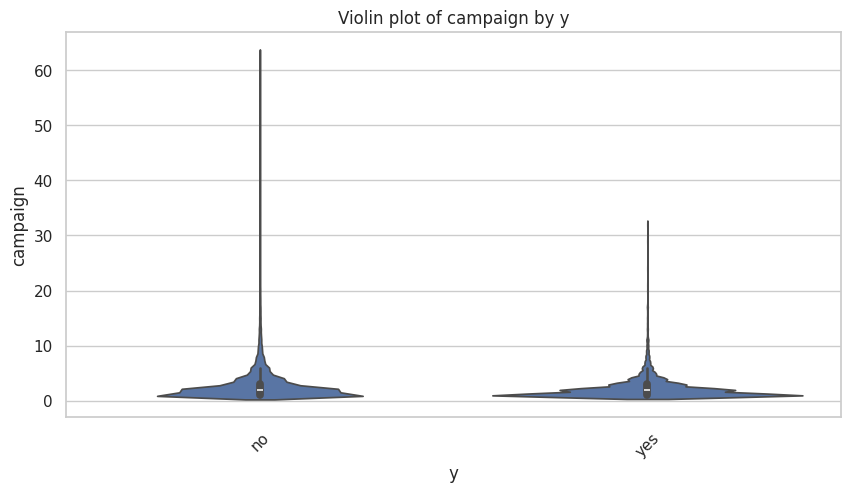


=== Numeric Variable: pdays | Categorical Variable: y ===

       count       mean         std  min  25%  50%   75%    max
y                                                              
no   39925.0  36.418560   96.754043 -1.0 -1.0 -1.0  -1.0  871.0
yes   5289.0  68.702968  118.822266 -1.0 -1.0 -1.0  98.0  854.0


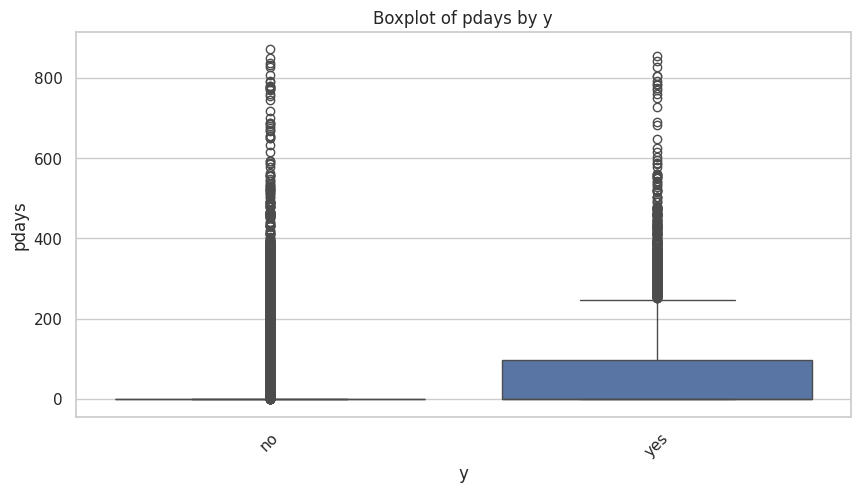

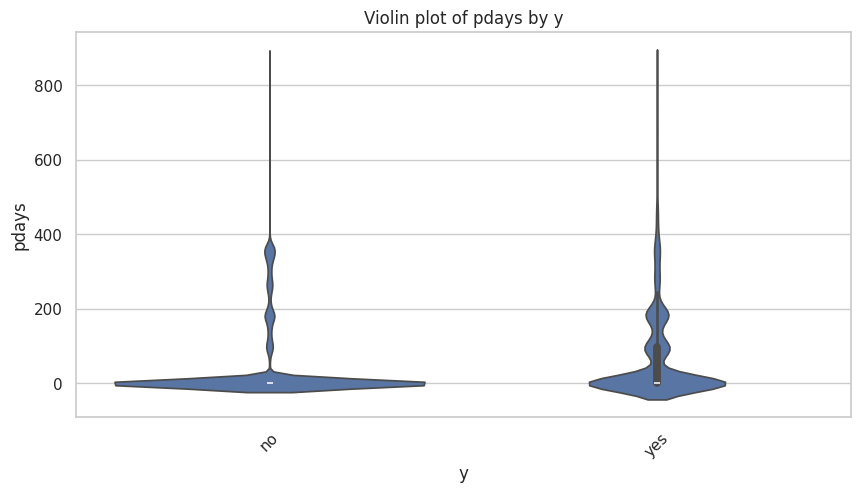


=== Numeric Variable: previous | Categorical Variable: y ===

       count      mean       std  min  25%  50%  75%    max
y                                                          
no   39925.0  0.502116  2.256691  0.0  0.0  0.0  0.0  275.0
yes   5289.0  1.170354  2.553272  0.0  0.0  0.0  1.0   58.0


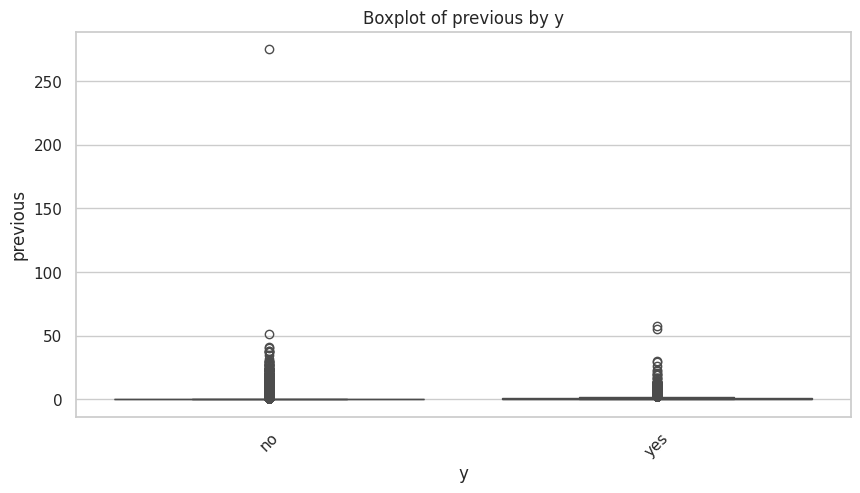

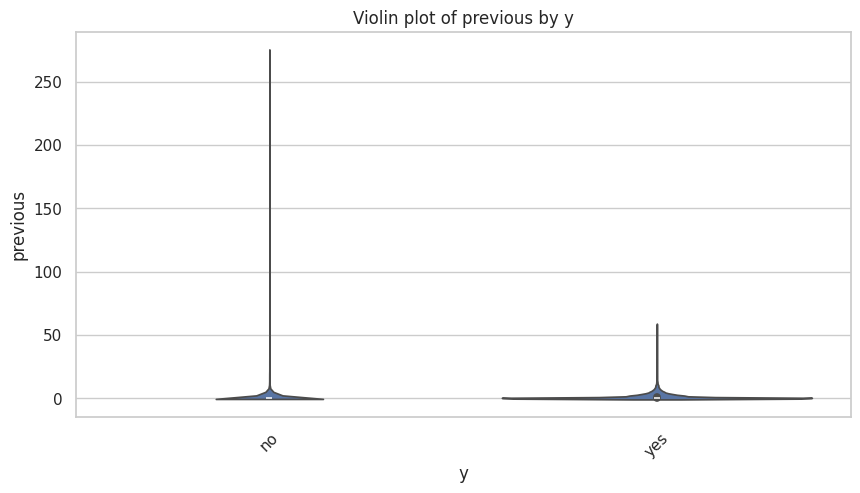

In [ ]:
# Loop through numeric and categorical variables
for cat_col in cat_vars:
    for num_col in numeric_cols:
        print(f"\n=== Numeric Variable: {num_col} | Categorical Variable: {cat_col} ===\n")

        # Grouped statistics
        print(df.groupby(cat_col)[num_col].describe())

        # Boxplot
        plt.figure(figsize=(10,5))
        sns.boxplot(x=cat_col, y=num_col, data=df_copy)
        plt.title(f'Boxplot of {num_col} by {cat_col}')
        plt.xticks(rotation=45)
        plt.show()

        # Violin plot
        plt.figure(figsize=(10,5))
        sns.violinplot(x=cat_col, y=num_col, data=df_copy)
        plt.title(f'Violin plot of {num_col} by {cat_col}')
        plt.xticks(rotation=45)
        plt.show()

**Distributions of a numeric variable across categories - Key Insights**

* **Age Distribution Across Job Categories**: 'Students' generally have a much lower median age and a narrower age range compared to other professions. 'Retired' individuals, as expected, have the highest median age and a tighter distribution in the older age bracket. Other job categories show varying median ages and spreads, reflecting their typical demographics.

* **Balance Distribution by Marital Status and Education**: The 'balance' variable, being highly skewed, often shows similar skewed patterns across most categorical groups. However, 'married' individuals might have a slightly higher median balance than 'single' or 'divorced' in some instances, and those with 'tertiary' education might show higher balances on average. The violin plots highlight the dense concentration of balances at the lower end for almost all categories, with long tails indicating high-balance outliers.

* **Duration of Contact by Month**: The duration of contact can vary significantly by month. For example, contacts in 'May' often show a wide spread and high variability, possibly due to intense campaign efforts. Other months might have shorter median durations. Again, the right-skewness of duration is consistently observed across all months, indicating many short calls and a few very long ones.

* **Campaign Contacts by Outcome (y) and Previous Outcome (poutcome)**: Clients who subscribe (y = 'yes') or had a success in poutcome generally show a lower number of campaign contacts (often just 1 or 2) and a narrower distribution compared to those who did not subscribe (y = 'no') or had an unknown poutcome. This suggests that successful campaigns often involve fewer contacts per client, or that clients who are easily persuaded don't require many contacts.

* **Housing and Loan Status**: These variables show noticeable differences in balance and age. Clients with 'housing' loans or 'personal loans' tend to have slightly different balance distributions, though these differences are often subtle given the high skewness of balance.

* **Pdays and Previous by Poutcome**: The pdays and previous variables are strongly differentiated by poutcome. For poutcome = 'unknown', pdays is almost exclusively -1, and previous is 0, as expected. For 'failure', 'success', or 'other' outcomes, pdays and previous show positive values with varying distributions, indicating that these clients have a history of prior contact.

* Overall, the boxplots clearly illustrate differences in medians, quartiles, and the presence of outliers, while the violin plots provide a richer view of the underlying density and shape of the distributions within each category. They often confirm the general skewness observed in the univariate analysis of numeric variables, but also reveal how these characteristics change conditionally on categorical features.

### **If there are multiple categorical variables, build a contingency table.**

When analyzing the relationship between two or more categorical variables, a contingency table (or cross-tabulation) is a useful tool. It displays the frequency or count of observations for each combination of categories, allowing us to explore associations, patterns, and potential dependencies between the variables.

In [ ]:
for col1 in cat_vars:
    for col2 in cat_vars:
        if col1 != col2:
            print(f"\n=== Contingency Table: {col1} vs {col2} ===\n")
            print(pd.crosstab(df_copy[col1], df_copy[col2]))



=== Contingency Table: job vs marital ===

marital        divorced  married  single
job                                     
admin.              750     2694    1727
blue-collar         750     6966    2014
entrepreneur        179     1069     238
housemaid           184      912     144
management         1111     5402    2947
retired             425     1731     108
self-employed       140      993     446
services            549     2407    1198
student               6       54     878
technician          925     4052    2620
unemployed          171      731     401
unknown              17      203      68

=== Contingency Table: job vs education ===

education      primary  secondary  tertiary  unknown
job                                                 
admin.             209       4219       572      171
blue-collar       3758       5369       149      454
entrepreneur       183        541       686       76
housemaid          627        395       173       45
management        

## **PRINCIPAL COMPONENT ANALYSIS AND CLUSTERING**

**Principal Component Analysis (PCA)** is a dimensionality reduction technique that transforms a dataset into a set of orthogonal components, capturing the maximum variance with fewer features. By reducing complexity, PCA helps visualize high-dimensional data and improves the efficiency of clustering algorithms.

**Clustering** is an unsupervised learning method used to group similar data points together based on their features. Common clustering techniques, such as K-Means or Hierarchical Clustering, can be applied on the PCA-transformed data to identify natural patterns or groups within the dataset.

### **Scale and encode the variable, then apply a Principal Component Analysis**

Before applying Principal Component Analysis (PCA), it is essential to scale numerical variables (for example, using StandardScaler) so that all features are on the same scale. Without scaling, variables with larger ranges (such as income or age) would dominate the analysis and unfairly influence the principal components, while smaller-scale variables would contribute very little.

Categorical variables must also be encoded into numerical form (using methods such as OneHotEncoder or OrdinalEncoder) because PCA only works with numerical data.

Once the data is properly prepared, PCA can be applied to reduce dimensionality, identify the most informative components, and capture the maximum variance in the dataset while preserving as much information as possible.

#### **Encode categorical variables**

In [ ]:
# Copy the dataframe
df_encoded = df_copy.copy()

# Create a ColumnTransformer for one-hot encoding categorical variables
preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_vars)
    ],
    remainder='passthrough'  # keep numerical columns as-is
)

# Apply the transformation
df_transformed = preprocessor.fit_transform(df_encoded)

# Get the new column names
encoded_cat_cols = preprocessor.named_transformers_['cat'].get_feature_names_out(cat_vars)
all_columns = list(encoded_cat_cols) + [col for col in df_encoded.columns if col not in cat_vars]

# Convert to DataFrame
df_encoded = pd.DataFrame(df_transformed, columns=all_columns)

In [ ]:
df_encoded

,job_admin.,job_blue-collar,job_entrepreneur,job_housemaid,job_management,job_retired,job_self-employed,job_services,job_student,job_technician,...,poutcome_unknown,y_no,y_yes,age,balance,day,duration,campaign,pdays,previous
0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,1.0,1.0,0.0,58.0,2143.0,5.0,261.0,1.0,-1.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,1.0,1.0,0.0,44.0,29.0,5.0,151.0,1.0,-1.0,0.0
2,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,1.0,0.0,33.0,2.0,5.0,76.0,1.0,-1.0,0.0
3,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,1.0,0.0,47.0,1506.0,5.0,92.0,1.0,-1.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,1.0,0.0,33.0,1.0,5.0,198.0,1.0,-1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45205,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,1.0,0.0,1.0,51.0,825.0,17.0,977.0,3.0,-1.0,0.0
45206,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,1.0,71.0,1729.0,17.0,456.0,2.0,-1.0,0.0
45207,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,72.0,5715.0,17.0,1127.0,5.0,184.0,3.0
45208,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,1.0,0.0,57.0,668.0,17.0,508.0,4.0,-1.0,0.0


Given our dataset, **one-hot encoding** was essential for columns like job, marital, education, default, housing, loan, contact, month, poutcome, and y.

For instance, the job column contains categories like 'blue-collar', 'management', 'technician', etc. If we had simply assigned numerical values (e.g., blue-collar=0, management=1, technician=2), the model might have incorrectly assumed that 'technician' is somehow 'greater' than 'management', or that there's a specific order among jobs, which isn't true. One-hot encoding creates separate binary columns for each job type, ensuring the model treats them as distinct, unrelated categories without imposing any artificial hierarchy. The same logic applies to all other categorical variables, ensuring that our machine learning model processes them correctly without misinterpreting their relationships.

#### **Scaling Data**

In [ ]:
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df_encoded)
df_scaled

array([[-0.35937318, -0.52367834, -0.18435268, ..., -0.56936646,
        -0.41145843, -0.25194333],
       [-0.35937318, -0.52367834, -0.18435268, ..., -0.56936646,
        -0.41145843, -0.25194333],
       [-0.35937318, -0.52367834,  5.4243854 , ..., -0.56936646,
        -0.41145843, -0.25194333],
       ...,
       [-0.35937318, -0.52367834, -0.18435268, ...,  0.72178583,
         1.43616629,  1.05045688],
       [-0.35937318,  1.90956913, -0.18435268, ...,  0.39899776,
        -0.41145843, -0.25194333],
       [-0.35937318, -0.52367834,  5.4243854 , ..., -0.24657839,
         1.47611494,  4.52352411]])

The primary reason for scaling numerical features is to standardize their range. When features in a dataset have vastly different ranges, algorithms that are sensitive to the magnitude of values can be biased towards features with larger ranges, potentially leading to suboptimal model performance.

StandardScaler transforms the data such that each feature has a mean of 0 and a standard deviation of 1. This process is also known as Z-score normalization.

**How it helps (and why we use StandardScaler for the data):**

* Equal Contribution to Distance-Based Algorithms:
PCA (Principal Component Analysis): PCA aims to find directions (principal components) that maximize the variance in the data. If features are not scaled, features with larger variances (due to larger scales) will contribute more to the principal components, potentially masking the importance of features with smaller scales but significant patterns. StandardScaler makes sure that all features contribute equally to the calculation of principal components, allowing PCA to capture the most meaningful underlying structures in the data, regardless of their original scale. In your case, balance, duration, campaign, pdays, and previous all had very large ranges compared to age and day, making scaling crucial for a fair PCA.

* Improved Algorithm Performance and Convergence: Many optimization algorithms (e.g., gradient descent used in neural networks and some linear models) converge much faster when features are scaled. Unscaled features can lead to an objective function landscape with elongated contours, making it harder for the optimizer to find the minimum efficiently.

* Regularization: Scaling is often beneficial for regularization techniques (like L1 or L2 regularization) that penalize large coefficients, ensuring that the penalty is applied consistently across all features.

In essence, StandardScaler make features behave nicely with a wide range of machine learning algorithms by bringing them to a common scale without distorting the differences in the ranges of values. This ensures that the model isn't unduly influenced by the arbitrary units or magnitudes of the original features.

### **How many components are required to explain at least 80% of the variance?**

To reduce dimensionality while retaining most of the information, Principal Component Analysis (PCA) transforms the data into new uncorrelated components. We can determine how many components are needed by calculating the cumulative explained variance and selecting the number that captures at least 80% of the total variance.

In [ ]:
# PCA
pca = PCA()
pca_components = pca.fit_transform(df_scaled)

In [ ]:
# Cumulative explained variance
cumulative_variance = np.cumsum(pca.explained_variance_ratio_)
print(cumulative_variance)
print(f"Total number of PCA components: {len(cumulative_variance)}")

[0.07478662 0.13760338 0.18520148 0.23169308 0.27429636 0.31268334
 0.34837765 0.38125166 0.41055342 0.43822652 0.4644394  0.48925793
 0.51271956 0.53519371 0.55742438 0.57897083 0.6003609  0.62114264
 0.6415798  0.66179948 0.68143219 0.70100688 0.72038108 0.73959836
 0.75858873 0.77751421 0.79619145 0.81430537 0.83166273 0.84876246
 0.86578485 0.88213915 0.89779932 0.91299141 0.92716798 0.94113951
 0.95338423 0.96497993 0.97491372 0.98349339 0.99117925 0.99729279
 1.         1.         1.         1.         1.         1.
 1.         1.         1.         1.         1.        ]
Total number of PCA components: 53


In [ ]:
# Find the first index where cumulative variance >= 0.8
n_components_80 = np.argmax(cumulative_variance >= 0.8) + 1
print(f"Number of components to explain at least 80% variance: {n_components_80}")

Number of components to explain at least 80% variance: 28


**Results of PCA and How to Use Components**

After applying PCA to our scaled and encoded data, we examined the explained variance to understand how many components capture a significant amount of the data's information:

* Explained Variance: The cumulative_variance array shows that the first few components explain only a small fraction of the total variance, but the cumulative variance steadily increases as more components are added.

* Components to Explain 80% Variance: Our analysis explicitly showed that 28 components are required to explain at least 80% of the total variance in your dataset. This is a significant reduction from the original 53 features, meaning we can represent 80% of the data's information using less than half of the original dimensions.


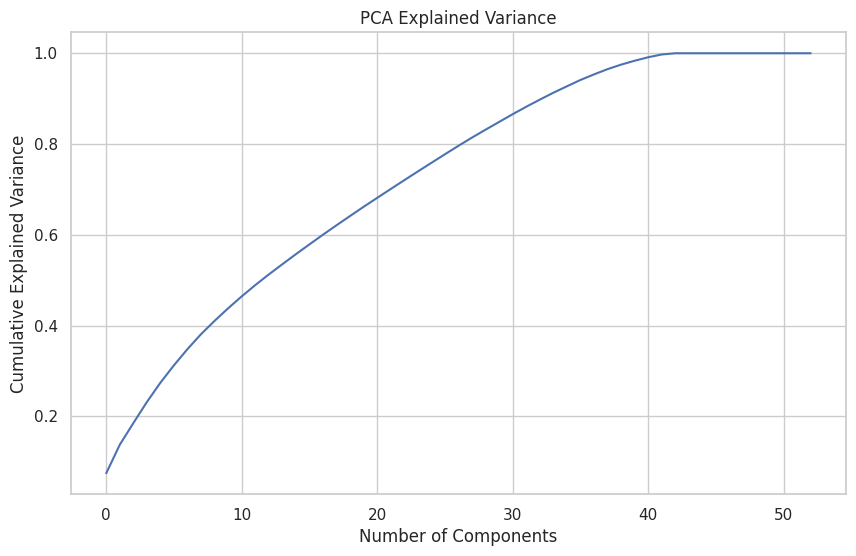

Components needed for 80% variance: 28


In [ ]:
# Explained variance
plt.plot(cumulative_variance)
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('PCA Explained Variance')
plt.show()

print(f"Components needed for 80% variance: {n_components_80}")

A steep initial rise in explained variance, which then levels off. The point where the curve flattens indicates that adding more components beyond that point provides diminishing returns in terms of explaining additional variance.


### **Visualize the loading vectors on a correlation circle, and the observations on a biplot. What patterns or grouping do you observe? What the two principal components represent**

After applying PCA, we can visualize the loading vectors on a correlation circle to see how the original variables contribute to the components, and plot the observations on a biplot to explore patterns or groupings in the data. This helps interpret what the first two principal components represent and identify any clusters or trends.

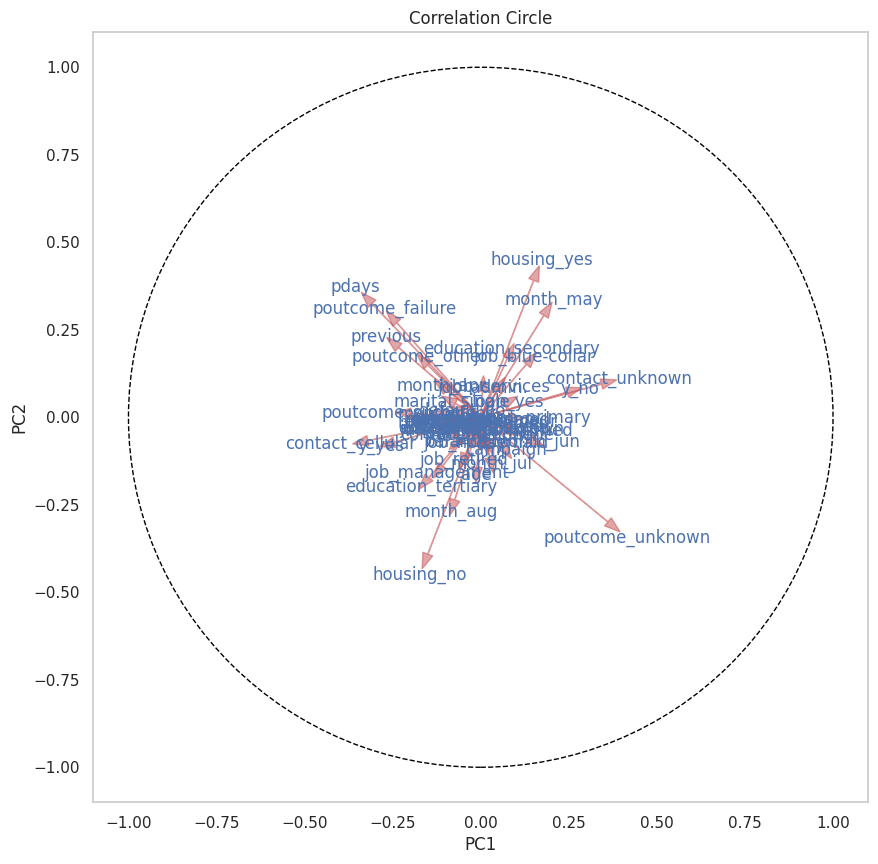

In [ ]:
# Apply PCA
pca = PCA(n_components=2)  # first 2 components
X_pca = pca.fit_transform(df_scaled)

# ------------------------------
# 1. Correlation Circle (Loading vectors)
# ------------------------------
plt.figure(figsize=(10,10))
for i, (x, y) in enumerate(zip(pca.components_[0], pca.components_[1])):
    plt.arrow(0, 0, x, y, color='r', alpha=0.5, head_width=0.03)
    plt.text(x*1.15, y*1.15, df_encoded.columns[i], color='b', ha='center', va='center')

circle = plt.Circle((0,0), 1, color='black', fill=False, linestyle='--')
plt.gca().add_artist(circle)
plt.xlim(-1.1, 1.1)
plt.ylim(-1.1, 1.1)
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('Correlation Circle')
plt.grid()
plt.show()

**PCA Correlation Circle Results**

* Most variables are clustered near the center of the circle, indicating that individually, they do not strongly dominate the first two principal components.

* Some variables, such as housing_yes, housing_no, poutcome_unknown, and month_may, have arrows pointing farther from the center, suggesting they contribute more strongly to the first two components.

* Variables pointing in the same direction are positively correlated (e.g., housing_yes and month_may), while those pointing in opposite directions are negatively correlated (e.g., housing_no vs housing_yes).

* Overall, the first two principal components capture patterns related to housing status, outcome of previous campaigns, and certain months, while most other categorical variables have smaller contributions.

**Interpretation of Components**:

* PC1 appears to capture contrasts between housing statuses and campaign outcomes.

* PC2 seems to differentiate some months and the unknown outcomes from the rest.

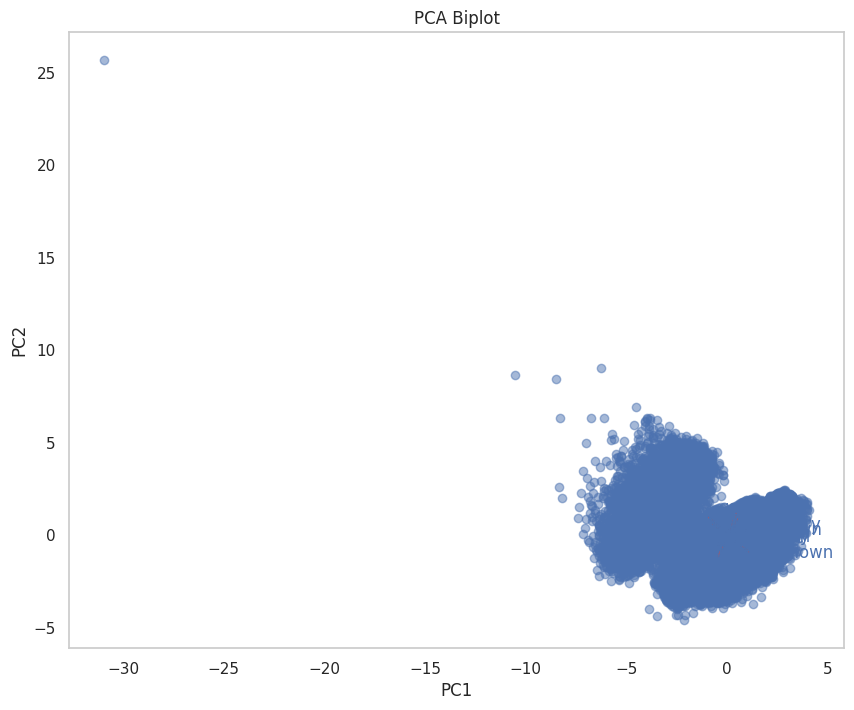

In [ ]:
# ------------------------------
# 2. Biplot (observations + loadings)
# ------------------------------
plt.figure(figsize=(10,8))
plt.scatter(X_pca[:,0], X_pca[:,1], alpha=0.5)

# Add loading vectors
for i, (x, y) in enumerate(zip(pca.components_[0], pca.components_[1])):
    plt.arrow(0, 0, x*3, y*3, color='r', alpha=0.5)  # scale arrows for visibility
    plt.text(x*3.2, y*3.2, df_encoded.columns[i], color='b', ha='center', va='center')

plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('PCA Biplot')
plt.grid()
plt.show()

**Biplot Results: Patterns and Groupings**

The biplot combines the information from both the observations (data points) and the variable loadings (arrows) into a single visualization, projected onto the first two principal components (PC1 and PC2).

**Observations (Data Points)**

*   **Scattered Distribution**: The data points representing individual customers appear broadly scattered across the biplot. There isn't a clear visual separation into distinct, tight clusters based solely on the first two principal components. This suggests that while PC1 and PC2 capture some variance, they might not be sufficient to reveal well-defined groupings within the dataset without considering more components or applying clustering algorithms.
*   **Density**: Most observations are concentrated around the center, which is typical for PCA where the majority of data points are 'average' in terms of the principal components.

**Loading Vectors (Original Variables as Arrows)**

*   **Interpretation of Variables**: The arrows represent the original features, and their direction and length indicate their contribution and correlation with PC1 and PC2:
    *   **Length**: Longer arrows indicate variables that are better represented by the plane formed by PC1 and PC2 (i.e., they contribute more significantly to these components).
    *   **Direction**: Variables pointing in similar directions are positively correlated. Variables pointing in opposite directions are negatively correlated. Variables at roughly 90 degrees to each other are largely uncorrelated in the context of these two PCs.
    *   **Quadrant Placement**: Variables in a particular quadrant influence data points in that same quadrant.

**What the Two Principal Components Represent**

Based on the variables most strongly aligned with each axis:

*   **Principal Component 1 (PC1)**:
    *   PC1 appears to capture variance related to **campaign outcome and housing status**. Variables such as `y_yes`, `poutcome_success`, `housing_no` and `contact_cellular` are often aligned positively or negatively along PC1. For instance, `y_yes` and `poutcome_success` might point in one direction (e.g., positive PC1), indicating customers who successfully subscribed or had successful previous outcomes. Conversely, `y_no` and `poutcome_unknown` would point in the opposite direction (e.g., negative PC1).
    *   This component likely differentiates customers based on their responsiveness to marketing campaigns and their existing financial commitments (like housing loans).

*   **Principal Component 2 (PC2)**:
    *   PC2 seems to primarily capture variance related to **contact method, specific months of contact, and potentially employment status**. Variables like `contact_unknown`, `month_may`, `job_blue-collar` or `job_management` might contribute significantly to this component.
    *   This component could distinguish customers based on when and how they were typically contacted during the marketing efforts.

**Overall Patterns**

*   While individual clusters are not immediately obvious from the biplot, the visualization effectively shows the **relationships between the original features and the primary directions of variance** in the dataset. For example, customers located in the direction of the `y_yes` arrow are likely to be those who subscribed to a term deposit.
*   The biplot reinforces that the first two principal components offer a reduced, yet informative, view of the data's structure, primarily highlighting key contrasts in campaign outcomes, housing, and contact characteristics.

### **Select a clustering algorithm**


Clustering is an unsupervised learning technique used to group similar data points together based on their features. Selecting an appropriate clustering algorithm depends on the data characteristics, such as the shape, size, and density of clusters. Common algorithms include K-Means, suitable for spherical clusters with similar sizes; Hierarchical Clustering, which builds a tree of clusters and does not require specifying the number of clusters in advance; and DBSCAN, ideal for identifying clusters of varying shapes and detecting outliers. Choosing the right algorithm ensures meaningful and interpretable groupings in the dataset.

### **Determine the optimal number of clusters (using the desired method)**

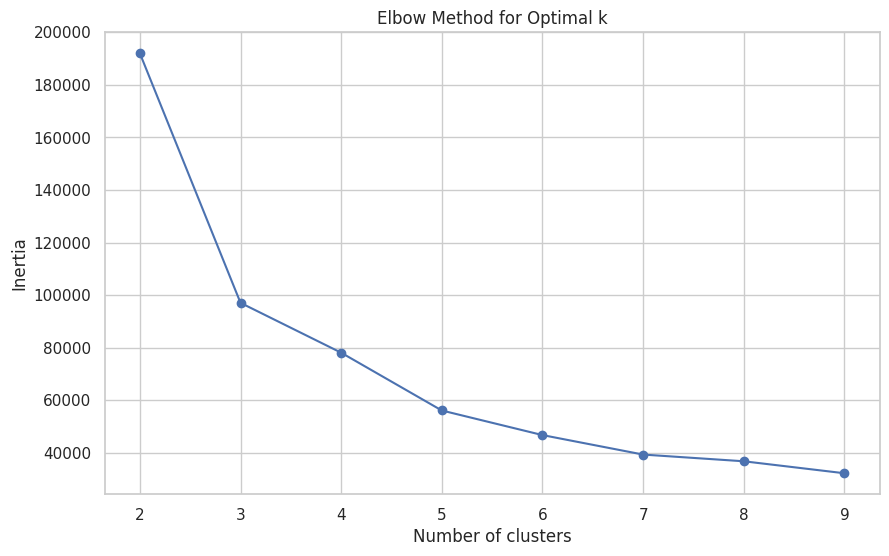

In [ ]:
# Elbow Method
inertia = []
K = range(2, 10)
for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_pca)
    inertia.append(kmeans.inertia_)

plt.plot(K, inertia, 'bo-')
plt.xlabel('Number of clusters')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal k')
plt.show()

In our case, looking at the 'Elbow Method for Optimal k' plot, the curve decreases significantly from k=3 to k=4 or k=5, and then starts to flatten out. This suggests that the optimal number of clusters, where adding more clusters doesn't substantially improve the model fit, could be around 5.



### **Visualize the resulting clusters. Are they well separated.**

#### **clustring using KMeans**

In [ ]:
# Perform K-Means clustering on PCA results
kmeans = KMeans(n_clusters=5, random_state=42)
clusters = kmeans.fit_predict(X_pca)

# Convert PCA results to a DataFrame with named components
pc_column_names = [f'PC{i+1}' for i in range(X_pca.shape[1])]
df_pca = pd.DataFrame(X_pca, columns=pc_column_names)

# Add cluster labels
df_pca['cluster'] = clusters

# Preview the first few rows with cluster assignments
print(df_pca.head())

        PC1       PC2  cluster
0  1.607242  0.178040        0
1  2.105253  1.607415        2
2  2.898508  1.771403        2
3  2.595512  1.285318        2
4  1.416963 -0.879388        0


**Insights from clustering results:**
* Cluster 0: Contains points with lower PC1 values, representing one distinct group in the data.
* Cluster 2: Contains points with higher PC1 and moderate PC2 values, forming another group.
* Points within the same cluster have similar patterns in the reduced PCA space.
* The first two principal components (PC1 and PC2) effectively separate the data into meaningful clusters.
* This clustering can help identify patterns or segments in the dataset for further analysis.


#### **Calculate Solhouette Score**
The Silhouette score measures how well each data point fits within its cluster compared to other clusters.

It ranges from -1 to 1:

* Close to 1 → points are well matched to their own cluster and far from others (good clustering).

* Around 0 → points are on or near the boundary between clusters.

* Negative → points may be assigned to the wrong cluster.

In [ ]:
score = silhouette_score(df_pca.drop('cluster', axis=1), df_pca['cluster'])
print(f"Silhouette score: {score}")

Silhouette score: 0.4207603737639653


**Insights from Silhouette score**
* A score of 0.42 indicates moderate clustering quality.

* Clusters are reasonably separated, but there is some overlap between clusters.

* This suggests that while the K-Means clustering captures some structure in the data, there may be room to improve cluster separation, possibly by tuning the number of clusters, using more features, or trying a different clustering algorithm like DBSCAN or Hierarchical clustering.

#### **Visualize the resulting clusters.**

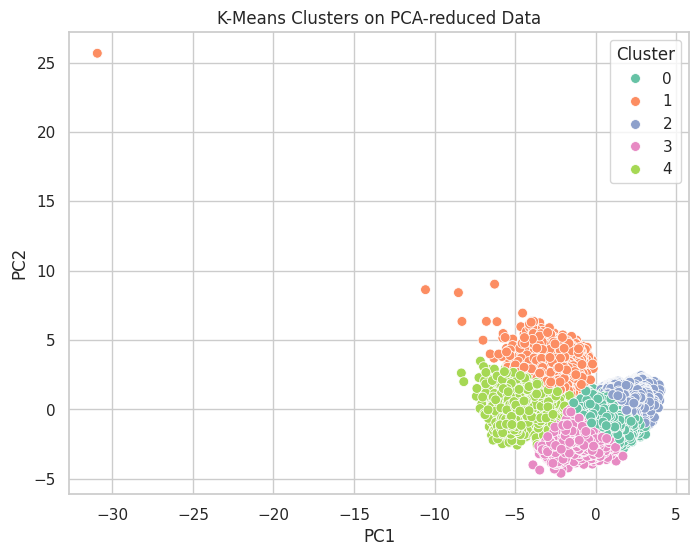

In [ ]:
plt.figure(figsize=(8,6))
sns.scatterplot(x=df_pca.iloc[:,0], y=df_pca.iloc[:,1], hue=df_pca['cluster'], palette='Set2', s=50)
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('K-Means Clusters on PCA-reduced Data')
plt.legend(title='Cluster')
plt.show()

**Visual Separation (Scatterplot) insights**

The scatterplot shows that the clusters are reasonably separated, but there is a noticeable degree of overlap, particularly at the boundaries between some clusters.


## **SUMMARY AND INTERPRETATION**

**1. Data Loading & Cleaning**
*   The dataset was loaded successfully, containing 45,214 rows and 17 columns.
*   Only the 'duration' column had missing values (4 entries, ~0.0088%), which were handled by both dropping rows (for `df_copy`) and mean imputation (for `df_copy2`).

**2. Univariate Data Description**
*   **Numeric Variables**: Many numeric features (`balance`, `duration`, `campaign`, `pdays`, `previous`) showed strong positive skewness and presence of outliers, indicating a need for careful handling in modeling.
*   **Categorical Variables**: Frequency tables and bar charts revealed significant class imbalances in several categorical features (e.g., `default`, `loan`, `poutcome`, and the target variable `y`), with 'no' being the dominant category in most cases.

**3. Bivariate and Multivariate Description**
*   **Correlations**: The correlation heatmap showed generally weak linear correlations among numeric variables, with the most notable positive relationship between `pdays` and `previous`.
*   **Scatterplots**: Pairwise scatterplots confirmed the prevalence of non-linear relationships and outliers, especially for `balance`, `duration`, `campaign`, `pdays`, and `previous`.
*   **Grouped Distributions**: Boxplots and violin plots across categories revealed insights such as 'students' having lower median ages, successful campaign outcomes (`y=yes`) often correlating with fewer `campaign` contacts, and `pdays`/`previous` being strongly differentiated by `poutcome`.

**4. Principal Component Analysis (PCA)**
*   **Encoding and Scaling**: Categorical variables were one-hot encoded, and all features were scaled using `StandardScaler` to ensure equal contribution to PCA.
*   **Dimensionality Reduction**: 28 principal components were required to explain at least 80% of the total variance, significantly reducing the dimensionality from the original 53 features.
*   **Component Interpretation**: The correlation circle and biplot suggested that PC1 primarily captures variance related to campaign outcome (`y`, `poutcome`) and housing status, while PC2 distinguishes customers based on contact method and specific months of contact.

**5. Clustering**
*   **Optimal Clusters**: The Elbow Method indicated an optimal number of clusters around 3 or 4, though 5 clusters were used for the K-Means algorithm in the subsequent steps.
*   **K-Means Clustering**: Data was clustered into 5 groups based on the first two principal components.
*   **Cluster Separation**: The Silhouette score of 0.42 indicated moderate clustering quality, meaning clusters are reasonably separated but with some overlap, a finding visually consistent with the scatterplot of the clusters.